# Plan

**Baseline regression workflow**

1. Inputs: binary genotype vector from surrogate_preprocessed_seed_default_generation_long.csv and surrogate_preprocessed_ko441_generation_long.csv.
2. Target: one-generation growth rate in /h, derived from the raw parquet timeseries.
3. Preprocess labels: estimate growth only from the earliest stable interval; if a lineage shows a rise before death, truncate at the first local peak and keep only the pre-peak slope. Treat later generations after death as censored/missing, not as training targets.
4. Aggregate replicates with median growth per genotype-generation.
5. Baseline model: start with polynomial regression; then compare with XGBoost or LightGBM.
6. Evaluation: split by genotype, report MAE/RMSE in /h, and use recursive prediction for generation-by-generation simulation.

**Linear, Ridge, and ElasticNet Model**
- All Model Assumptions

All models assume that growth rate can be approximated as a linear combination of TU availability features:

$$
\hat{y} = \beta_0 + \sum_{i=1}^{p} \beta_i x_i
$$

where ($x_i \in {0,1}$) indicates whether transcription unit (i) is available.

- Linear Regression (Ordinary Least Squares)

OLS estimates coefficients by minimizing the residual sum of squares:

$$
\min_{\beta} |y - X\beta|_2^2
$$

This assumes that TU effects are additive and approximately linear.

- Ridge Regression

Ridge adds an L2 penalty to shrink coefficient magnitudes:

$$
\min_{\beta} |y - X\beta|_2^2 + \lambda |\beta|_2^2
$$

This assumes that most TUs contribute to growth and improves stability when features are highly correlated.

- Elastic Net Regression

Elastic Net combines L1 and L2 regularization:

$$
\min_{\beta} |y - X\beta|_2^2

\lambda \left(
\alpha |\beta|_1
\frac{1-\alpha}{2}|\beta|_2^2
\right)
$$

This assumes that only a subset of TUs may have strong effects while retaining robustness to correlated features.

# Workflow flowchart

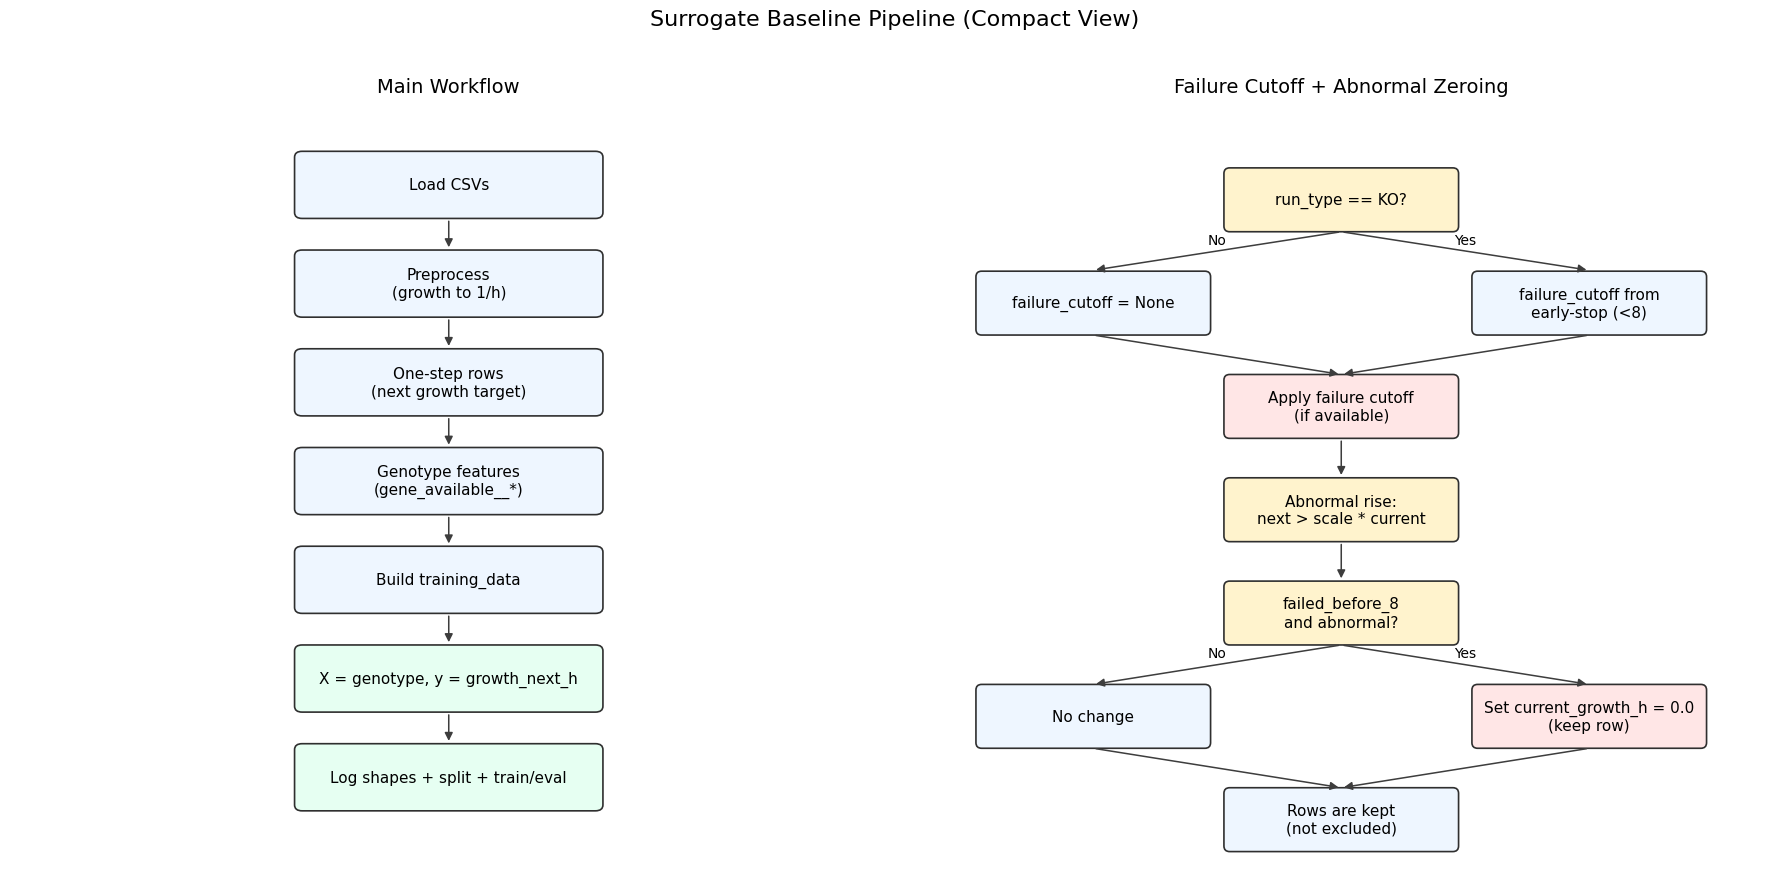

Saved compact flowchart image: /user/home/il22158/work/vEcoli/surrogate/train_data/workflow_flowchart_compact.png


In [ ]:
"""Plot flowchart of surrogate baseline pipeline, including main workflow and abnormal handling.
Criteria: 1. Rise at next generation; 2. Failure cutoff (if early stopping was triggered). 
Operation: Rows are kept but current growth is set to zero if both conditions are met.
"""
TRAIN_DIR = "/user/home/il22158/work/vEcoli/surrogate/train_data"

# Compact, clearer workflow figure (updated abnormal handling)
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def box(ax, x, y, t, w=2.4, h=0.62, c="#eef6ff", fs=11):
    p = FancyBboxPatch(
        (x - w / 2, y - h / 2),
import pandas as pd

# ----------------------------
# Paths
# ----------------------------
summary_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary.csv"
operon_map_file = "/user/home/il22158/work/vEcoli/reading/imported/inferred_operons_from_TUs.csv"

output_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv"

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(summary_file, engine="python")
operon_df = pd.read_csv(operon_map_file)

# ----------------------------
# TU -> operon mapping from the cited operon table
# ----------------------------
tu_to_operon = {}
for _, row in operon_df.iterrows():
    operon_id = pd.to_numeric(row["operon_ids"], errors="coerce")
    if pd.isna(operon_id):
        continue
    operon_id = int(operon_id)
    tu_ids = [tu.strip() for tu in str(row["tu_ids"]).split(";") if tu.strip()]
    for tu_id in tu_ids:
        tu_to_operon[tu_id] = operon_id

# ----------------------------
# Only these projects need conversion
# ----------------------------
convert_projects = {
    "gene_knockout_p_list",
    "gene_knockout_leftover",
    "gene_knockout_3_round_test"
}

# ----------------------------
# Helper
# ----------------------------
def convert_if_needed(row):
    val = row["gene_knockout"]
    project = row["project_name"]

    if pd.isna(val):
        return pd.NA

    val = str(val).strip()

    # If the source already contains a TU label, resolve it directly to an operon id.
    if val.startswith("TU"):
        return tu_to_operon.get(val, pd.NA)

    # For the selected projects, map gene identifiers through the TU bridge to operons.
    if project in convert_projects:
        return tu_to_operon.get(val, pd.NA)

    return pd.NA

# ----------------------------
# Apply conversion
# ----------------------------
df["operon_id"] = df.apply(convert_if_needed, axis=1).astype("Int64")

# ----------------------------
# Diagnostics
# ----------------------------
missing = df[df["operon_id"].isna()]["gene_knockout"].unique()

print("Unmapped values:", len(missing))
print(missing[:20])

# ----------------------------
# Save
# ----------------------------
df.to_csv(output_file, index=False)

print("Saved:", output_file)
source
"""
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

TRAIN_DIR = "/user/home/il22158/work/vEcoli/surrogate/train_data"


# ---------------- box ----------------
def box(ax, x, y, t, w=2.9, h=0.85, c="#eef6ff", fs=11):
    p = FancyBboxPatch(
        (x - w / 2, y - h / 2),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.06",
        facecolor=c,
        edgecolor="#2f2f2f",
        linewidth=1.2,
    )
    ax.add_patch(p)
    ax.text(x, y, t, ha="center", va="center", fontsize=fs, wrap=True)
    return w, h


# ---------------- improved geometry-aware arrow ----------------
def arrow(ax, a, b, aw=2.9, ah=0.85, bw=2.9, bh=0.85, label=None, fs=10):

    def edge_point(src, dst, w, h):
        dx = dst[0] - src[0]
        dy = dst[1] - src[1]

    # Horizontal connection
        x = src[0]
        y = src[1] + (h / 2) * (1 if dy > 0 else -1)

        return (x, y)

    start = edge_point(a, b, aw, ah)
    end = edge_point(b, a, bw, bh)

    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=12,
            linewidth=1.1,
            color="#3d3d3d"
        )
    )

    if label:
        ax.text(
            (start[0] + end[0]) / 2,
            (start[1] + end[1]) / 2 + 0.15,
            label,
            ha="center",
            va="center",
            fontsize=fs,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75)
        )


# ---------------- figure ----------------
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_title("Surrogate Pipeline: 8-Generation Growth Target", fontsize=14, pad=14)

ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-3.2, 8.8)
ax.axis("off")


# ---------------- uniform vertical spacing ----------------
start = 7.5
bottom = -0.6
n_levels = 7  # number of horizontal layers

step = (start - bottom) / (n_levels - 1)
ys = [start - i * step for i in range(n_levels)]


# ---------------- nodes ----------------
w, h = box(ax, 0, ys[0], "Load simulation data")

w, h = box(ax, 0, ys[1], "Preprocess\n(growth rate → 1/h)")

w, h = box(ax, 0, ys[2], "Extract genotype features\n(TU_available__*)")

w, h = box(ax, 0, ys[3], "Reached generation 8?")

w, h = box(ax, -2.6, ys[4], "No\n(incomplete / early stop)", c="#ffe6e6")
w2, h2 = box(ax, 2.6, ys[4], "Yes\n(full trajectory)", c="#fff3cd")

w3, h3 = box(ax, -2.6, ys[5], "Target = 0", c="#ffe6e6")

w4, h4 = box(ax, 2.6, ys[5],
    "G₈,avg = (1/8) Σₜ₌₁⁸ ⟨gₜ⟩", c="#fff3cd"
)

w5, h5 = box(
    ax,
    0,
    ys[6],
    "Training dataset construction\n"
    "X = TU_available features\n"
    "Y = G₈ (or 0 if failed)",
    c="#dff6ff"
)

w7, h7 = box(ax, 0, ys[6] - step, "Train surrogate model")


# ---------------- arrows ----------------
arrow(ax, (0, ys[0]), (0, ys[1]), w, h, w, h)
arrow(ax, (0, ys[1]), (0, ys[2]), w, h, w, h)
arrow(ax, (0, ys[2]), (0, ys[3]), w, h, w, h)

arrow(ax, (0, ys[3]), (-2.6, ys[4]), w, h, w2, h2, "No")
arrow(ax, (0, ys[3]), (2.6, ys[4]), w, h, w2, h2, "Yes")

arrow(ax, (-2.6, ys[4]), (-2.6, ys[5]), w2, h2, w3, h3)
arrow(ax, (2.6, ys[4]), (2.6, ys[5]), w2, h2, w4, h4)

arrow(ax, (-2.6, ys[5]), (0, ys[6]), w3, h3, w5, h5)
arrow(ax, (2.6, ys[5]), (0, ys[6]), w4, h4, w5, h5)

arrow(ax, (0, ys[6]), (0, ys[6] - step), w5, h5, w7, h7)


# ---------------- save ----------------
fig.tight_layout()

out_path = Path(TRAIN_DIR) / "workflow_flowchart_8gen_avg_growth_TU_featured.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.4)

plt.show()

print(f"Saved: {out_path}")

# Inspect rest of operons

## TU list

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

sim_data_path = "/user/home/il22158/work/vEcoli/out/gene_knockout_test1/parca/kb/simData.cPickle"

# ----------------------------
# Load sim_data
# ----------------------------
with open(sim_data_path, "rb") as f:
    sim_data = pickle.load(f)

# ----------------------------
# Extract objects
# ----------------------------
# This is the key mapping matrix used throughout your code
M = sim_data.process.transcription.cistron_tu_mapping_matrix

print("Matrix shape (cistrons x TUs):", M.shape)
print("Type:", type(M))

# ----------------------------
# Load ID lists
# ----------------------------
cistron_ids = sim_data.process.transcription.cistron_data["id"]
rna_ids = sim_data.process.transcription.rna_data["id"]

print("\n#cistrons:", len(cistron_ids))
print("#TUs:", len(rna_ids))

# ----------------------------
# Function: gene -> TU mapping
# ----------------------------
def cistron_to_tus(cistron_id):
    idx = np.where(cistron_ids == cistron_id)[0][0]
    tu_indexes = M.getrow(idx).nonzero()[1]
    return [rna_ids[i] for i in tu_indexes]

# ----------------------------
# Pick a gene to inspect
# ----------------------------
test_gene = cistron_ids[0]   # change this to any gene ID you want
mapped_tus = cistron_to_tus(test_gene)

print(f"\nGene (cistron): {test_gene}")
print("Mapped TU(s):")
for tu in mapped_tus:
    print("  ", tu)

# ----------------------------
# Check if one gene maps to multiple TUs
# ----------------------------
multi_map_genes = []
for i, cid in enumerate(cistron_ids):
    n_tus = M.getrow(i).getnnz()
    if n_tus > 1:
        multi_map_genes.append((cid, n_tus))

print("\nGenes mapping to multiple TUs:", len(multi_map_genes))
print("Example:", multi_map_genes[:10])

Matrix shape (cistrons x TUs): (4538, 3277)
Type: <class 'scipy.sparse._csr.csr_matrix'>

#cistrons: 4538
#TUs: 3277

Gene (cistron): EG10001_RNA
Mapped TU(s):
   TU0-14120[c]

Genes mapping to multiple TUs: 694
Example: [(np.str_('EG10007_RNA'), 2), (np.str_('EG10022_RNA'), 2), (np.str_('EG10023_RNA'), 2), (np.str_('EG10024_RNA'), 2), (np.str_('EG10025_RNA'), 2), (np.str_('EG10026_RNA'), 2), (np.str_('EG10027_RNA'), 2), (np.str_('EG10036_RNA'), 2), (np.str_('EG10037_RNA'), 2), (np.str_('EG10047_RNA'), 4)]


In [ ]:
import pickle
import numpy as np
import pandas as pd
import os

sim_data_path = "/user/home/il22158/work/vEcoli/out/gene_knockout_test1/parca/kb/simData.cPickle"
out_path = "/user/home/il22158/work/vEcoli/reading/cistron_tu_mapping.csv"

# ----------------------------
# Load sim_data
# ----------------------------
with open(sim_data_path, "rb") as f:
    sim_data = pickle.load(f)

# ----------------------------
# Extract matrix + IDs
# ----------------------------
M = sim_data.process.transcription.cistron_tu_mapping_matrix
cistron_ids = np.array(sim_data.process.transcription.cistron_data["id"])
rna_ids = np.array(sim_data.process.transcription.rna_data["id"])

print("Matrix shape:", M.shape)

# ----------------------------
# Convert to edge list
# ----------------------------
rows, cols = M.nonzero()

data = {
    "cistron_id": [],
    "tu_id": []
}

for i, j in zip(rows, cols):
    data["cistron_id"].append(cistron_ids[i])
    data["tu_id"].append(rna_ids[j])

df = pd.DataFrame(data)

print(f"Total mappings (edges): {len(df)}")

# ----------------------------
# OPTIONAL: add gene symbols safely
# ----------------------------
try:
    symbols = sim_data.process.transcription.cistron_data["symbol"]
    symbol_map = {cid: sym for cid, sym in zip(cistron_ids, symbols)}
    df["symbol"] = df["cistron_id"].map(symbol_map)
except Exception as e:
    print("No symbol field found, skipping symbols:", e)

# ----------------------------
# Save CSV
# ----------------------------
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df.to_csv(out_path, index=False)

print("Saved to:", out_path)

Matrix shape: (4538, 3277)
Total mappings (edges): 5433
No symbol field found, skipping symbols: 'symbol'
Saved to: /user/home/il22158/work/vEcoli/reading/cistron_tu_mapping.csv


In [ ]:
import pickle
import numpy as np
import pandas as pd
import networkx as nx

sim_data_path = "/user/home/il22158/work/vEcoli/out/gene_knockout_test1/parca/kb/simData.cPickle"
out_path = "/user/home/il22158/work/vEcoli/reading/cistron_to_tu_grouped.csv" 

with open(sim_data_path, "rb") as f:
    sim_data = pickle.load(f)

# ----------------------------
# Mapping matrix
# ----------------------------
M = sim_data.process.transcription.cistron_tu_mapping_matrix

cistron_ids = np.array(sim_data.process.transcription.cistron_data["id"])
rna_ids = np.array(sim_data.process.transcription.rna_data["id"])

n_tus = M.shape[1]

# ----------------------------
# Step 1: TU → genes mapping
# ----------------------------
tu_to_genes = {j: set() for j in range(n_tus)}

for i in range(M.shape[0]):
    tu_idx = M.getrow(i).nonzero()[1]
    for j in tu_idx:
        tu_to_genes[j].add(i)

# ----------------------------
# Step 2: Build TU overlap graph
# (edge if share ≥1 gene)
# ----------------------------
G = nx.Graph()
G.add_nodes_from(range(n_tus))

for i in range(n_tus):
    for j in range(i + 1, n_tus):
        if tu_to_genes[i] & tu_to_genes[j]:
            G.add_edge(i, j)

# ----------------------------
# Step 3: Connected components = operons
# ----------------------------
components = list(nx.connected_components(G))

tu_to_operon = {}
for op_id, comp in enumerate(components):
    for tu in comp:
        tu_to_operon[tu] = op_id

print(f"Detected operons: {len(components)}")

# ----------------------------
# Step 4: Build rows (cistron → TU → operon)
# ----------------------------
rows = []

for i, cid in enumerate(cistron_ids):

    tu_idx = M.getrow(i).nonzero()[1]
    tus = [rna_ids[j] for j in tu_idx]

    operon_ids = {tu_to_operon[j] for j in tu_idx if j in tu_to_operon}

    rows.append({
        "cistron_id": cid,
        "num_tus": len(tus),
        "tu_ids": ";".join(tus),

        "num_operons": len(operon_ids),
        "operon_ids": ";".join(map(str, sorted(operon_ids)))
    })

df = pd.DataFrame(rows)
df.to_csv(out_path, index=False)

print("Saved mapping to:", out_path)
print("Rows:", len(df))

Detected operons: 2753
Saved mapping to: /user/home/il22158/work/vEcoli/reading/cistron_to_tu_grouped.csv
Rows: 4538


## Operon list

**Operon number difference?**
1. What the paper says (ground truth baseline)

Sun et al. (2024) report:

~2569 operons total
788 polycistronic operons
remainder mostly monocistronic
operons are curated regulatory units (EcoCyc + model curation)

So their number is:

✔ biologically curated operon count

2. What your 2753 represents

Your number comes from:

connected components of a TU–TU overlap graph

So it is:

❗ a data-derived clustering of TUs, not curated operons

That alone already means:

it is not expected to match exactly
it can differ by ±100–300 easily

In [5]:
import numpy as np

cistron_data = sim_data.process.transcription.cistron_data.struct_array

gene_to_cistron = {}

for c in cistron_data:
    g = c["gene_id"]
    gene_to_cistron.setdefault(g, set()).add(c["id"])

# check if any gene maps to multiple cistrons
multi = {g: ids for g, ids in gene_to_cistron.items() if len(ids) > 1}

print("Genes with multiple cistrons:", len(multi))
print(list(multi.items())[:10])

Genes with multiple cistrons: 0
[]


In [2]:
import pandas as pd

tu_file = "/user/home/il22158/work/vEcoli/reading/imported/total_unique_TUs.csv"

df = pd.read_csv(tu_file)

tus = df["tu_id"].astype(str).str.strip().unique()

print("Total raw TU rows:", len(df))
print("Unique TU IDs:", len(tus))
print("Example:", tus[:10])

Total raw TU rows: 350
Unique TU IDs: 350
Example: ['EG10016_RNA[c]' 'EG10214_RNA[c]' 'EG10383_RNA[c]' 'EG10901_RNA[c]'
 'EG10982_RNA[c]' 'EG12662_RNA[c]' 'EG12663_RNA[c]' 'TU0-0[c]'
 'TU0-1002[c]' 'TU0-1021[c]']


In [ ]:
""" Use the hierarchical TU → cistron mapping to infer operon groups based on shared cistrons.
"""

import pandas as pd

# ----------------------------
# Paths
# ----------------------------
tu_file = "/user/home/il22158/work/vEcoli/reading/imported/total_unique_TUs.csv"
map_file = "/user/home/il22158/work/vEcoli/reading/cistron_to_tu_grouped.csv" # Read from simData, see the last section.

out_file = "/user/home/il22158/work/vEcoli/reading/imported/inferred_operons_from_TUs.csv"

# ----------------------------
# Load data
# ----------------------------
tu_df = pd.read_csv(tu_file)
map_df = pd.read_csv(map_file)

target_tus = set(tu_df["tu_id"].astype(str))

# ----------------------------
# Build TU → cistron membership
# ----------------------------
tu_to_cistrons = {}

for _, row in map_df.iterrows():
    cistron = row["cistron_id"]
    tus = str(row["tu_ids"]).split(";")

    for tu in tus:
        tu = tu.strip()
        if tu:
            tu_to_cistrons.setdefault(tu, set()).add(cistron)

# ----------------------------
# Build cistron → TU set + operons (NEW: keep real operons)
# ----------------------------
cistron_to_tus = {}
cistron_to_operons = {}

for _, row in map_df.iterrows():
    cistron = row["cistron_id"]

    tus = [t.strip() for t in str(row["tu_ids"]).split(";") if t.strip()]
    ops = [o.strip() for o in str(row["operon_ids"]).split(";") if o.strip()]

    cistron_to_tus[cistron] = set(tus)
    cistron_to_operons[cistron] = set(ops)

# ----------------------------
# Infer operon groups (TU clustering via shared cistrons)
# ----------------------------
visited_tus = set()
operons = []

for tu in target_tus:
    if tu in visited_tus:
        continue

    stack = [tu]
    cluster_tus = set()
    cluster_operons = set()

    while stack:
        current_tu = stack.pop()
        if current_tu in visited_tus:
            continue

        visited_tus.add(current_tu)
        cluster_tus.add(current_tu)

        # expand via shared cistrons
        for cistron in tu_to_cistrons.get(current_tu, []):

            # NEW: collect real operon IDs directly from mapping file
            cluster_operons.update(cistron_to_operons.get(cistron, []))

            for linked_tu in cistron_to_tus.get(cistron, []):
                if linked_tu not in visited_tus:
                    stack.append(linked_tu)

    operons.append({
        "tus": sorted(cluster_tus),
        "operons": sorted(cluster_operons)
    })

# ----------------------------
# Save results (NO synthetic IDs anymore)
# ----------------------------
rows = []

for op in operons:
    rows.append({
        "operon_ids": ";".join(op["operons"]),   # ← real IDs from map file
        "num_operons": len(op["operons"]),
        "num_tus": len(op["tus"]),
        "tu_ids": ";".join(op["tus"])
    })

out_df = pd.DataFrame(rows)
out_df.to_csv(out_file, index=False)

print("Saved:", out_file)
print("Unique clusters:", len(out_df))
print("Total TU covered:", sum(len(set(r['tu_ids'].split(';'))) for r in rows))

Saved: /user/home/il22158/work/vEcoli/reading/imported/inferred_operons_from_TUs.csv
Unique clusters: 334
Total TU covered: 550


### Compare implemented KOs and high-expression operons

In [20]:
import pandas as pd
import ast

# ----------------------------
# Paths
# ----------------------------
s3_path = "/user/home/il22158/work/vEcoli/reading/imported/Sun_et_al_S3.csv"
genes_path = "/user/home/il22158/work/vEcoli/reconstruction/ecoli/flat/genes.tsv"
map_path = "/user/home/il22158/work/vEcoli/reading/cistron_to_tu_grouped.csv"

out_path = "/user/home/il22158/work/vEcoli/reading/imported/paper_operons_mapped.csv"

# ----------------------------
# Load data
# ----------------------------
s3 = pd.read_csv(s3_path)
genes = pd.read_csv(genes_path, sep="\t", comment="#")
map_df = pd.read_csv(map_path)

# ----------------------------
# Build gene symbol → RNA/cistron mapping
# ----------------------------
symbol_to_rna = {}

for _, row in genes.iterrows():
    symbol = row["symbol"]

    if isinstance(row["rna_ids"], str):
        rnas = ast.literal_eval(row["rna_ids"])
    else:
        rnas = row["rna_ids"]

    for r in rnas:
        symbol_to_rna[symbol] = r

# ----------------------------
# Build cistron → operon_ids mapping
# ----------------------------
cistron_to_ops = {}

for _, row in map_df.iterrows():
    cistron = row["cistron_id"]
    ops = [o.strip() for o in str(row["operon_ids"]).split(";") if o.strip()]
    cistron_to_ops[cistron] = set(ops)

# ----------------------------
# Select paper operons
# ----------------------------
high = s3[s3["Mean protein copy numbers"] >= 100]

rows = []

# ----------------------------
# Map paper genes → RNA/cistrons → operon IDs
# ----------------------------
for _, row in high.iterrows():

    genes_list = [g.strip() for g in str(row["Constituent gene names"]).split(",")]

    print("\n======================================")
    print("Paper genes:", genes_list)

    matched_ops = set()

    for g in genes_list:

        if g not in symbol_to_rna:
            print(f"{g}: NOT FOUND in genes.tsv")
            continue

        rna = symbol_to_rna[g]

        print(f"{g} -> RNA/cistron: {rna}")

        if rna not in cistron_to_ops:
            print(f"    {rna}: NOT FOUND in cistron_to_tu_grouped.csv")
            continue

        ops = cistron_to_ops[rna]

        print(f"    {rna} -> operons {sorted(ops)}")

        matched_ops.update(ops)

    print("Matched operons:", sorted(matched_ops))

    rows.append({
        "paper_gene_set": ";".join(genes_list),
        "operon_ids": ";".join(sorted(matched_ops)),
        "num_operons": len(matched_ops)
    })

# ----------------------------
# Save
# ----------------------------
out_df = pd.DataFrame(rows)
out_df.to_csv(out_path, index=False)

print("\nSaved:", out_path)
print("Rows:", len(out_df))


Paper genes: ['ahpC', 'ahpF']
ahpC -> RNA/cistron: EG11384_RNA
    EG11384_RNA -> operons ['31']
ahpF -> RNA/cistron: EG11385_RNA
    EG11385_RNA -> operons ['31']
Matched operons: ['31']

Paper genes: ['gapA', 'yeaD']
gapA -> RNA/cistron: EG10367_RNA
    EG10367_RNA -> operons ['573']
yeaD -> RNA/cistron: G6966_RNA
    G6966_RNA -> operons ['573']
Matched operons: ['573']

Paper genes: ['rplK', 'rplA', 'rplJ', 'rplL', 'rpoB', 'rpoC']
rplK -> RNA/cistron: EG10872_RNA
    EG10872_RNA -> operons ['1809']
rplA -> RNA/cistron: EG10864_RNA
    EG10864_RNA -> operons ['1809']
rplJ -> RNA/cistron: EG10871_RNA
    EG10871_RNA -> operons ['1809']
rplL -> RNA/cistron: EG10873_RNA
    EG10873_RNA -> operons ['1809']
rpoB -> RNA/cistron: EG10894_RNA
    EG10894_RNA -> operons ['1809']
rpoC -> RNA/cistron: EG10895_RNA
    EG10895_RNA -> operons ['1809']
Matched operons: ['1809']

Paper genes: ['tufA', 'fusA', 'rpsG', 'rpsL']
tufA -> RNA/cistron: EG11036_RNA
    EG11036_RNA -> operons ['1410']
fusA

In [22]:
import pandas as pd

# ----------------------------
# Paths
# ----------------------------
paper_path = "/user/home/il22158/work/vEcoli/reading/imported/paper_operons_mapped.csv"
your_operons_path = "/user/home/il22158/work/vEcoli/reading/imported/inferred_operons_from_TUs.csv"

# ----------------------------
# Load data
# ----------------------------
paper_df = pd.read_csv(paper_path)
your_df = pd.read_csv(your_operons_path)

# ----------------------------
# Build PAPER operon sets
# ----------------------------
paper_operons = []

for _, row in paper_df.iterrows():
    ops = [o.strip() for o in str(row["operon_ids"]).split(";") if o.strip()]
    if ops:
        paper_operons.append(set(ops))

# ----------------------------
# Build YOUR operon sets
# ----------------------------
your_operons = []

for _, row in your_df.iterrows():
    ops = [o.strip() for o in str(row["operon_ids"]).split(";") if o.strip()]
    if ops:
        your_operons.append(set(ops))

# ----------------------------
# Binary overlap check
# ----------------------------
overlapped = 0
not_overlapped = 0

for p_ops in paper_operons:

    found = False

    for y_ops in your_operons:

        if len(p_ops & y_ops) > 0:
            found = True
            break

    if found:
        overlapped += 1
    else:
        not_overlapped += 1

# ----------------------------
# Results
# ----------------------------
print("Paper operons:", len(paper_operons))
print("Your operons:", len(your_operons))
print("Overlapped:", overlapped)
print("Not overlapped:", not_overlapped)

Paper operons: 397
Your operons: 334
Overlapped: 131
Not overlapped: 266


# Essentiality Check for Default KO

## With customised KO

In [4]:
import pandas as pd

# Paths
current_path = "/user/home/il22158/work/vEcoli/surrogate/default_KO_vs_essentiality/simulation_vs_web_lab_comparison.csv"
previous_path = "/user/home/il22158/work/vEcoli/surrogate/comparison_to_Ionana_study/simulation_failure_compared_to_rosset_all_strains_M9.csv"

# ---------- Current simulation ----------
cur = pd.read_csv(current_path)

cur = cur[["knocked_out_gene", "failed_before_8th_generation"]].copy()
cur["gene"] = cur["knocked_out_gene"].astype(str).str.strip().str.lower()
cur["cur_fail"] = cur["failed_before_8th_generation"].astype(bool)

cur_gene = cur[["gene", "cur_fail"]].drop_duplicates()

# ---------- Previous simulation ----------
prev = pd.read_csv(previous_path)

prev = prev[["gene_id", "failed_before_gen8"]].copy()
prev["gene"] = prev["gene_id"].astype(str).str.strip().str.lower()

# ensure boolean
prev["prev_fail"] = prev["failed_before_gen8"].astype(bool)

prev_gene = prev[["gene", "prev_fail"]].drop_duplicates()

# ---------- Merge ----------
merged = pd.merge(cur_gene, prev_gene, on="gene", how="inner")

# ---------- Compare ----------
mismatch = merged[merged["cur_fail"] != merged["prev_fail"]]

# ---------- Output ----------
print("Genes compared:", len(merged))
print("Mismatches:", len(mismatch))

print(mismatch)

Genes compared: 462
Mismatches: 50
        gene  cur_fail  prev_fail
4    eg10073      True      False
19   eg10420      True      False
21   eg10549      True      False
25   eg10774      True      False
26   eg10791      True      False
27   eg10808      True      False
110  eg11539      True      False
126  eg10532     False       True
137  eg12302      True      False
154  eg10075      True      False
158  eg10650      True      False
174  eg10088      True      False
176  eg10965      True      False
178  eg10209      True      False
204  eg10492     False       True
206  eg10206      True      False
216  eg11067     False       True
217    g6879     False       True
228  eg11043     False       True
311  eg10068      True      False
319  eg10032      True      False
320  eg10096      True      False
324  eg10871     False       True
325  eg10873     False       True
326  eg10894     False       True
327  eg10895     False       True
341  eg11286      True      False
344  eg10077 

## With wcEcoli simulation

In [6]:
import pandas as pd

# Paths
current_path = "/user/home/il22158/work/vEcoli/surrogate/default_KO_vs_essentiality/simulation_vs_web_lab_comparison.csv"
wcm_path = "/user/home/il22158/work/vEcoli/surrogate/previous_study_wcm/wcm_previous_study_vs_rousset_all_strains_m9.csv"

# ---------- Current simulation ----------
cur = pd.read_csv(current_path)

cur = cur[["knocked_out_gene", "failed_before_8th_generation"]].copy()
cur["gene"] = cur["knocked_out_gene"].astype(str).str.strip().str.lower()
cur["cur_fail"] = cur["failed_before_8th_generation"].astype(bool)

cur_gene = cur[["gene", "cur_fail"]].drop_duplicates()

# ---------- WCM simulation ----------
wcm = pd.read_csv(wcm_path)

wcm = wcm[["RNA ID", "failed_before_gen8"]].copy()

# convert RNA ID → gene ID (remove suffix if present)
wcm["gene"] = (
    wcm["RNA ID"]
    .astype(str)
    .str.replace("_RNA", "", regex=False)
    .str.strip()
    .str.lower()
)

wcm["wcm_fail"] = wcm["failed_before_gen8"].astype(bool)

wcm_gene = wcm[["gene", "wcm_fail"]].drop_duplicates()

# ---------- Merge ----------
merged = pd.merge(cur_gene, wcm_gene, on="gene", how="inner")

# ---------- Compare ----------
mismatch = merged[merged["cur_fail"] != merged["wcm_fail"]]

# ---------- Output ----------
print("Genes compared:", len(merged))
print("Mismatches:", len(mismatch))

print(mismatch)

Genes compared: 462
Mismatches: 96
        gene  cur_fail  wcm_fail
15   eg10196      True     False
19   eg10420      True     False
21   eg10549      True     False
22   eg10582     False      True
23   eg10707      True     False
..       ...       ...       ...
441  eg10794     False      True
444  eg10805      True     False
445  eg10811      True     False
450  eg10496     False      True
459  eg10074     False      True

[96 rows x 3 columns]


## With literature

In [15]:
import pandas as pd

# =========================
# PATHS
# =========================
out_path = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary.csv"

files = [
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_gene_knockout_TU_ID_rest_list_rerun2.csv",
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_gene_knockout_TU_ID_rest_list_rerun.csv",
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_gene_knockout_p_list.csv",
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_gene_knockout_leftover.csv",
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_gene_knockout_3_round_test.csv",
]

# =========================
# LOAD + STANDARDISE
# =========================
dfs = []

for f in files:
    df = pd.read_csv(f)
    df["source_file"] = f.split("/")[-1]  # optional traceability

    # ensure gene_knockout is string
    df["gene_knockout"] = df["gene_knockout"].astype(str)

    # =========================
    # RULE:
    # TU_ID projects keep original associated_genes
    # others: associated_genes = gene_knockout
    # =========================
    if "TU_ID" not in f:
        df["associated_genes"] = df["gene_knockout"]

    dfs.append(df)

# =========================
# COMBINE ALL DATA
# =========================
merged = pd.concat(dfs, ignore_index=True)

# =========================
# COLUMN CLEANUP (optional safety)
# =========================
# remove seed_number if exists (not needed in final summary)
if "seed_number" in merged.columns:
    merged = merged.drop(columns=["seed_number"])

# ensure consistency
merged["gene_knockout"] = merged["gene_knockout"].astype(str)

# =========================
# DEDUPLICATION
# =========================
dedup_keys = [
    "gene_knockout",
    "variant",
    "seed",
    "project_name",
    "max_generation",
]

dedup_keys = [c for c in dedup_keys if c in merged.columns]

print("Dedup keys used:", dedup_keys)

merged = merged.drop_duplicates(subset=dedup_keys)

# =========================
# SANITY CHECKS
# =========================
print("\nFinal dataset reconstructed")
print("Total rows:", len(merged))
print("Unique genes:", merged["gene_knockout"].nunique())
print("Unique projects:", merged["project_name"].nunique())

# =========================
# SAVE (overwrite original summary)
# =========================
merged.to_csv(out_path, index=False)

print("\nSaved reconstructed summary to:")
print(out_path)

Dedup keys used: ['gene_knockout', 'variant', 'seed', 'project_name', 'max_generation']

Final dataset reconstructed
Total rows: 731
Unique genes: 396
Unique projects: 5

Saved reconstructed summary to:
/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary.csv


In [17]:
import pandas as pd
import ast

sim_path = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary.csv"
sim_df = pd.read_csv(sim_path)

# -------------------------
# Parse associated_genes
# -------------------------
def parse_genes(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return [g.strip() for g in str(x).split(",")]

sim_df["associated_genes"] = sim_df["associated_genes"].apply(parse_genes)

# -------------------------
# Flatten and count unique genes
# -------------------------
all_genes = sim_df["associated_genes"].explode()

# clean
all_genes = all_genes.dropna().astype(str).str.strip()
all_genes = all_genes[all_genes != "baseline"]
unique_genes = set(all_genes)

# -------------------------
# Output
# -------------------------
print("Total rows in simulation file:", len(sim_df))
print("Total unique associated genes:", len(unique_genes))

# optional: inspect mismatch if not 462
if len(unique_genes) != 462:
    print("\n⚠️ WARNING: Expected 462 but got", len(unique_genes))
    print("Example genes:", list(unique_genes)[:10])

Total rows in simulation file: 731
Total unique associated genes: 462


In [18]:
import pandas as pd
import numpy as np

# -----------------------------
# File paths
# -----------------------------
web_lab_path = "/user/home/il22158/work/vEcoli/reading/imported/table s19_data.xlsx"
sim_path = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary.csv"

# -----------------------------
# Load web-lab data
# -----------------------------
web = pd.read_excel(web_lab_path)

# Clean gene IDs: remove "_RNA" suffix
web["gene"] = (
    web["RNA ID"]
    .astype(str)
    .str.replace("_RNA", "", regex=False)
)

# Convert essentiality column to boolean (adjust if needed)
web["essential"] = web["Rousset_all_strains_M9"]

# Build lookup dictionary: gene -> essentiality
# If duplicates exist, take max (treat True/1 as essential)
web_ess = (
    web.groupby("gene")["essential"]
    .apply(lambda x: bool(np.max(pd.to_numeric(x, errors="coerce").fillna(0))))
    .to_dict()
)

# -----------------------------
# Load simulation data
# -----------------------------
sim = pd.read_csv(sim_path)

# Ensure required columns exist
required_cols = ["associated_genes", "project_name", "gene_knockout", "max_generation"]
sim = sim[required_cols]

# Normalize NaN
sim["max_generation"] = pd.to_numeric(sim["max_generation"], errors="coerce")

# -----------------------------
# Expand associated genes
# -----------------------------
def split_genes(x):
    if pd.isna(x):
        return []
    # handle common delimiters
    return [g.strip() for g in str(x).replace(",", ";").split(";") if g.strip()]

sim["gene_list"] = sim["associated_genes"].apply(split_genes)

sim_expanded = sim.explode("gene_list").rename(columns={"gene_list": "gene"})

# -----------------------------
# Determine failure per KO + gene + project
# Rule: any row with max_generation < 8 OR NaN => failure
# -----------------------------
sim_expanded["failed"] = sim_expanded["max_generation"].apply(
    lambda x: pd.isna(x) or x < 8
)

grouped = (
    sim_expanded
    .groupby(["gene_knockout", "project_name", "gene"], as_index=False)
    .agg(
        failed_before_8th_generation=("failed", "any")
    )
)

# -----------------------------
# Map web-lab essentiality
# -----------------------------
grouped["essentiality_web_lab"] = grouped["gene"].map(web_ess)

# If gene not found in web data -> NaN
grouped["essentiality_web_lab"] = grouped["essentiality_web_lab"].fillna(False)

# -----------------------------
# Compute match
# -----------------------------
# Match = simulation failure == essential gene
grouped["match"] = (
    grouped["failed_before_8th_generation"] == grouped["essentiality_web_lab"]
)

# -----------------------------
# Final column formatting
# -----------------------------
final = grouped.rename(columns={
    "gene": "knocked_out_gene",
    "gene_knockout": "ko_input"
})[
    [
        "knocked_out_gene",
        "project_name",
        "ko_input",
        "failed_before_8th_generation",
        "essentiality_web_lab",
        "match"
    ]
]

# -----------------------------
# Save output
# -----------------------------
output_path = "/user/home/il22158/work/vEcoli/surrogate/default_KO_vs_essentiality/simulation_vs_web_lab_comparison.csv"
final.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")
print(final.head())

Saved to: /user/home/il22158/work/vEcoli/surrogate/default_KO_vs_essentiality/simulation_vs_web_lab_comparison.csv
  knocked_out_gene                project_name ko_input  \
0          EG10016      gene_knockout_leftover  EG10016   
1          EG10027  gene_knockout_3_round_test  EG10027   
2          EG10036  gene_knockout_3_round_test  EG10036   
3          EG10052  gene_knockout_3_round_test  EG10052   
4          EG10073  gene_knockout_3_round_test  EG10073   

   failed_before_8th_generation  essentiality_web_lab  match  
0                         False                 False   True  
1                         False                 False   True  
2                         False                 False   True  
3                         False                 False   True  
4                          True                  True   True  


/tmp/ipykernel_169579/3619508918.py:80: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grouped["essentiality_web_lab"] = grouped["essentiality_web_lab"].fillna(False)


In [19]:
import pandas as pd
from pathlib import Path

comparison_path = Path(
    "/user/home/il22158/work/vEcoli/surrogate/default_KO_vs_essentiality/"
    "simulation_vs_web_lab_comparison.csv"
)

df = pd.read_csv(comparison_path)

mismatched_genes = (
    df[df["match"] == False]
    .drop_duplicates(subset=["knocked_out_gene"])
    .sort_values("knocked_out_gene")
)

output_path = comparison_path.parent / "simulation_vs_web_lab_mismatched_genes.csv"

mismatched_genes.to_csv(output_path, index=False)

print(f"Found {len(mismatched_genes)} unique mismatched genes.")
print(f"Saved to: {output_path}")

Found 94 unique mismatched genes.
Saved to: /user/home/il22158/work/vEcoli/surrogate/default_KO_vs_essentiality/simulation_vs_web_lab_mismatched_genes.csv


In [10]:
from pathlib import Path
import pandas as pd

# ---------- Paths ----------
input_file = Path(
    "/user/home/il22158/work/vEcoli/surrogate/default_KO_vs_essentiality/"
    "simulation_vs_web_lab_mismatched_genes.csv"
)

genes_file = Path(
    "/user/home/il22158/work/vEcoli/reconstruction/ecoli/flat/genes.tsv"
)

output_file = input_file.with_name("mismatched_genes_with_gene_symbols.csv")


# ---------- Load mismatch data ----------
df = pd.read_csv(input_file)

if "knocked_out_gene" not in df.columns:
    raise ValueError("Column 'knocked_out_gene' not found")


# ---------- Load EcoCyc gene table ----------
# From 6th row onward contains real table (skip first 5 rows)
genes_df = pd.read_csv(genes_file, sep="\t", skiprows=5)

required_cols = {"id", "symbol"}
if not required_cols.issubset(genes_df.columns):
    raise ValueError(f"Expected columns {required_cols}, found {genes_df.columns}")


# ---------- Build mapping ----------
mapping = dict(zip(genes_df["id"].astype(str), genes_df["symbol"]))


# ---------- Apply mapping ----------
df["gene_symbol"] = df["knocked_out_gene"].astype(str).map(mapping)


# ---------- Debug check ----------
mapped = df["gene_symbol"].notna().sum()
total = len(df)

print("\n===== CHECK =====")
print(f"Total genes: {total}")
print(f"Mapped genes: {mapped}")
print(f"Unmapped genes: {total - mapped}")

print("\nExample unmapped genes:")
print(df[df["gene_symbol"].isna()]["knocked_out_gene"].head(10))


# ---------- Save ----------
df.to_csv(output_file, index=False)

print(f"\nSaved: {output_file}")


===== CHECK =====
Total genes: 94
Mapped genes: 94
Unmapped genes: 0

Example unmapped genes:
Series([], Name: knocked_out_gene, dtype: object)

Saved: /user/home/il22158/work/vEcoli/surrogate/default_KO_vs_essentiality/mismatched_genes_with_gene_symbols.csv


### Gene_GO_query.py — GO annotation overview

The Gene_GO_query.py script is used to annotate genes with Gene Ontology (GO) terms by querying MyGene.info. It takes a CSV file containing a gene_symbol column, retrieves GO annotations (Biological Process, Cellular Component, Molecular Function), and outputs an enriched dataset with gene-level functional information.

### Terminal command
``python surrogate/Gene_GO_query.py \
  --input /user/home/il22158/work/vEcoli/surrogate/default_KO_vs_essentiality/mismatched_genes_with_gene_symbols.csv \
  --out_dir /user/home/il22158/work/vEcoli/surrogate/results/default_KO_vs_essentiality \
  --out_name mismatched_genes_GO_query.csv``

In [13]:
from pathlib import Path
import pandas as pd

# ---------- Input ----------
input_file = Path(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO_vs_essentiality/"
    "mismatched_genes_GO_query.csv"
)

out_dir = input_file.parent
output_file = out_dir / "go_term_frequency.csv"

# ---------- Load data ----------
df = pd.read_csv(input_file)

if "go_terms" not in df.columns:
    raise ValueError("Column 'go_terms' not found")

# ---------- Clean + split ----------
df = df.dropna(subset=["go_terms"]).copy()
df["go_terms"] = df["go_terms"].astype(str)

df["go_terms_list"] = df["go_terms"].str.split(";")

long_df = df[["gene_symbol", "go_terms_list"]].explode("go_terms_list")

# clean whitespace + remove empty entries
long_df["go_terms_list"] = long_df["go_terms_list"].astype(str).str.strip()
long_df = long_df[long_df["go_terms_list"] != ""]

# ---------- Frequency per GO term ----------
freq_df = (
    long_df.groupby("go_terms_list")
    .agg(gene_count=("gene_symbol", "nunique"))
    .reset_index()
)

freq_df.rename(columns={"go_terms_list": "go_term"}, inplace=True)

# ---------- Add percentage column ----------
total_genes = long_df["gene_symbol"].nunique()

freq_df["percentage"] = (freq_df["gene_count"] / total_genes) * 100

# sort for readability
freq_df = freq_df.sort_values("gene_count", ascending=False)

# ---------- Save ----------
freq_df.to_csv(output_file, index=False)

# ---------- Summary ----------
print("\n===== GO TERM FREQUENCY =====")
print(freq_df.head(10))
print(f"\nTotal genes: {total_genes}")
print(f"Saved: {output_file}")


===== GO TERM FREQUENCY =====
                                go_term  gene_count  percentage
142                           cytoplasm          63   67.021277
144                             cytosol          62   65.957447
272                     protein binding          33   35.106383
186           identical protein binding          24   25.531915
275   protein homodimerization activity          19   20.212766
24                          ATP binding          14   14.893617
335                         translation          14   14.893617
311  structural constituent of ribosome          13   13.829787
143             cytoplasmic translation          13   13.829787
131                  catalytic activity          11   11.702128

Total genes: 94
Saved: /user/home/il22158/work/vEcoli/surrogate/results/default_KO_vs_essentiality/go_term_frequency.csv


# Imported Gene List

In [ ]:
"""Map gene IDs to operon info and count external genes in operons."""
import pandas as pd

# Input files
tsv_file = "/user/home/il22158/work/vEcoli/reading/imported/imported_gene_ids_and_category.tsv"
operon_file = "/user/home/il22158/work/vEcoli/surrogate/operon_classification.csv"

# Load data
genes_df = pd.read_csv(tsv_file, sep="\t")
operon_df = pd.read_csv(operon_file)

# Gene IDs from the imported list
gene_set = set(genes_df["Gene ID (EcoCyc)"].astype(str))

# Build lookup: gene -> other genes in same operon
operon_lookup = operon_df.set_index("id")["other_genes_in_operon"].to_dict()

operon_gene_counts = []
has_external = []
external_gene_lists = []
external_gene_counts = []

for gene_id in genes_df["Gene ID (EcoCyc)"].astype(str):

    other_genes = operon_lookup.get(gene_id)

    if pd.isna(other_genes) or str(other_genes).strip() == "":
        operon_members = [gene_id]
    else:
        operon_members = [gene_id] + [
            g.strip()
            for g in str(other_genes).split(",")
            if g.strip()
        ]

    operon_gene_counts.append(len(operon_members))

    external_genes = sorted(
        g for g in operon_members
        if g != gene_id and g not in gene_set
    )

    has_external.append(len(external_genes) > 0)
    external_gene_counts.append(len(external_genes))
    external_gene_lists.append(",".join(external_genes))

# Add new columns
genes_df["operon_gene_count"] = operon_gene_counts
genes_df["has_external_operon_genes"] = has_external
genes_df["external_operon_gene_count"] = external_gene_counts
genes_df["external_operon_genes"] = external_gene_lists

# Save (overwrite original)
genes_df.to_csv(tsv_file, sep="\t", index=False)

print(f"Updated file written to: {tsv_file}")

Updated file written to: /user/home/il22158/work/vEcoli/reading/imported/imported_gene_ids_and_category.tsv


In [24]:
"""Count number of operons included in the imported list."""
import pandas as pd

tsv_file = "/user/home/il22158/work/vEcoli/reading/imported/imported_gene_ids_with_category_and_operon_info.tsv"
operon_file = "/user/home/il22158/work/vEcoli/surrogate/operon_classification.csv"

genes_df = pd.read_csv(tsv_file, sep="\t")
operon_df = pd.read_csv(operon_file)

gene_set = set(genes_df["Gene ID (EcoCyc)"].astype(str))

operon_lookup = operon_df.set_index("id")["tu_id"].to_dict()

unique_operons = set()

for gene_id in gene_set:
    tu_id = operon_lookup.get(gene_id)

    if pd.notna(tu_id):
        unique_operons.add(tu_id)
    
save_path = "/user/home/il22158/work/vEcoli/reading/imported/total_unique_operons.csv"

pd.DataFrame({
    "tu_id": sorted(unique_operons)
}).to_csv(save_path, index=False)
print(f"Saved unique operons to: {save_path}")

print(f"Number of genes in list: {len(gene_set)}")
print(f"Number of unique operons represented: {len(unique_operons)}")

Saved unique operons to: /user/home/il22158/work/vEcoli/reading/imported/total_unique_operons.csv
Number of genes in list: 462
Number of unique operons represented: 350


In [1]:
from pathlib import Path

source_path = Path('/user/home/il22158/work/vEcoli/reading/imported/Single_KO_RNA_names.txt')
output_path = source_path.with_name('Single_KO_RNA_names_formatted.txt')

gene_names = [line.strip() for line in source_path.read_text().splitlines() if line.strip()]
formatted_gene_names = [f'["{gene}"],' for gene in gene_names]

output_path.write_text('\n'.join(formatted_gene_names) + '\n')
formatted_gene_names[:6]


['["EG10001"],',
 '["EG10004"],',
 '["EG10006"],',
 '["EG10007"],',
 '["EG10012"],',
 '["EG10016"],']

# Data preparation - default KO data

## load pq files and check data format

In [25]:
import pandas as pd

file_path = "/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet"

df = pd.read_parquet(file_path)

print("=" * 80)
print("Shape:")
print(df.shape)

print("\n" + "=" * 80)
print("Columns:")
for col in df.columns:
    print(col)

print("\n" + "=" * 80)
print("Data types:")
print(df.dtypes)

print("\n" + "=" * 80)
print("First 5 rows:")
print(df.head())

Shape:
(63482, 6)

Columns:
project
variant
label
time
listeners__mass__instantaneous_growth_rate
listeners__mass__dry_mass

Data types:
project                                        object
variant                                         int64
label                                          object
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
dtype: object

First 5 rows:
                      project  variant     label  time  \
0  gene_knockout_3_round_test        0  baseline   0.0   
1  gene_knockout_3_round_test        0  baseline  20.0   
2  gene_knockout_3_round_test        0  baseline  40.0   
3  gene_knockout_3_round_test        0  baseline  60.0   
4  gene_knockout_3_round_test        0  baseline  80.0   

   listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass  
0                                    0.000000                 266.478760  
1          

In [26]:
print("\n" + "=" * 80)
print("First 10 rows:") #read interval needs to be changed
print(df.head(20))


First 10 rows:
                       project  variant     label   time  \
0   gene_knockout_3_round_test        0  baseline    0.0   
1   gene_knockout_3_round_test        0  baseline   20.0   
2   gene_knockout_3_round_test        0  baseline   40.0   
3   gene_knockout_3_round_test        0  baseline   60.0   
4   gene_knockout_3_round_test        0  baseline   80.0   
5   gene_knockout_3_round_test        0  baseline  100.0   
6   gene_knockout_3_round_test        0  baseline  120.0   
7   gene_knockout_3_round_test        0  baseline  140.0   
8   gene_knockout_3_round_test        0  baseline  160.0   
9   gene_knockout_3_round_test        0  baseline  180.0   
10  gene_knockout_3_round_test        0  baseline  200.0   
11  gene_knockout_3_round_test        0  baseline  220.0   
12  gene_knockout_3_round_test        0  baseline  240.0   
13  gene_knockout_3_round_test        0  baseline  260.0   
14  gene_knockout_3_round_test        0  baseline  280.0   
15  gene_knockout_3_roun

## TU-level training data construction

### Double-check total unique TU ids

In [8]:
import pandas as pd
import numpy as np

# ----------------------------
# Paths
# ----------------------------
summary_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary.csv"
mapping_file = "/user/home/il22158/work/vEcoli/reading/cistron_to_tu_grouped.csv"

output_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_selective.csv"

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(summary_file, engine="python")
map_df = pd.read_csv(mapping_file)

# ----------------------------
# Gene → TU mapping
# ----------------------------
def normalize_summary_label(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    return text.replace("[c]", "").replace("_RNA", "")


def parse_tu_ids(value):
    return [normalize_tu_id(tu) for tu in str(value).split(";") if tu.strip()]


def normalize_cistron_id(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text or text.lower() == "baseline":
        return ""
    text = text.replace("[c]", "")
    if text.startswith("TU"):
        return text
    if text.endswith("_RNA"):
        return text
    return f"{text}_RNA"


def normalize_tu_id(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    return text.replace("[c]", "")

if {"cistron_id", "tu_ids"}.issubset(map_df.columns):
    gene_to_tus = {
        normalize_cistron_id(row["cistron_id"]): parse_tu_ids(row["tu_ids"])
        for _, row in map_df.iterrows()
    }
else:
    gene_col = "id" if "id" in map_df.columns else "cistron_id"
    tu_col = "tu_id" if "tu_id" in map_df.columns else "tu_ids"
    gene_to_tus = {
        normalize_cistron_id(row[gene_col]): parse_tu_ids(row[tu_col])
        for _, row in map_df.iterrows()
    }

# ----------------------------
# Only these projects need conversion
# ----------------------------
convert_projects = {
    "gene_knockout_p_list",
    "gene_knockout_leftover",
    "gene_knockout_3_round_test"
}

# ----------------------------
# Helper
# ----------------------------
def is_tu(x):
    return isinstance(x, str) and x.startswith("TU")


def convert_if_needed(row):
    val = row["gene_knockout"]
    project = row["project_name"]

    if pd.isna(val):
        return pd.DataFrame([row])

    val = str(val).strip()
    formatted_val = normalize_summary_label(val)
    lookup_val = normalize_cistron_id(formatted_val)

    # Only convert selected projects
    if project in convert_projects:
        if is_tu(formatted_val):
            out_row = row.copy()
            out_row["TU_id"] = normalize_tu_id(formatted_val)
            return pd.DataFrame([out_row])

        tus = gene_to_tus.get(lookup_val)
        if not tus:
            out_row = row.copy()
            out_row["TU_id"] = pd.NA
            return pd.DataFrame([out_row])

        out_rows = []
        for tu_id in tus:
            out_row = row.copy()
            out_row["TU_id"] = normalize_tu_id(tu_id)
            out_rows.append(out_row)
        return pd.DataFrame(out_rows)

    # otherwise keep original
    out_row = row.copy()
    out_row["TU_id"] = normalize_tu_id(formatted_val) if is_tu(formatted_val) else pd.NA
    return pd.DataFrame([out_row])

# ----------------------------
# Apply conversion
# ----------------------------
converted = pd.concat((convert_if_needed(row) for _, row in df.iterrows()), ignore_index=True)
converted["TU_id"] = converted["TU_id"].astype("string")

# ----------------------------
# Diagnostics
# ----------------------------
missing = converted[
    converted["project_name"].astype(str).isin(convert_projects)
    & converted["TU_id"].isna()
    & (converted["gene_knockout"].astype(str).str.lower() != "baseline")
]["gene_knockout"].unique()

print("Unmapped non-baseline values:", len(missing))
print(missing[:20])
print("Unique TU IDs:", converted["TU_id"].dropna().nunique())
print("Rows before expansion:", len(df))
print("Rows after expansion:", len(converted))

# ----------------------------
# Save
# ----------------------------
converted.to_csv(output_file, index=False)

print("Saved:", output_file)

Unmapped non-baseline values: 0
[]
Unique TU IDs: 371
Rows before expansion: 731
Rows after expansion: 791
Saved: /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_selective.csv


In [9]:
import pandas as pd

selective_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_selective.csv"
df = pd.read_csv(selective_file)

# Count unique gene knockouts that map to more than one distinct TU_id
multi_tu = (
    df.dropna(subset=["gene_knockout", "TU_id"])
    .groupby("gene_knockout", as_index=False)["TU_id"]
    .nunique()
)

multi_tu = multi_tu[multi_tu["TU_id"] > 1].sort_values("TU_id", ascending=False)

print("Gene KOs with more than one corresponding TU:", len(multi_tu))
print("Total rows in selective file:", len(df))
print()
print("Top examples:")
print(multi_tu.head(20).to_string(index=False))

Gene KOs with more than one corresponding TU: 37
Total rows in selective file: 791

Top examples:
gene_knockout  TU_id
      EG10881      5
      EG10886      4
      EG10891      4
      EG10361      3
      EG10900      3
      EG10890      3
      EG11231      3
      EG10100      2
      EG10036      2
      EG10027      2
      EG10099      2
      EG10095      2
      EG10864      2
      EG10872      2
      EG10869      2
      EG10868      2
      EG10875      2
      EG10879      2
      EG10105      2
      EG10188      2


In [11]:
import pandas as pd

# Input (converted file)
input_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_selective.csv"

# Output file
output_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv"

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(input_file)

# ----------------------------
# Ensure TU_id exists
# ----------------------------
df = df[df["TU_id"].notna()].copy()

# ----------------------------
# Count occurrences per TU
# ----------------------------
df["TU_count"] = df.groupby("TU_id")["TU_id"].transform("size")

# ----------------------------
# Sort by TU_id
# ----------------------------
df = df.sort_values(by="TU_id")

# ----------------------------
# Reorder columns (TU_id first)
# ----------------------------
cols = ["TU_id", "TU_count"] + [c for c in df.columns if c not in ["TU_id", "TU_count"]]
df = df[cols]

# ----------------------------
# Save
# ----------------------------
df.to_csv(output_file, index=False)

print("Saved:", output_file)
print("Unique TU IDs:", df["TU_id"].nunique())

Saved: /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv
Unique TU IDs: 371


### Training data construction

In [13]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

# ============================
# Paths
# ============================
BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.parquet",
]

SUMMARY_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed100_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed100_all.csv",
]

SELECTIVE_FILE = SURROGATE_DIR / "results/default_KO/gene_knockout_generation_summary_TU_selective.csv"
MAPPING_FILE = BASE / "reading/cistron_to_tu_grouped.csv"

convert_projects = {
    "gene_knockout_p_list",
    "gene_knockout_leftover",
    "gene_knockout_3_round_test",
}

# ============================
# Helpers
# ============================
def infer_seed(path: Path) -> int:
    match = re.search(r"seed(\d+)", path.name)
    if not match:
        raise ValueError(f"No seed in {path}")
    return int(match.group(1))


def load_timeseries(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)

    required = {
        "project",
        "variant",
        "label",
        "time",
        "listeners__mass__instantaneous_growth_rate",
        "listeners__mass__dry_mass",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)
    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")
    df["listeners__mass__instantaneous_growth_rate"] = pd.to_numeric(
        df["listeners__mass__instantaneous_growth_rate"], errors="coerce"
    )
    df["listeners__mass__dry_mass"] = pd.to_numeric(df["listeners__mass__dry_mass"], errors="coerce")
    return df


def load_summary(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = {
        "project",
        "variant",
        "label",
        "mean_growth_rate",
        "median_growth_rate",
        "std_growth_rate",
        "max_growth_rate",
        "initial_dry_mass",
        "final_dry_mass",
        "max_dry_mass",
        "fold_change_mass",
        "duration_sec",
        "n_timepoints",
        "generations_used",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)
    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")
    for column in required - {"project", "variant", "label"}:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    return df


def normalize_summary_label(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    text = text.replace("[c]", "").replace("_RNA", "")
    return text[4:].strip() if text.startswith("KO:") else text


def normalize_tu_id(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    return text.replace("[c]", "")


def normalize_cistron_id(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    return text.replace("[c]", "")


def parse_tu_ids(value):
    if pd.isna(value):
        return []
    return [normalize_tu_id(tu) for tu in str(value).split(";") if tu.strip()]


# ============================
# Load data
# ============================
timeseries_df = pd.concat([load_timeseries(path) for path in TIMESERIES_FILES], ignore_index=True)
summary_df = pd.concat([load_summary(path) for path in SUMMARY_FILES], ignore_index=True)
map_df = pd.read_csv(MAPPING_FILE)
gene_to_tus = {
    normalize_cistron_id(row["cistron_id"]): parse_tu_ids(row["tu_ids"]) for _, row in map_df.iterrows()
}

selective_df = pd.read_csv(SELECTIVE_FILE)
selective_tu_ids = selective_df["TU_id"].map(normalize_tu_id)
ALL_TU_IDS = sorted(selective_tu_ids[selective_tu_ids != ""].unique().tolist())
print("Selective TU universe size:", len(ALL_TU_IDS))
assert len(ALL_TU_IDS) == len(set(ALL_TU_IDS)), "SELECTIVE_FILE contains duplicate TU IDs"
assert len(ALL_TU_IDS) == 371, "Selective TU feature space is not 371"

selective_df = selective_df[selective_df["project_name"].astype(str).isin(convert_projects)].copy()
selective_df["project_name"] = selective_df["project_name"].astype(str)
selective_df["gene_knockout"] = selective_df["gene_knockout"].map(normalize_summary_label)
selective_df["TU_id"] = selective_df["TU_id"].map(normalize_tu_id)

selective_map = (
    selective_df.groupby(["project_name", "gene_knockout"])["TU_id"]
    .apply(lambda values: sorted({tu_id for tu_id in values if tu_id}))
    .to_dict()
)


def resolve_ko_tu_ids(project_name, label):
    normalized_label = normalize_summary_label(label)
    if normalized_label == "baseline":
        return ["baseline"]

    lookup_val = normalize_cistron_id(normalized_label)
    mapped_tus = gene_to_tus.get(lookup_val, [])

    if project_name in convert_projects:
        return selective_map.get((project_name, lookup_val), mapped_tus)

    if normalized_label.startswith("TU"):
        return [normalize_tu_id(normalized_label)]

    return []


# ============================
# Apply TU mapping
# ============================
summary_df = summary_df.sort_values(["lineage_seed", "project", "variant", "label"]).reset_index(drop=True)
summary_df["project_name"] = summary_df["project"].astype(str)
summary_df["ko_tu_ids"] = summary_df.apply(
    lambda row: resolve_ko_tu_ids(row["project_name"], row["label"]),
    axis=1,
)
summary_df["ko_tu_count"] = summary_df["ko_tu_ids"].map(len)
summary_df["ko_tu_ids_str"] = summary_df["ko_tu_ids"].map(lambda values: ";".join(values))

missing_conversion = summary_df[
    summary_df["project_name"].isin(convert_projects)
    & summary_df["ko_tu_count"].eq(0)
    & (summary_df["label"].astype(str).str.lower() != "baseline")
]
print("Multi-TU KO rows in selective projects:", int(summary_df["ko_tu_count"].gt(1).sum()))
print("Unmapped rows in selective projects:", len(missing_conversion))
if not missing_conversion.empty:
    print(missing_conversion[["project_name", "label"]].head(20).to_string(index=False))

summary_df = summary_df.explode("ko_tu_ids").reset_index(drop=True)
summary_df = summary_df.rename(columns={"ko_tu_ids": "ko_tu_id"})
summary_df["ko_tu_id"] = summary_df["ko_tu_id"].map(normalize_tu_id)
summary_df["ko_tu_count"] = summary_df["ko_tu_count"].astype("Int64")
summary_df["run_type"] = np.where(summary_df["label"].astype(str).eq("baseline"), "baseline", "KO")

# Keep a unique sample id after exploding multi-TU KOs.
summary_df["sample_id"] = (
    summary_df["project"].astype(str)
    + "|v" + summary_df["variant"].astype(str)
    + "|s" + summary_df["lineage_seed"].astype(str)
    + "|" + summary_df["label"].astype(str)
    + "|tu:" + summary_df["ko_tu_id"].astype(str)
)

# ============================
# Feature space
# ============================
tu_onehot = pd.get_dummies(summary_df["ko_tu_id"], dtype=np.int8)
tu_onehot = tu_onehot.reindex(columns=ALL_TU_IDS, fill_value=0)
tu_onehot.columns = [f"tu_available__{tu_id}" for tu_id in tu_onehot.columns]
tu_available = (1 - tu_onehot).astype(np.int8)
print("Feature dimension:", tu_available.shape[1])
assert tu_available.shape[1] == len(ALL_TU_IDS)

# ============================
# Targets and final dataset
# ============================
summary_df["growth_next_h"] = summary_df["mean_growth_rate"].astype(float) * 3600.0
summary_df["current_growth_h"] = summary_df["growth_next_h"]
summary_df["current_dry_mass_g"] = summary_df["initial_dry_mass"].astype(float)

training_data = pd.concat(
    [
        summary_df[
            [
                "sample_id",
                "source_file",
                "lineage_seed",
                "project",
                "project_name",
                "variant",
                "label",
                "run_type",
                "ko_tu_id",
                "ko_tu_count",
                "ko_tu_ids_str",
                "mean_growth_rate",
                "median_growth_rate",
                "std_growth_rate",
                "max_growth_rate",
                "initial_dry_mass",
                "final_dry_mass",
                "max_dry_mass",
                "fold_change_mass",
                "duration_sec",
                "n_timepoints",
                "generations_used",
                "growth_next_h",
                "current_growth_h",
                "current_dry_mass_g",
            ]
        ].reset_index(drop=True),
        tu_available.reset_index(drop=True),
    ],
    axis=1,
)

# ============================
# Save outputs
# ============================
out_parquet = TRAIN_DIR / "TU_level_training_dataset.parquet"
out_csv = TRAIN_DIR / "TU_level_training_dataset.csv"
summary_debug_csv = TRAIN_DIR / "TU_summary_debug.csv"

feature_list_csv = TRAIN_DIR / "TU_feature_list.csv"

training_data.to_parquet(out_parquet, index=False)
training_data.to_csv(out_csv, index=False)
summary_df.to_csv(summary_debug_csv, index=False)
pd.DataFrame({"feature_name": tu_available.columns}).to_csv(feature_list_csv, index=False)

print("\n==== FINAL REPORT ====")
print("Rows:", len(training_data))
print("TU universe:", len(ALL_TU_IDS))
print("Feature dimension:", tu_available.shape[1])
print("Multi-TU rows after explosion:", int(training_data["ko_tu_count"].gt(1).sum()))
print("Saved:", out_parquet)

Selective TU universe size: 371
Multi-TU KO rows in selective projects: 74
Unmapped rows in selective projects: 0
Feature dimension: 371

==== FINAL REPORT ====
Rows: 892
TU universe: 371
Feature dimension: 371
Multi-TU rows after explosion: 170
Saved: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset.parquet


**TU-Level Training Dataset Construction**

1. Function and Data Flow

This pipeline constructs a machine learning training dataset from WholeCell gene knockout simulations while representing perturbations at the transcription unit (TU) level.

Workflow

1. Load all growth-rate time-series parquet files and summary CSV files.
2. Combine the data into unified time-series and summary datasets.
3. Parse simulation labels to identify:

   * Baseline simulations
   * Gene knockouts
   * TU knockouts
4. Use the TU reference file (`gene_knockout_generation_summary_TU_grouped.csv`) to:

   * Define the complete TU feature space (350 TUs)
   * Map gene knockouts to their corresponding TU IDs
5. Generate a binary TU feature matrix where:

   * `1` = TU available
   * `0` = TU knocked out
6. Create the final training dataset by combining:

   * Simulation metadata
   * Growth and biomass summary statistics
   * TU-level feature vectors
7. Save processed datasets and debugging outputs for downstream machine learning and validation.

---

2. Output Files

`TU_level_training_dataset.parquet`

Primary machine learning dataset in parquet format.

Contains:

* Simulation metadata
* Growth targets
* TU knockout identifiers
* 350 TU feature columns

Recommended file for model training.

`TU_level_training_dataset.csv`

CSV version of the training dataset for manual inspection and validation.

`TU_mapping_debug.csv`

Debugging file showing:

* Original simulation labels
* Extracted gene identifiers
* Assigned TU identifiers

Useful for checking mapping accuracy and identifying unmapped entries.

`TU_summary_debug.csv`

Combined summary dataset after preprocessing and TU mapping.

`TU_timeseries.parquet`

Combined time-series dataset containing all simulation trajectories.

Useful for:

* Recomputing summary statistics
* DTW analyses
* Additional feature engineering

`TU_feature_list.csv`

List of all TU feature names used in the final training dataset.

---

3. Expected Quantities

After successful execution, the following values are expected:

| Quantity            | Expected Value |
| ------------------- | -------------- |
| Total training rows | 796            |
| Baseline rows       | 6              |
| Knockout rows       | 790            |
| TU universe size    | 350            |
| TU feature count    | 350            |

The TU feature space should always be defined by the TU reference file and contain exactly 350 unique TU IDs.


### Raw aggragated growth rate data inspection

Total TU IDs: 350


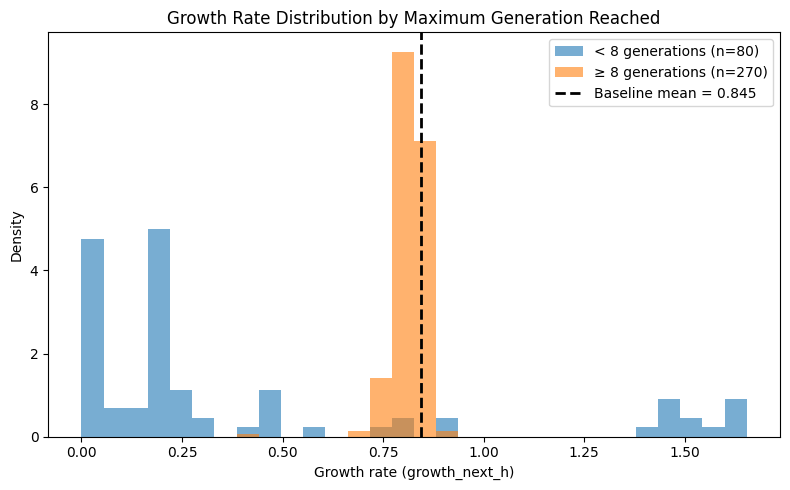

In [22]:
"""
Plot the growth rate distribution comparing TUs that reached at least 8 generations
vs those that stopped before 8 generations (including NaN max_generation cases,
which indicate simulations that did not reach the 8th generation).

Reference for max generation:
    "max_generation" in
    /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv

Reference for growth rate:
    "growth_next_h" in
    /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset.csv

Matching columns:
    "TU_id" in the max generation file corresponds to "ko_tu_id" in the training dataset.

Processing steps:
    - Growth rates are aggregated by averaging over lineage_seed for the first two seeds to obtain TU-level values.
    - Baseline growth rates are averaged across seeds to provide a single reference value.
    - max_generation NaN values are treated as "< 8 generations" group.
    - A vertical line is used to indicate the baseline mean growth rate.
"""
import pandas as pd
import matplotlib.pyplot as plt

# Out
out_dir = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO"

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset.csv"
)

# TU-level max generation (KEEP NaNs)
gen_df = gen_df[["TU_id", "max_generation"]].drop_duplicates("TU_id")

# Growth preprocessing (unchanged)
baseline = train_df[train_df["ko_tu_id"] == "baseline"]

ko_df = train_df[train_df["ko_tu_id"] != "baseline"]

# keep only first two seeds per TU
ko_df = ko_df.sort_values(["ko_tu_id", "lineage_seed"])

ko_df = ko_df.groupby("ko_tu_id").head(2)

# average over those two seeds for each TU
ko_df = (
    ko_df.groupby("ko_tu_id", as_index=False)["growth_next_h"]
    .mean()
)

# baseline mean (average across also two seeds, as there are only seeds 100 and 101)
baseline_mean = baseline.groupby("lineage_seed")["growth_next_h"].mean().mean()

# merge (keep NaNs)
df = gen_df.merge(
    ko_df,
    left_on="TU_id",
    right_on="ko_tu_id",
    how="left"
)

print("Total TU IDs:", len(df))

# ---- FIX: NaNs belong to "< 8" group ----
stopped_before_8 = df.loc[
    (df["max_generation"] < 8) | (df["max_generation"].isna()),
    "growth_next_h"
]

reached_8_plus = df.loc[df["max_generation"] >= 8, "growth_next_h"]

# Shared bins
valid_vals = df["growth_next_h"].dropna()
bins = 30
bin_range = (valid_vals.min(), valid_vals.max())

plt.figure(figsize=(8, 5))

plt.hist(stopped_before_8, bins=bins, range=bin_range, alpha=0.6, density=True,
         label=f"< 8 generations (n={len(stopped_before_8)})")

plt.hist(reached_8_plus, bins=bins, range=bin_range, alpha=0.6, density=True,
         label=f"≥ 8 generations (n={len(reached_8_plus)})")

# baseline reference line
plt.axvline(
    baseline_mean,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Baseline mean = {baseline_mean:.3f}"
)

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir + "/growth_rate_distribution_TU_level.png")
plt.show()

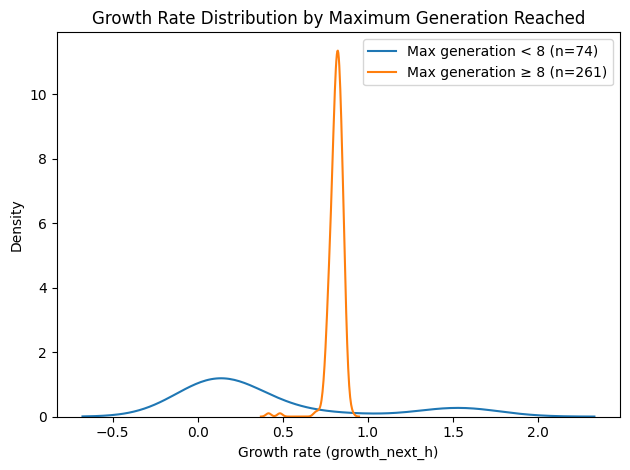

In [18]:
"""Alternative: KDE plot for smoother distribution comparison."""

import seaborn as sns

sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")
sns.kdeplot(reached_8_plus, label=f"Max generation ≥ 8 (n={len(reached_8_plus)})")

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.show()

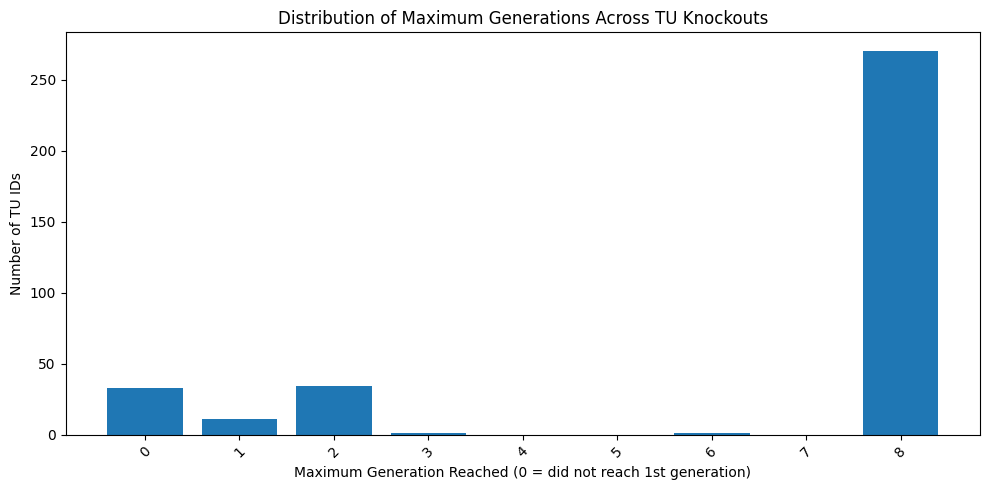

In [ ]:
"""Inspect the max generation distribution across TUs only"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Count TUs at each maximum generation
gen_df["max_generation"] = gen_df["max_generation"].fillna(0)

gen_counts = (
    gen_df["max_generation"]
    .value_counts()
    .sort_index()
)

# Ensure 0 is included even if absent
all_gens = np.arange(0, gen_counts.index.max() + 1)
gen_counts = gen_counts.reindex(all_gens, fill_value=0)

# Plot
plt.figure(figsize=(10, 5))

plt.bar(gen_counts.index, gen_counts.values)

plt.xlabel("Maximum Generation Reached (0 = did not reach 1st generation)")
plt.ylabel("Number of TU IDs")
plt.title("Distribution of Maximum Generations Across TU Knockouts")

plt.xticks(gen_counts.index, rotation=45)
plt.tight_layout()
plt.show()

### Filtered training data - for the simulation failed to succeed to 8th generation take the growth rate as zero

In [18]:
"""Further filtering of training dataset: make the growth rate to zero for all samples where max_generation < 8. 
This is to reflect the fact that these lineages effectively failed to grow and should have zero growth rate, 
even if the measured growth_next_h is non-zero due to noise or short-term growth before collapse.
Save it to a new csv for data inspection."""
import pandas as pd

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset.csv"
)

# TU-level max generation (keep NaN)
gen_df = gen_df[["TU_id", "max_generation"]].drop_duplicates("TU_id")

# Merge
df = train_df.merge(
    gen_df,
    left_on="ko_tu_id",
    right_on="TU_id",
    how="left"
)

# ---- IMPORTANT: separate baseline ----
baseline_mask = df["ko_tu_id"] == "baseline"

# Apply rule ONLY to KO samples
ko_mask = ~baseline_mask

df.loc[ko_mask & (df["max_generation"] < 8), "growth_next_h"] = 0
df.loc[ko_mask & (df["max_generation"].isna()), "growth_next_h"] = 0

# baseline stays untouched (no modification)

# Clean helper column
df = df.drop(columns=["TU_id"])

# Save
output_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered.csv"
df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print("Baseline preserved:", df.loc[baseline_mask, "growth_next_h"].describe())

Saved: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered.csv
Baseline preserved: count    6.000000
mean     0.845027
std      0.060865
min      0.803330
25%      0.803330
50%      0.808305
75%      0.895905
max      0.923446
Name: growth_next_h, dtype: float64


Total operon IDs: 335


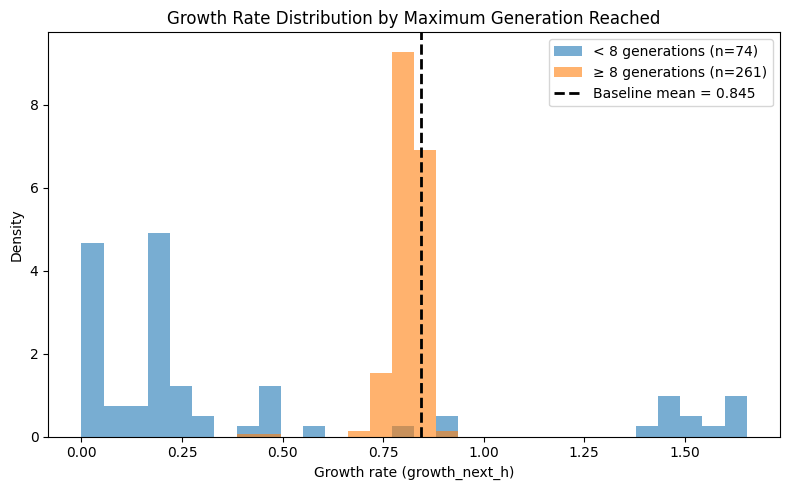

In [ ]:
"""
Plot the growth rate distribution comparing TUs that reached at least 8 generations
vs those that stopped before 8 generations (including NaN max_generation cases,
which indicate simulations that did not reach the 8th generation).

Reference for max generation:
    "max_generation" in
    /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv

Reference for growth rate:
    "growth_next_h" in
    /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered.csv

Matching columns:
    "TU_id" in the max generation file corresponds to "ko_tu_id" in the training dataset.

Processing steps:
    - Growth rates are aggregated by averaging over lineage_seed for the first two seeds to obtain TU-level values.
    - Baseline growth rates are averaged across seeds to provide a single reference value.
    - max_generation NaN values are treated as "< 8 generations" group.
    - A vertical line is used to indicate the baseline mean growth rate.
"""
import pandas as pd
import matplotlib.pyplot as plt

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered.csv"
)

# TU-level max generation (KEEP NaNs)
gen_df = gen_df[["TU_id", "max_generation"]].drop_duplicates("TU_id")

# Growth preprocessing (unchanged)
baseline = train_df[train_df["ko_tu_id"] == "baseline"]

ko_df = train_df[train_df["ko_tu_id"] != "baseline"]

# keep only first two seeds per TU
ko_df = ko_df.sort_values(["ko_tu_id", "lineage_seed"])

ko_df = ko_df.groupby("ko_tu_id").head(2)

# average over those two seeds for each TU
ko_df = (
    ko_df.groupby("ko_tu_id", as_index=False)["growth_next_h"]
    .mean()
)

# baseline mean (average across also two seeds, as there are only seeds 100 and 101)
baseline_mean = baseline.groupby("lineage_seed")["growth_next_h"].mean().mean()

# merge (keep NaNs)
df = gen_df.merge(
    ko_df,
    left_on="TU_id",
    right_on="ko_tu_id",
    how="left"
)

print("Total TU IDs:", len(df))

# ---- FIX: NaNs belong to "< 8" group ----
stopped_before_8 = df.loc[
    (df["max_generation"] < 8) | (df["max_generation"].isna()),
    "growth_next_h"
]

reached_8_plus = df.loc[df["max_generation"] >= 8, "growth_next_h"]

# Shared bins
valid_vals = df["growth_next_h"].dropna()
bins = 30
bin_range = (valid_vals.min(), valid_vals.max())

plt.figure(figsize=(8, 5))

plt.hist(stopped_before_8, bins=bins, range=bin_range, alpha=0.6, density=True,
         label=f"< 8 generations (n={len(stopped_before_8)})")

plt.hist(reached_8_plus, bins=bins, range=bin_range, alpha=0.6, density=True,
         label=f"≥ 8 generations (n={len(reached_8_plus)})")

# baseline reference line
plt.axvline(
    baseline_mean,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Baseline mean = {baseline_mean:.3f}"
)

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2255063/413361357.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")


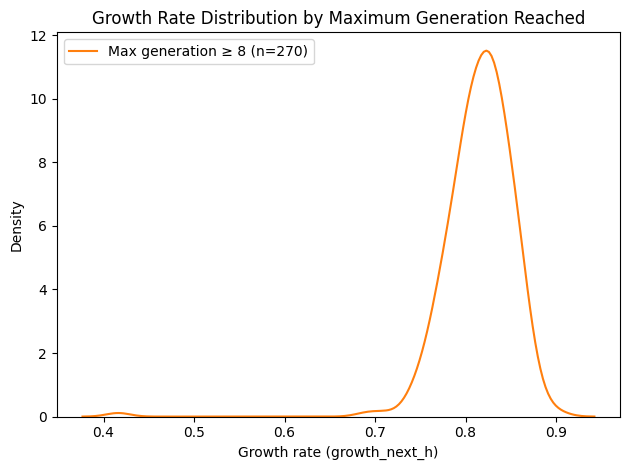

In [20]:
import seaborn as sns

sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")
sns.kdeplot(reached_8_plus, label=f"Max generation ≥ 8 (n={len(reached_8_plus)})")

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.show()

### Filtering training dataset - so only unique TU IDs and seeds are kept

In [1]:
import pandas as pd
from pathlib import Path

input_file = Path(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/"
    "TU_level_training_dataset_growth_filtered.csv"
)

output_file = input_file.with_name(
    input_file.stem + "2.csv"
)

# Load dataset
df = pd.read_csv(input_file)

# Keep first occurrence of each TU ID + seed combination
df_trimmed = df.drop_duplicates(
    subset=["ko_tu_id", "lineage_seed"],
    keep="first"
)

# Save
df_trimmed.to_csv(output_file, index=False)

print(f"Original rows: {len(df)}")
print(f"Trimmed rows: {len(df_trimmed)}")
print(f"Saved to: {output_file}")

Original rows: 796
Trimmed rows: 724
Saved to: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered2.csv


In [20]:
"""TU-level training dataset construction (fixed 350-TU reference space)"""

from pathlib import Path
import re
import numpy as np
import pandas as pd

# ============================
# PATHS
# ============================
BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.parquet",
]

SUMMARY_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed100_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed100_all.csv",
]

TU_GROUP_FILE = BASE / "surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv"


# ============================
# HELPERS
# ============================
def infer_seed(path: Path) -> int:
    m = re.search(r"seed(\d+)", path.name)
    if not m:
        raise ValueError(f"No seed in {path}")
    return int(m.group(1))


def load_timeseries(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)

    required = {
        "project",
        "variant",
        "label",
        "time",
        "listeners__mass__instantaneous_growth_rate",
        "listeners__mass__dry_mass",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    df["listeners__mass__instantaneous_growth_rate"] = pd.to_numeric(
        df["listeners__mass__instantaneous_growth_rate"], errors="coerce"
    )
    df["listeners__mass__dry_mass"] = pd.to_numeric(
        df["listeners__mass__dry_mass"], errors="coerce"
    )

    return df


def load_summary(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = {
        "project",
        "variant",
        "label",
        "mean_growth_rate",
        "median_growth_rate",
        "std_growth_rate",
        "max_growth_rate",
        "initial_dry_mass",
        "final_dry_mass",
        "max_dry_mass",
        "fold_change_mass",
        "duration_sec",
        "n_timepoints",
        "generations_used",
    }

    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")

    for c in required - {"project", "variant", "label"}:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


def summarize_timeseries(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ["source_file", "lineage_seed", "project", "variant", "label"]

    for keys, g in df.groupby(group_cols, dropna=False, sort=False):
        growth = g["listeners__mass__instantaneous_growth_rate"].to_numpy()
        mass = g["listeners__mass__dry_mass"].to_numpy()
        t = g["time"].to_numpy()

        rows.append(
            {
                "source_file": keys[0],
                "lineage_seed": keys[1],
                "project": keys[2],
                "variant": keys[3],
                "label": keys[4],
                "mean_growth_rate": float(np.mean(growth)),
                "median_growth_rate": float(np.median(growth)),
                "std_growth_rate": float(np.std(growth)),
                "max_growth_rate": float(np.max(growth)),
                "initial_dry_mass": float(mass[0]),
                "final_dry_mass": float(mass[-1]),
                "max_dry_mass": float(np.max(mass)),
                "fold_change_mass": float(mass[-1] / mass[0]),
                "duration_sec": float(t[-1] - t[0]),
                "n_timepoints": int(len(g)),
            }
        )

    return pd.DataFrame(rows)


# ============================
# LOAD DATA
# ============================
timeseries_df = pd.concat([load_timeseries(p) for p in TIMESERIES_FILES], ignore_index=True)
summary_df = pd.concat([load_summary(p) for p in SUMMARY_FILES], ignore_index=True)

# ============================
# TU REFERENCE (CRITICAL FIX)
# ============================
tu_map = pd.read_csv(TU_GROUP_FILE).dropna(subset=["TU_id"])

ALL_TU_IDS = sorted(tu_map["TU_id"].astype(str).unique().tolist())

print("TU universe size (must be 350):", len(ALL_TU_IDS))
assert len(ALL_TU_IDS) == 350, "TU reference is NOT 350 — check TU file"


gene_to_tu = dict(zip(
    tu_map["gene_knockout"].astype(str),
    tu_map["TU_id"].astype(str)
))


def to_tu(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    if x.startswith("TU"):
        return x
    return gene_to_tu.get(x, pd.NA)


# ============================
# APPLY TU MAPPING
# ============================
summary_df = summary_df.sort_values(
    ["lineage_seed", "project", "variant", "label"]
).reset_index(drop=True)

summary_df["ko_tu_id"] = summary_df["label"].apply(to_tu)
summary_df["run_type"] = np.where(summary_df["label"].astype(str).eq("baseline"), "baseline", "KO")

missing = summary_df["ko_tu_id"].isna().sum()
print("Unmapped labels:", missing)

# ============================
# TARGET VARIABLES
# ============================
summary_df["growth_next_h"] = summary_df["mean_growth_rate"].astype(float) * 3600.0
summary_df["current_growth_h"] = summary_df["growth_next_h"]
summary_df["current_dry_mass_g"] = summary_df["initial_dry_mass"].astype(float)

summary_df["sample_id"] = (
    summary_df["project"].astype(str)
    + "|v" + summary_df["variant"].astype(str)
    + "|s" + summary_df["lineage_seed"].astype(str)
    + "|" + summary_df["label"].astype(str)
)

# ============================
# TU FEATURE SPACE (FIXED TO 350)
# ============================
tu_onehot = pd.get_dummies(summary_df["ko_tu_id"], dtype=np.int8)

tu_onehot = tu_onehot.reindex(columns=ALL_TU_IDS, fill_value=0)

tu_onehot.columns = [f"tu_available__{c}" for c in tu_onehot.columns]

tu_available = (1 - tu_onehot).astype(np.int8)

# HARD CHECK
print("Feature dimension:", tu_available.shape[1])
assert tu_available.shape[1] == 350, "Feature space is NOT 350 TU IDs"

# ============================
# TRAINING DATA
# ============================
training_data = pd.concat(
    [
        summary_df[
            [
                "sample_id",
                "source_file",
                "lineage_seed",
                "project",
                "variant",
                "label",
                "run_type",
                "ko_tu_id",
                "mean_growth_rate",
                "median_growth_rate",
                "std_growth_rate",
                "max_growth_rate",
                "initial_dry_mass",
                "final_dry_mass",
                "max_dry_mass",
                "fold_change_mass",
                "duration_sec",
                "n_timepoints",
                "generations_used",
                "growth_next_h",
                "current_growth_h",
                "current_dry_mass_g",
            ]
        ].reset_index(drop=True),
        tu_available.reset_index(drop=True),
    ],
    axis=1,
)

# ============================
# SAVE
# ============================
out = TRAIN_DIR / "TU_level_training_dataset_FIXED.parquet"
training_data.to_parquet(out, index=False)

print("Saved:", out)
print("Rows:", len(training_data))
print("Unique TU IDs:", len(ALL_TU_IDS))

TU universe size (must be 350): 350
Unmapped labels: 796
Feature dimension: 350
Saved: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_FIXED.parquet
Rows: 796
Unique TU IDs: 350


/user/home/il22158/work/vEcoli/surrogate/rest_tu_ids_to_test.csv

/user/home/il22158/work/vEcoli/surrogate/train_data/surrogate_gene_catalog.csv

In [11]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd

BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_CSV = SURROGATE_DIR / "results/default_KO/gene_knockout_generation_summary.csv"
REST_TU_CSV = SURROGATE_DIR / "rest_tu_ids_to_test.csv"
CATALOG_CSV = SURROGATE_DIR / "train_data/surrogate_gene_catalog.csv"

summary_df = pd.read_csv(SUMMARY_CSV)
rest_tu_df = pd.read_csv(REST_TU_CSV)
gene_catalog = pd.read_csv(CATALOG_CSV)

summary_df["gene_knockout"] = summary_df["gene_knockout"].astype("string")
summary_df["project_name"] = summary_df["project_name"].astype("string")
summary_df["variant"] = pd.to_numeric(summary_df["variant"], errors="coerce").astype("Int64")
summary_df["seed"] = pd.to_numeric(summary_df["seed"], errors="coerce").astype("Int64")
summary_df["max_generation"] = pd.to_numeric(summary_df["max_generation"], errors="coerce")
summary_df["s_pq"] = summary_df["s_pq"].astype("string").str.lower().isin(["true", "1", "yes"])

catalog_gene_ids = sorted(gene_catalog["gene_id"].dropna().astype(str).str.strip().unique().tolist())
if not catalog_gene_ids:
    raise RuntimeError("No gene_id values found in surrogate_gene_catalog.csv")

rest_tu_df = rest_tu_df.rename(columns={"tu_id": "ko_target_id"})
rest_tu_df["ko_target_id"] = rest_tu_df["ko_target_id"].astype(str).str.strip()
rest_tu_map = (
    rest_tu_df[["ko_target_id", "genes_in_rest_gene_to_test"]]
    .dropna(subset=["ko_target_id"])
    .drop_duplicates("ko_target_id")
    .set_index("ko_target_id")["genes_in_rest_gene_to_test"]
    .to_dict()
)

gene_catalog["gene_id"] = gene_catalog["gene_id"].astype(str).str.strip()
gene_catalog["tu_id"] = gene_catalog["tu_id"].astype(str).str.strip()

by_tu_map = (
    gene_catalog.loc[gene_catalog["tu_id"].ne(""), ["tu_id", "gene_id"]]
    .drop_duplicates()
    .groupby("tu_id")["gene_id"]
    .apply(list)
    .to_dict()
)

def parse_rna_ids(value: object) -> list[str]:
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass
    return [text]

rna_to_gene_map: dict[str, list[str]] = {}
for _, row in gene_catalog[["gene_id", "rna_ids"]].dropna(subset=["gene_id"]).iterrows():
    gid = str(row["gene_id"]).strip()
    for rid in parse_rna_ids(row.get("rna_ids")):
        keys = {rid, f"{rid}[c]", rid.replace("[c]", "")}
        for key in keys:
            if key not in rna_to_gene_map:
                rna_to_gene_map[key] = []
            if gid not in rna_to_gene_map[key]:
                rna_to_gene_map[key].append(gid)

catalog_gene_id_set = set(catalog_gene_ids)

def map_ko_target_to_gene_ids(ko_target: object) -> list[str]:
    if pd.isna(ko_target):
        return []
    text = str(ko_target).strip()
    if not text or text == "baseline":
        return []

    if text in rest_tu_map and pd.notna(rest_tu_map[text]):
        genes = [g.strip() for g in str(rest_tu_map[text]).split(",") if g.strip()]
        genes = [g for g in genes if g in catalog_gene_id_set]
        if genes:
            return sorted(set(genes))

    if text in catalog_gene_id_set:
        return [text]

    if text in by_tu_map:
        genes = [g for g in by_tu_map[text] if g in catalog_gene_id_set]
        if genes:
            return sorted(set(genes))

    if text in rna_to_gene_map:
        genes = [g for g in rna_to_gene_map[text] if g in catalog_gene_id_set]
        if genes:
            return sorted(set(genes))

    stripped = text.replace("[c]", "")
    if stripped in rna_to_gene_map:
        genes = [g for g in rna_to_gene_map[stripped] if g in catalog_gene_id_set]
        if genes:
            return sorted(set(genes))

    return []

summary_df["ko_target_id"] = summary_df["gene_knockout"].astype(str).str.strip()
summary_df["ko_gene_ids"] = summary_df["ko_target_id"].map(map_ko_target_to_gene_ids)
summary_df["ko_gene_count"] = summary_df["ko_gene_ids"].map(len)
summary_df["gene_id"] = summary_df["ko_gene_ids"].map(lambda ids: ids[0] if ids else pd.NA).astype("string")
summary_df["ko_gene_id"] = summary_df["gene_id"]
summary_df["run_type"] = np.where(summary_df["ko_target_id"].eq("baseline"), "baseline", "KO")

feature_names = [f"gene_available__{g}" for g in catalog_gene_ids]
genotype_available = pd.DataFrame(
    np.ones((len(summary_df), len(catalog_gene_ids)), dtype=np.int8),
    columns=feature_names,
    index=summary_df.index,
)

gene_to_col = {g: f"gene_available__{g}" for g in catalog_gene_ids}
for idx, ids in summary_df["ko_gene_ids"].items():
    for gid in ids:
        col = gene_to_col.get(gid)
        if col is not None:
            genotype_available.at[idx, col] = 0

summary_df["project"] = summary_df["project_name"].astype(str)
summary_df["lineage_seed"] = summary_df["seed"]
summary_df["label"] = np.where(summary_df["ko_target_id"].eq("baseline"), "baseline", "KO: " + summary_df["ko_target_id"].astype(str))
summary_df["source_file"] = "gene_knockout_generation_summary.csv"
summary_df["growth_next_h"] = summary_df["max_generation"].astype(float)
summary_df["current_growth_h"] = summary_df["growth_next_h"]
summary_df["current_dry_mass_g"] = pd.NA
summary_df["current_generation"] = 0
summary_df["target_generation"] = 1
summary_df["gen_step"] = 1
summary_df["peak_generation"] = pd.NA
summary_df["peak_censored"] = False
summary_df["is_pre_peak"] = True
summary_df["sample_id"] = (
    summary_df["project"].astype(str)
    + "|v"
    + summary_df["variant"].astype(str)
    + "|s"
    + summary_df["lineage_seed"].astype(str)
    + "|"
    + summary_df["ko_target_id"].astype(str)
)

training_data = pd.concat(
    [
        summary_df[
            [
                "sample_id",
                "source_file",
                "lineage_seed",
                "project",
                "variant",
                "label",
                "run_type",
                "gene_id",
                "ko_gene_id",
                "ko_target_id",
                "ko_gene_count",
                "max_generation",
                "s_pq",
                "current_generation",
                "target_generation",
                "gen_step",
                "current_growth_h",
                "growth_next_h",
                "current_dry_mass_g",
                "peak_generation",
                "peak_censored",
                "is_pre_peak",
            ]
        ].reset_index(drop=True),
        genotype_available.reset_index(drop=True),
    ],
    axis=1,
)

training_data["ko_gene_ids"] = summary_df["ko_gene_ids"].map(lambda ids: ",".join(ids) if ids else "")

baseline_ref = training_data.loc[training_data["run_type"].eq("baseline"), "growth_next_h"].reset_index(drop=True)
baseline_next_growth = baseline_ref.copy()

out_parquet = TRAIN_DIR / "default_ko_training_dataset_mapped.parquet"
out_csv = TRAIN_DIR / "default_ko_training_dataset_mapped.csv"
feature_list_csv = TRAIN_DIR / "default_ko_genotype_feature_list_mapped.csv"

training_data.to_parquet(out_parquet, index=False)
training_data.to_csv(out_csv, index=False)
pd.DataFrame({"feature_name": feature_names}).to_csv(feature_list_csv, index=False)

unmapped = training_data.loc[
    training_data["run_type"].eq("KO") & training_data["ko_gene_ids"].eq(""),
    "ko_target_id",
].drop_duplicates().sort_values()

print("Reconstructed default KO training_data with TU/RNA -> gene mapping")
print(f"Rows: {len(training_data)}")
print(f"KO rows: {int(training_data['run_type'].eq('KO').sum())}")
print(f"Baseline rows: {int(training_data['run_type'].eq('baseline').sum())}")
print(f"Gene feature count: {len(feature_names)}")
print(f"Unmapped KO targets: {len(unmapped)}")
if len(unmapped) > 0:
    print(unmapped.head(20).to_string(index=False))
print(f"Saved dataset: {out_parquet}")
print(f"Saved csv: {out_csv}")
print(f"Saved features: {feature_list_csv}")

Operon universe size: 334
Reconstructed default KO training_data with operon-based features
Rows: 731
KO rows: 725
Baseline rows: 6
Operon feature count: 334
Unmapped KO targets: 0
Saved dataset: /user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_operon_training_dataset_FIXED.parquet
Saved csv: /user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_operon_training_dataset_FIXED.csv
Saved features: /user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_operon_feature_list.csv


In [49]:
from pathlib import Path

import numpy as np
import pandas as pd

BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
DEFAULT_KO_DIR = SURROGATE_DIR / "results/default_KO"
SUMMARY_CSV = DEFAULT_KO_DIR / "gene_knockout_generation_summary.csv"
ADJACENT_RISE_SCALE = 2.0

summary_df = pd.read_csv(SUMMARY_CSV)
summary_df["variant"] = pd.to_numeric(summary_df["variant"], errors="coerce").astype("Int64")
summary_df["seed"] = pd.to_numeric(summary_df["seed"], errors="coerce").astype("Int64")
summary_df["project_name"] = summary_df["project_name"].astype("string")
summary_df["gene_knockout"] = summary_df["gene_knockout"].astype("string")
summary_df["max_generation"] = pd.to_numeric(summary_df["max_generation"], errors="coerce").astype("Int64")
summary_df["s_pq"] = summary_df["s_pq"].astype("string").str.lower().isin(["true", "1", "yes"])
summary_df["succeeds_to_8"] = summary_df["max_generation"].ge(8)
summary_df["failed_before_8"] = summary_df["gene_knockout"].astype(str).ne("baseline") & ~summary_df["succeeds_to_8"]

default_df = summary_df.copy()
default_df["run_type"] = np.where(default_df["gene_knockout"].astype(str).eq("baseline"), "baseline", "KO")
default_df["gene_id"] = default_df["gene_knockout"].map(lambda value: pd.NA if pd.isna(value) or str(value).strip() == "baseline" else str(value).split(";", 1)[0].strip()).astype("string")
default_df["growth_next_h"] = pd.to_numeric(default_df["max_generation"], errors="coerce")
default_df["current_growth_h"] = default_df["growth_next_h"]
default_df["current_generation"] = 0
default_df["current_dry_mass_g"] = pd.NA
default_df["target_generation"] = 1
default_df["gen_step"] = 1
default_df["peak_generation"] = pd.NA
default_df["peak_censored"] = False
default_df["is_pre_peak"] = True
default_df["sample_id"] = default_df["project_name"].astype(str) + "|v" + default_df["variant"].astype(str) + "|s" + default_df["seed"].astype(str) + "|" + default_df["gene_knockout"].astype(str)

print("=== Default KO abnormality check ===")
print(f"Rows loaded: {len(default_df)}")
print(f"KO rows that do not succeed to generation 8: {int(default_df['failed_before_8'].sum())}")
print(f"KO rows succeeding to generation 8: {int((default_df['run_type'].eq('KO') & default_df['succeeds_to_8']).sum())}")

if bool(default_df['failed_before_8'].any()):
    cols = [c for c in ["project_name", "variant", "seed", "gene_knockout", "max_generation", "s_pq", "succeeds_to_8"] if c in default_df.columns]
    print(default_df.loc[default_df['failed_before_8'], cols].head(20).to_string(index=False))

if "training_data" in globals():
    training_df = training_data.copy()
    sort_cols = [c for c in ["source_file", "project", "variant", "lineage_seed", "label", "gene_id", "run_type", "current_generation"] if c in training_df.columns]
    if sort_cols:
        training_df = training_df.sort_values(sort_cols).copy()

    if {"growth_next_h", "current_growth_h"}.issubset(training_df.columns):
        next_growth = pd.to_numeric(training_df.get("growth_next_h"), errors="coerce")
        current_growth = pd.to_numeric(training_df.get("current_growth_h"), errors="coerce")
        custom_abnormal_mask = next_growth.notna() & current_growth.notna() & (next_growth > current_growth * ADJACENT_RISE_SCALE)
        print("\n=== Custom adjacent-rise check on training_data ===")
        print(f"Rows loaded: {len(training_df)}")
        print(f"Rows with next > {ADJACENT_RISE_SCALE:g} * current: {int(custom_abnormal_mask.sum())}")
        if bool(custom_abnormal_mask.any()):
            show_cols = [c for c in ["project", "variant", "lineage_seed", "label", "gene_id", "current_generation", "growth_next_h", "current_growth_h"] if c in training_df.columns]
            print(training_df.loc[custom_abnormal_mask, show_cols].head(20).to_string(index=False))

=== Default KO abnormality check ===
Rows loaded: 575
KO rows that do not succeed to generation 8: 83
KO rows succeeding to generation 8: 478
                       project_name  variant  seed gene_knockout  max_generation  s_pq  succeeds_to_8
gene_knockout_TU_ID_rest_list_rerun        6    10   TU0-1021[c]               1  True          False
gene_knockout_TU_ID_rest_list_rerun        6    11   TU0-1021[c]               1  True          False
gene_knockout_TU_ID_rest_list_rerun       25    10  TU0-13080[c]               2  True          False
gene_knockout_TU_ID_rest_list_rerun       25    11  TU0-13080[c]               2  True          False
gene_knockout_TU_ID_rest_list_rerun       28    10  TU0-13093[c]               2  True          False
gene_knockout_TU_ID_rest_list_rerun       28    11  TU0-13093[c]               2  True          False
gene_knockout_TU_ID_rest_list_rerun       31    10  TU0-13135[c]               1  True          False
gene_knockout_TU_ID_rest_list_rerun       

## Data Validity Check

In [19]:
from pathlib import Path
import json

import pandas as pd
import pyarrow.parquet as pq

roots = [
    Path("/user/home/il22158/work/vEcoli/out/gene_knockout_TU_ID_rest_list_rerun2"),
    Path("/user/home/il22158/work/vEcoli/out/gene_knockout_TU_ID_rest_list_rerun"),
]
output_dir = Path("/user/home/il22158/work/vEcoli/surrogate/results/default_KO")
output_dir.mkdir(parents=True, exist_ok=True)

rest_tu_csv = Path("/user/home/il22158/work/vEcoli/surrogate/rest_tu_ids_to_test.csv")
rest_tu_df = pd.read_csv(rest_tu_csv)
rest_tu_df = rest_tu_df.rename(
    columns={
        "tu_id": "gene_knockout",
        "genes_in_rest_gene_to_test": "associated_genes",
        "n_genes_in_rest_gene_to_test": "associated_gene_total_numbers",
    }
)
rest_tu_df = rest_tu_df[["gene_knockout", "associated_genes", "associated_gene_total_numbers"]]

records = []

for root in roots:
    metadata_path = root / "variant_sim_data" / "metadata.json"
    if not metadata_path.exists():
        raise FileNotFoundError(f"Missing metadata file: {metadata_path}")

    with metadata_path.open() as handle:
        metadata = json.load(handle)

    variant_map = metadata.get("gene_knockout", {})
    project_name = root.name
    success_root = root / "success" / f"experiment_id={project_name}"

    for variant_key, variant_info in sorted(variant_map.items(), key=lambda item: int(item[0])):
        variant = int(variant_key)
        gene_knockout = ";".join(variant_info.get("genes_to_knockout", []))
        variant_dir = success_root / f"variant={variant}"
        seed_dirs = sorted(variant_dir.glob("lineage_seed=*"), key=lambda path: int(path.name.split("=", 1)[1]))

        if not seed_dirs:
            records.append(
                {
                    "gene_knockout": gene_knockout,
                    "variant": variant,
                    "seed": pd.NA,
                    "project_name": project_name,
                    "max_generation": pd.NA,
                    "s_pq": pd.NA,
                }
            )
            continue

        for seed_dir in seed_dirs:
            seed = int(seed_dir.name.split("=", 1)[1])
            generation_dirs = sorted(
                seed_dir.glob("generation=*"),
                key=lambda path: int(path.name.split("=", 1)[1]),
            )

            if not generation_dirs:
                records.append(
                    {
                        "gene_knockout": gene_knockout,
                        "variant": variant,
                        "seed": seed,
                        "project_name": project_name,
                        "max_generation": pd.NA,
                        "s_pq": pd.NA,
                    }
                )
                continue

            last_generation_dir = generation_dirs[-1]
            max_generation = int(last_generation_dir.name.split("=", 1)[1])
            pq_files = sorted(last_generation_dir.glob("agent_id=*/s.pq"))

            if pq_files:
                pq_path = pq_files[0]
                table = pq.read_table(pq_path)
                row = table.to_pandas().iloc[0]
                s_pq = bool(row.get("success", row.get("s.pq", False)))
            else:
                s_pq = pd.NA

            records.append(
                {
                    "gene_knockout": gene_knockout,
                    "variant": variant,
                    "seed": seed,
                    "project_name": project_name,
                    "max_generation": max_generation,
                    "s_pq": s_pq,
                }
            )

summary = pd.DataFrame(records)
if summary.empty:
    raise RuntimeError("No variant rows were produced from the requested output trees.")

summary = summary.merge(rest_tu_df, on="gene_knockout", how="left")
summary = summary.sort_values(
    ["project_name", "variant", "seed", "max_generation"],
    na_position="last",
).reset_index(drop=True)

combined_path = output_dir / "gene_knockout_generation_summary.csv"
summary.to_csv(combined_path, index=False)

for project_name, project_df in summary.groupby("project_name", sort=False):
    project_path = output_dir / f"gene_knockout_generation_summary_{project_name}.csv"
    project_df.to_csv(project_path, index=False)

print(f"Wrote {len(summary)} rows to {combined_path}")
print(summary.head(20).to_string(index=False))

Wrote 567 rows to /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary.csv
 gene_knockout  variant seed                        project_name max_generation s_pq associated_genes  associated_gene_total_numbers
EG10214_RNA[c]        1   10 gene_knockout_TU_ID_rest_list_rerun              8 True          EG10214                              1
EG10214_RNA[c]        1   11 gene_knockout_TU_ID_rest_list_rerun              8 True          EG10214                              1
EG10383_RNA[c]        2 <NA> gene_knockout_TU_ID_rest_list_rerun           <NA> <NA>          EG10383                              1
EG10982_RNA[c]        3   10 gene_knockout_TU_ID_rest_list_rerun              8 True          EG10982                              1
EG10982_RNA[c]        3   11 gene_knockout_TU_ID_rest_list_rerun              8 True          EG10982                              1
EG12662_RNA[c]        4   10 gene_knockout_TU_ID_rest_list_rerun              8 True   

In [6]:
from pathlib import Path

import pandas as pd

SURROGATE_DIR = Path("/user/home/il22158/work/vEcoli/surrogate")
summary_csv = SURROGATE_DIR / "results/default_KO/gene_knockout_generation_summary.csv"
rest_tu_csv = SURROGATE_DIR / "rest_tu_ids_to_test.csv"
rest_genes_csv = SURROGATE_DIR / "rest_genes_to_test.csv"

summary_df = pd.read_csv(summary_csv)
rest_tu_df = pd.read_csv(rest_tu_csv)
rest_genes_df = pd.read_csv(rest_genes_csv)

# Support either the new names or the original names from rest_tu_ids_to_test.csv.
assoc_genes_col = (
    "associated_genes"
    if "associated_genes" in summary_df.columns
    else "genes_in_rest_gene_to_test"
)
assoc_count_col = (
    "associated_gene_total_numbers"
    if "associated_gene_total_numbers" in summary_df.columns
    else "n_genes_in_rest_gene_to_test"
)

if assoc_count_col not in summary_df.columns:
    raise RuntimeError(
        "No associated-gene count column found in summary CSV. "
        "Expected 'associated_gene_total_numbers' or 'n_genes_in_rest_gene_to_test'."
    )

summary_df[assoc_count_col] = pd.to_numeric(summary_df[assoc_count_col], errors="coerce")

naive_row_sum = int(summary_df[assoc_count_col].fillna(0).sum())

if {"project_name", "variant"}.issubset(summary_df.columns):
    variant_unique = summary_df.drop_duplicates(subset=["project_name", "variant"]).copy()
else:
    variant_unique = summary_df.drop_duplicates(subset=["variant"]).copy()

variant_level_sum = int(variant_unique[assoc_count_col].fillna(0).sum())

rest_gene_rows = int(len(rest_genes_df))
rest_gene_unique = int(rest_genes_df["gene_id"].dropna().astype(str).nunique())

rest_tu_sum = int(pd.to_numeric(rest_tu_df["n_genes_in_rest_gene_to_test"], errors="coerce").fillna(0).sum())

print("=== Gene-count consistency check ===")
print(f"Summary row-level total {assoc_count_col}: {naive_row_sum}")
print(f"Summary variant-level total {assoc_count_col}: {variant_level_sum}")
print(f"rest_tu_ids_to_test total n_genes_in_rest_gene_to_test: {rest_tu_sum}")
print(f"rest_genes_to_test rows: {rest_gene_rows}")
print(f"rest_genes_to_test unique gene_id count: {rest_gene_unique}")
print()

print("Differences")
print(f"variant-level summary - rest_genes unique: {variant_level_sum - rest_gene_unique}")
print(f"rest_tu total - rest_genes unique: {rest_tu_sum - rest_gene_unique}")

if assoc_genes_col in summary_df.columns:
    def extract_genes(series: pd.Series) -> set[str]:
        genes: set[str] = set()
        for value in series.dropna().astype(str):
            for token in value.split(","):
                gene = token.strip()
                if gene:
                    genes.add(gene)
        return genes

    summary_variant_genes = extract_genes(variant_unique[assoc_genes_col])
    rest_genes_set = set(rest_genes_df["gene_id"].dropna().astype(str))

    missing_in_summary = sorted(rest_genes_set - summary_variant_genes)
    extra_in_summary = sorted(summary_variant_genes - rest_genes_set)

    print()
    print(f"Unique associated genes in variant-level summary: {len(summary_variant_genes)}")
    print(f"Genes in rest_genes_to_test but not in summary: {len(missing_in_summary)}")
    print(f"Genes in summary but not in rest_genes_to_test: {len(extra_in_summary)}")

    if missing_in_summary:
        print("Sample missing genes:", missing_in_summary[:20])
    if extra_in_summary:
        print("Sample extra genes:", extra_in_summary[:20])

=== Gene-count consistency check ===
Summary row-level total associated_gene_total_numbers: 695
Summary variant-level total associated_gene_total_numbers: 357
rest_tu_ids_to_test total n_genes_in_rest_gene_to_test: 360
rest_genes_to_test rows: 360
rest_genes_to_test unique gene_id count: 360

Differences
variant-level summary - rest_genes unique: -3
rest_tu total - rest_genes unique: 0

Unique associated genes in variant-level summary: 357
Genes in rest_genes_to_test but not in summary: 3
Genes in summary but not in rest_genes_to_test: 0
Sample missing genes: ['EG10016', 'G6941', 'G6943']


In [9]:
from pathlib import Path
import ast
import json

import pandas as pd

TARGET_GENES = ["EG10016", "G6941", "G6943"]

BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
OUT_DIR = BASE / "out"

rest_tu_path = SURROGATE_DIR / "rest_tu_ids_to_test.csv"
operon_path = BASE / "reading/results/knockout_experiment/operon_classification.tsv"
metadata_paths = [
    OUT_DIR / "gene_knockout_TU_ID_rest_list_rerun/variant_sim_data/metadata.json",
    OUT_DIR / "gene_knockout_TU_ID_rest_list_rerun2/variant_sim_data/metadata.json",
]

rest_tu_df = pd.read_csv(rest_tu_path)
operon_df = pd.read_csv(operon_path, sep="\t")

# 1) Check whether each target gene is included in rest_tu_ids_to_test.csv.
def split_genes(value: object) -> list[str]:
    if pd.isna(value):
        return []
    return [token.strip() for token in str(value).split(",") if token.strip()]

rest_rows = []
for _, row in rest_tu_df.iterrows():
    for gene in split_genes(row.get("genes_in_rest_gene_to_test")):
        rest_rows.append(
            {
                "gene_id": gene,
                "tu_id_in_rest_tu": row.get("tu_id"),
                "n_genes_in_rest_tu": row.get("n_genes_in_rest_gene_to_test"),
            }
        )
rest_gene_map = pd.DataFrame(rest_rows)

# 2) Check operon_classification.tsv for RNA/TU IDs tied to these genes.
operon_hits = operon_df[operon_df["id"].astype(str).isin(TARGET_GENES)].copy()

# Build acceptable IDs that can appear in metadata.
acceptable_ids_by_gene: dict[str, set[str]] = {gene: set() for gene in TARGET_GENES}
for _, row in operon_hits.iterrows():
    gene = str(row["id"])

    tu_id = row.get("tu_id")
    if isinstance(tu_id, str) and tu_id.strip():
        acceptable_ids_by_gene[gene].add(tu_id.strip())

    rna_ids_raw = row.get("rna_ids")
    if isinstance(rna_ids_raw, str) and rna_ids_raw.strip():
        try:
            parsed = ast.literal_eval(rna_ids_raw)
            if isinstance(parsed, list):
                for rid in parsed:
                    rid = str(rid).strip()
                    if rid:
                        acceptable_ids_by_gene[gene].add(f"{rid}[c]")
        except Exception:
            pass

# 3) Check if those TU/RNA IDs are included in metadata files we used before.
metadata_ids_by_project: dict[str, set[str]] = {}
for metadata_path in metadata_paths:
    project_name = metadata_path.parent.parent.name
    with metadata_path.open() as handle:
        metadata = json.load(handle)
    variant_map = metadata.get("gene_knockout", {})
    ids = set()
    for item in variant_map.values():
        for ko in item.get("genes_to_knockout", []):
            ids.add(str(ko).strip())
    metadata_ids_by_project[project_name] = ids

# Print detailed check.
print("=== Inclusion in rest_tu_ids_to_test.csv ===")
for gene in TARGET_GENES:
    hit = rest_gene_map[rest_gene_map["gene_id"].eq(gene)]
    print(f"{gene}: {'YES' if not hit.empty else 'NO'}")
    if not hit.empty:
        print(hit.to_string(index=False))

print("\n=== TU/RNA IDs from operon_classification.tsv ===")
if operon_hits.empty:
    print("No rows found in operon_classification.tsv for target genes.")
else:
    print(
        operon_hits[
            [
                "id",
                "tu_id",
                "rna_ids",
                "is_single_gene_operon",
                "operon_size",
                "other_genes_in_operon",
            ]
        ].to_string(index=False)
    )

print("\n=== Presence of operon-derived TU/RNA IDs in metadata ===")
rows = []
for gene in TARGET_GENES:
    expected_ids = sorted(acceptable_ids_by_gene.get(gene, set()))
    for project_name, project_ids in metadata_ids_by_project.items():
        matched = sorted(set(expected_ids).intersection(project_ids))
        rows.append(
            {
                "gene_id": gene,
                "project_name": project_name,
                "expected_ids": "; ".join(expected_ids) if expected_ids else "",
                "matched_in_metadata": "; ".join(matched) if matched else "",
                "is_in_metadata": bool(matched),
            }
        )

metadata_check_df = pd.DataFrame(rows)
print(metadata_check_df.to_string(index=False))

=== Inclusion in rest_tu_ids_to_test.csv ===
EG10016: YES
gene_id tu_id_in_rest_tu  n_genes_in_rest_tu
EG10016   EG10016_RNA[c]                   1
G6941: YES
gene_id tu_id_in_rest_tu  n_genes_in_rest_tu
  G6941      TU0-1002[c]                   2
G6943: YES
gene_id tu_id_in_rest_tu  n_genes_in_rest_tu
  G6943      TU0-1002[c]                   2

=== TU/RNA IDs from operon_classification.tsv ===
     id          tu_id         rna_ids  is_single_gene_operon  operon_size   other_genes_in_operon
EG10016 EG10016_RNA[c] ["EG10016_RNA"]                   True          1.0                     NaN
  G6941    TU0-1002[c]   ["G6941_RNA"]                  False          5.0 G6940,G6942,G6943,G6944
  G6943    TU0-1002[c]   ["G6943_RNA"]                  False          5.0 G6940,G6941,G6942,G6944

=== Presence of operon-derived TU/RNA IDs in metadata ===
gene_id                         project_name              expected_ids matched_in_metadata  is_in_metadata
EG10016  gene_knockout_TU_ID_rest_lis

In [14]:
from pathlib import Path
import json

import pandas as pd

leftover_targets = {
    "EG10016": ["EG10016", "EG10016_RNA[c]"],
    "G6941": ["G6941", "TU0-1002[c]", "G6941_RNA[c]"],
    "G6943": ["G6943", "TU0-1002[c]", "G6943_RNA[c]"],
}

config_paths = {
    "rerun": Path("/user/home/il22158/work/vEcoli/configs/N_gene_knockout_TU_ID_rerun.json"),
    "rerun2": Path("/user/home/il22158/work/vEcoli/configs/N_gene_knockout_TU_ID_rerun2.json"),
}


def flatten_knockouts(config_path: Path) -> set[str]:
    with config_path.open() as handle:
        data = json.load(handle)

    knockout_groups = (
        data.get("variants", {})
        .get("gene_knockout", {})
        .get("genes_to_knockout", {})
        .get("value", [])
    )

    knockout_ids: set[str] = set()
    for group in knockout_groups:
        for item in group:
            item_str = str(item).strip()
            if item_str:
                knockout_ids.add(item_str)
    return knockout_ids


rows = []
for config_name, config_path in config_paths.items():
    knockout_ids = flatten_knockouts(config_path)
    for gene, target_ids in leftover_targets.items():
        for target_id in target_ids:
            rows.append(
                {
                    "config": config_name,
                    "gene": gene,
                    "target_id": target_id,
                    "found": target_id in knockout_ids,
                }
            )

result = pd.DataFrame(rows)
if result.empty:
    raise RuntimeError("No rows were generated for the leftover gene search.")

print(result.sort_values(["gene", "config", "target_id"]).to_string(index=False))

config    gene      target_id  found
 rerun EG10016        EG10016  False
 rerun EG10016 EG10016_RNA[c]  False
rerun2 EG10016        EG10016  False
rerun2 EG10016 EG10016_RNA[c]  False
 rerun   G6941          G6941  False
 rerun   G6941   G6941_RNA[c]  False
 rerun   G6941    TU0-1002[c]  False
rerun2   G6941          G6941  False
rerun2   G6941   G6941_RNA[c]  False
rerun2   G6941    TU0-1002[c]  False
 rerun   G6943          G6943  False
 rerun   G6943   G6943_RNA[c]  False
 rerun   G6943    TU0-1002[c]  False
rerun2   G6943          G6943  False
rerun2   G6943   G6943_RNA[c]  False
rerun2   G6943    TU0-1002[c]  False


In [16]:
from pathlib import Path
import json
import re

# projects to check
roots = {
    "gene_knockout_p_list": Path("/user/home/il22158/work/vEcoli/out/gene_knockout_p_list"),
    "gene_knockout_3_round_test": Path("/user/home/il22158/work/vEcoli/out/gene_knockout_3_round_test"),
}

def normalize_gene_id(label: str) -> str:
    if not isinstance(label, str):
        return ""
    text = label.strip()
    if not text:
        return ""
    if text.lower() == "baseline":
        return ""
    text = text.replace("[c]", "")
    if text.endswith("_RNA"):
        text = text[:-len("_RNA")]
    if text.startswith("KO:"):
        text = text.split("KO:", 1)[1]
    return text.strip()

def extract_knockouts_from_variant_info(variant_info) -> set:
    ids = set()
    if isinstance(variant_info, dict):
        genes = variant_info.get("genes_to_knockout", [])
    elif isinstance(variant_info, list):
        genes = variant_info
    else:
        genes = [variant_info]
    for item in genes:
        s = str(item).strip()
        if not s:
            continue
        norm = normalize_gene_id(s)
        if norm:
            ids.add(norm)
    return ids

for proj_name, proj_root in roots.items():
    metadata_path = proj_root / "variant_sim_data" / "metadata.json"
    if not metadata_path.exists():
        print(f"{proj_name}: metadata not found at {metadata_path}")
        continue

    with metadata_path.open() as fh:
        metadata = json.load(fh)

    variant_map = metadata.get("gene_knockout", {}) or {}
    # Count numeric variant keys (common case)
    numeric_variant_keys = []
    for k in variant_map.keys():
        try:
            int(k)
            numeric_variant_keys.append(k)
        except Exception:
            # include non-numeric keys too if present
            numeric_variant_keys.append(k)

    variant_count = len(numeric_variant_keys)

    # Collect normalized unique gene KOs across variants
    unique_gene_kos = set()
    for vinfo in variant_map.values():
        unique_gene_kos.update(extract_knockouts_from_variant_info(vinfo))

    print(f"{proj_name}: variant_count = {variant_count} | unique_normalized_gene_kos = {len(unique_gene_kos)}")
    print(f"Sample genes ({min(20,len(unique_gene_kos))}): {sorted(unique_gene_kos)[:20]}\n")

gene_knockout_p_list: variant_count = 53 | unique_normalized_gene_kos = 52
Sample genes (20): ['EG10196', 'EG10707', 'EG10864', 'EG10865', 'EG10866', 'EG10867', 'EG10868', 'EG10869', 'EG10870', 'EG10872', 'EG10874', 'EG10875', 'EG10876', 'EG10877', 'EG10879', 'EG10880', 'EG10881', 'EG10882', 'EG10883', 'EG10884']

gene_knockout_3_round_test: variant_count = 51 | unique_normalized_gene_kos = 50
Sample genes (20): ['EG10027', 'EG10036', 'EG10052', 'EG10073', 'EG10095', 'EG10099', 'EG10100', 'EG10105', 'EG10109', 'EG10118', 'EG10120', 'EG10137', 'EG10182', 'EG10188', 'EG10361', 'EG10420', 'EG10539', 'EG10549', 'EG10582', 'EG10759']



In [24]:
from pathlib import Path
import json

import pandas as pd
import pyarrow.parquet as pq

# Two projects for test-run summary
roots = {
    "gene_knockout_p_list": Path("/user/home/il22158/work/vEcoli/out/gene_knockout_p_list"),
    "gene_knockout_3_round_test": Path("/user/home/il22158/work/vEcoli/out/gene_knockout_3_round_test"),
}

# Optional consistency checks from metadata
expected = {
    "gene_knockout_p_list": {"variant_count": 53, "unique_normalized_gene_kos": 52},
    "gene_knockout_3_round_test": {"variant_count": 51, "unique_normalized_gene_kos": 50},
}

output_dir = Path("/user/home/il22158/work/vEcoli/surrogate/results/default_KO")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "gene_knockout_generation_summary_test_run.csv"


def normalize_gene_id(text: str) -> str:
    text = str(text).strip()
    if not text or text.lower() == "baseline":
        return ""
    text = text.replace("[c]", "")
    if text.endswith("_RNA"):
        text = text[:-4]
    if text.startswith("KO:"):
        text = text.split("KO:", 1)[1]
    return text.strip()


def genes_from_variant_info(variant_info) -> list[str]:
    if isinstance(variant_info, dict):
        genes = variant_info.get("genes_to_knockout", [])
    elif isinstance(variant_info, list):
        genes = variant_info
    else:
        genes = [variant_info]
    return [str(x).strip() for x in genes if str(x).strip()]


records = []

for project_name, root in roots.items():
    metadata_path = root / "variant_sim_data" / "metadata.json"
    if not metadata_path.exists():
        raise FileNotFoundError(f"Missing metadata file: {metadata_path}")

    with metadata_path.open() as fh:
        metadata = json.load(fh)

    variant_map = metadata.get("gene_knockout", {}) or {}
    numeric_keys = sorted([k for k in variant_map.keys() if str(k).isdigit()], key=lambda x: int(x))

    # Metadata checks
    unique_gene_kos = {
        normalize_gene_id(g)
        for k in numeric_keys
        for g in genes_from_variant_info(variant_map[k])
        if normalize_gene_id(g)
    }
    print(f"{project_name}: variant_count = {len(numeric_keys)} | unique_normalized_gene_kos = {len(unique_gene_kos)}")
    print(f"Sample genes ({min(20, len(unique_gene_kos))}): {sorted(unique_gene_kos)[:20]}\n")

    if project_name in expected:
        exp = expected[project_name]
        assert len(numeric_keys) == exp["variant_count"], (
            f"{project_name} variant_count mismatch: {len(numeric_keys)} != {exp['variant_count']}"
        )
        assert len(unique_gene_kos) == exp["unique_normalized_gene_kos"], (
            f"{project_name} unique_normalized_gene_kos mismatch: "
            f"{len(unique_gene_kos)} != {exp['unique_normalized_gene_kos']}"
        )

    success_root = root / "success" / f"experiment_id={project_name}"
    seeds_seen = set()

    # IMPORTANT: keep all metadata variants, even if there is no run outcome
    for k in numeric_keys:
        variant = int(k)
        gene_knockout = ";".join(genes_from_variant_info(variant_map[k]))

        variant_dir = success_root / f"variant={variant}"
        seed_dirs = sorted(
            variant_dir.glob("lineage_seed=*"),
            key=lambda p: int(p.name.split("=", 1)[1]),
        ) if variant_dir.exists() else []

        # No seeds for this metadata variant -> still keep one row
        if not seed_dirs:
            records.append(
                {
                    "gene_knockout": gene_knockout,
                    "variant": variant,
                    "seed": pd.NA,
                    "seed_number": pd.NA,
                    "project_name": project_name,
                    "max_generation": pd.NA,
                    "s_pq": pd.NA,
                }
            )
            continue

        # Seeds can differ by project and by variant
        for seed_dir in seed_dirs:
            seed = int(seed_dir.name.split("=", 1)[1])
            seeds_seen.add(seed)

            generation_dirs = sorted(
                seed_dir.glob("generation=*"),
                key=lambda p: int(p.name.split("=", 1)[1]),
            )

            # Seed exists but no generation output -> still keep row
            if not generation_dirs:
                records.append(
                    {
                        "gene_knockout": gene_knockout,
                        "variant": variant,
                        "seed": seed,
                        "seed_number": seed,
                        "project_name": project_name,
                        "max_generation": pd.NA,
                        "s_pq": pd.NA,
                    }
                )
                continue

            last_generation_dir = generation_dirs[-1]
            max_generation = int(last_generation_dir.name.split("=", 1)[1])

            pq_files = sorted(last_generation_dir.glob("agent_id=*/s.pq"))
            if pq_files:
                row = pq.read_table(pq_files[0]).to_pandas().iloc[0]
                s_pq = bool(row.get("success", row.get("s.pq", False)))
            else:
                s_pq = pd.NA

            records.append(
                {
                    "gene_knockout": gene_knockout,
                    "variant": variant,
                    "seed": seed,
                    "seed_number": seed,
                    "project_name": project_name,
                    "max_generation": max_generation,
                    "s_pq": s_pq,
                }
            )

    print(f"{project_name}: seeds detected = {sorted(seeds_seen)}\n")

summary = pd.DataFrame(records)
if summary.empty:
    raise RuntimeError("No rows produced from metadata/success trees.")

summary = summary.sort_values(
    ["project_name", "variant", "seed_number", "max_generation"],
    na_position="last",
).reset_index(drop=True)

summary.to_csv(output_path, index=False)
print(f"Wrote {len(summary)} rows to {output_path}")
print(summary.head(20).to_string(index=False))

gene_knockout_p_list: variant_count = 53 | unique_normalized_gene_kos = 52
Sample genes (20): ['EG10196', 'EG10707', 'EG10864', 'EG10865', 'EG10866', 'EG10867', 'EG10868', 'EG10869', 'EG10870', 'EG10872', 'EG10874', 'EG10875', 'EG10876', 'EG10877', 'EG10879', 'EG10880', 'EG10881', 'EG10882', 'EG10883', 'EG10884']

gene_knockout_p_list: seeds detected = [100, 101]

gene_knockout_3_round_test: variant_count = 51 | unique_normalized_gene_kos = 50
Sample genes (20): ['EG10027', 'EG10036', 'EG10052', 'EG10073', 'EG10095', 'EG10099', 'EG10100', 'EG10105', 'EG10109', 'EG10118', 'EG10120', 'EG10137', 'EG10182', 'EG10188', 'EG10361', 'EG10420', 'EG10539', 'EG10549', 'EG10582', 'EG10759']

gene_knockout_3_round_test: seeds detected = [100, 101]

Wrote 156 rows to /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_test_run.csv
gene_knockout  variant seed seed_number               project_name max_generation s_pq
     baseline        0  100         100 gen

In [64]:
from pathlib import Path
import re
import ast

import numpy as np
import pandas as pd

BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.parquet",
]

GENES_TSV = BASE / "reconstruction/ecoli/flat/genes.tsv"
RNAS_TSV = BASE / "reconstruction/ecoli/flat/rnas.tsv"
OPERON_TSV = BASE / "reading/results/knockout_experiment/operon_classification.tsv"


# -----------------------------
# helpers
# -----------------------------
def infer_seed(path: Path) -> int:
    m = re.search(r"seed(\d+)", path.name)
    if not m:
        raise ValueError(f"Cannot infer seed from {path.name}")
    return int(m.group(1))


def parse_ko_gene_id(label: object):
    if pd.isna(label):
        return pd.NA
    text = str(label).strip()
    if text.startswith("KO:"):
        return text.split("KO:", 1)[1].split(",", 1)[0].strip()
    return pd.NA


# -----------------------------
# RNA / TU → gene mapping helpers (KEY FIX)
# -----------------------------
def parse_list(value):
    if pd.isna(value):
        return []
    try:
        v = ast.literal_eval(str(value))
        if isinstance(v, list):
            return [str(x).strip() for x in v]
    except Exception:
        pass
    return [str(value).strip()]


def build_rna_to_gene_map(gene_catalog):
    mapping = {}
    if "rna_ids" not in gene_catalog.columns:
        return mapping

    for _, row in gene_catalog[["gene_id", "rna_ids"]].dropna(subset=["gene_id"]).iterrows():
        gid = str(row["gene_id"])
        for rna in parse_list(row["rna_ids"]):
            for k in [rna, rna.replace("[c]", ""), f"{rna}[c]"]:
                mapping.setdefault(k, set()).add(gid)

    return {k: list(v) for k, v in mapping.items()}


# -----------------------------
# load timeseries
# -----------------------------
def load_timeseries(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path).copy()

    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    df["growth_rate_h"] = (
        pd.to_numeric(df["listeners__mass__instantaneous_growth_rate"], errors="coerce") * 3600.0
    )

    df["dry_mass_g"] = pd.to_numeric(df["listeners__mass__dry_mass"], errors="coerce")

    df["gene_id_raw"] = df["label"].map(parse_ko_gene_id)
    df["run_type"] = np.where(df["label"].eq("baseline"), "baseline", "KO")

    return df


# -----------------------------
# load data
# -----------------------------
timeseries_df = pd.concat(
    [load_timeseries(p) for p in TIMESERIES_FILES],
    ignore_index=True
)

timeseries_df = timeseries_df.dropna(
    subset=["project", "variant", "lineage_seed", "label", "time", "growth_rate_h"]
)


# -----------------------------
# generation-based construction (UNCHANGED LOGIC)
# -----------------------------
group_cols = ["project", "variant", "lineage_seed", "label"]

timeseries_df = timeseries_df.sort_values(group_cols + ["time"]).copy()

timeseries_df["generation"] = timeseries_df.groupby(group_cols).cumcount()
timeseries_df["growth_next_h"] = timeseries_df.groupby(group_cols)["growth_rate_h"].shift(-1)

training_long = timeseries_df.dropna(subset=["growth_next_h"]).reset_index(drop=True)


# ============================================================
# 🔥 FIXED GENOTYPE CONSTRUCTION (RNA/TU → gene_id expansion)
# ============================================================

genes = pd.read_csv(GENES_TSV, sep="\t", comment="#")
rnas = pd.read_csv(RNAS_TSV, sep="\t", comment="#")
operons = pd.read_csv(OPERON_TSV, sep="\t", comment="#")

gene_catalog = (
    genes.rename(columns={"id": "gene_id"})
    .merge(
        rnas[["gene_id", "type", "monomer_ids"]].rename(columns={"type": "rna_type"}),
        on="gene_id",
        how="left",
    )
    .merge(
        operons[["id", "tu_id"]].rename(columns={"id": "gene_id"}),
        on="gene_id",
        how="left",
    )
)

# -----------------------------
# build mapping (RNA → genes)
# -----------------------------
rna_to_gene_map = build_rna_to_gene_map(gene_catalog)

gene_pool = sorted(gene_catalog["gene_id"].dropna().astype(str).unique().tolist())


# -----------------------------
# IMPORTANT: resolve KO target → gene list
# -----------------------------
def resolve_to_genes(x):
    if pd.isna(x):
        return []
    x = str(x).strip()

    if x in gene_pool:
        return [x]

    if x in rna_to_gene_map:
        return rna_to_gene_map[x]

    return []


training_long["ko_gene_ids"] = training_long["gene_id_raw"].map(resolve_to_genes)

# flatten KO gene list per row
training_long["ko_gene_id"] = training_long["ko_gene_ids"].map(lambda x: x[0] if len(x) > 0 else pd.NA)


# -----------------------------
# genotype matrix (CORRECTED)
# -----------------------------
genotype_knockout = pd.get_dummies(training_long["ko_gene_id"], dtype=np.int8)
genotype_knockout = genotype_knockout.reindex(columns=gene_pool, fill_value=0)

genotype_knockout.columns = [f"gene_available__{g}" for g in genotype_knockout.columns]

genotype_available = (1 - genotype_knockout).astype(np.int8)


# -----------------------------
# final dataset (UNCHANGED OUTPUT STRUCTURE)
# -----------------------------
training_data = pd.concat(
    [
        training_long[
            [
                "project",
                "variant",
                "lineage_seed",
                "label",
                "run_type",
                "generation",
                "growth_rate_h",
                "growth_next_h",
                "gene_id_raw",
                "ko_gene_id",
            ]
        ].reset_index(drop=True),
        genotype_available.reset_index(drop=True),
    ],
    axis=1
)


# -----------------------------
# SAVE (UNCHANGED FILE NAMES)
# -----------------------------
train_parquet = TRAIN_DIR / "default_ko_training_dataset.parquet"
train_csv = TRAIN_DIR / "default_ko_training_dataset.csv"
feature_list_csv = TRAIN_DIR / "default_ko_genotype_feature_list.csv"

training_data.to_parquet(train_parquet, index=False)
training_data.to_csv(train_csv, index=False)

pd.DataFrame({"feature_name": genotype_available.columns}).to_csv(feature_list_csv, index=False)


# -----------------------------
# sanity output
# -----------------------------
print("✅ DEFAULT KO generation dataset rebuilt with RNA/TU → gene mapping")
print(f"Rows: {len(training_data)}")
print(f"Gene features: {len(gene_pool)}")
print(f"KO rows: {int(training_data['run_type'].eq('KO').sum())}")
print(f"Baseline rows: {int(training_data['run_type'].eq('baseline').sum())}")

print(f"\nSaved:")
print(train_parquet)
print(train_csv)
print(feature_list_csv)

✅ DEFAULT KO generation dataset rebuilt with RNA/TU → gene mapping
Rows: 40017
Gene features: 4747
KO rows: 39651
Baseline rows: 366

Saved:
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_training_dataset.parquet
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_training_dataset.csv
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_genotype_feature_list.csv


In [ ]:
from pathlib import Path
import re
import ast

import numpy as np
import pandas as pd

BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.parquet",
]

OPERON_TSV = BASE / "reading/results/knockout_experiment/operon_classification.tsv"
REST_TU_TSV = BASE / "reading/results/knockout_experiment/rest_tu_ids_to_test.tsv"


# -----------------------------
# helpers
# -----------------------------
def infer_seed(path: Path) -> int:
    m = re.search(r"seed(\d+)", path.name)
    if not m:
        raise ValueError(f"Cannot infer seed from {path.name}")
    return int(m.group(1))


def parse_ko_gene_id(label: object):
    if pd.isna(label):
        return pd.NA
    text = str(label).strip()
    if text.startswith("KO:"):
        return text.split("KO:", 1)[1].split(",", 1)[0].strip()
    return pd.NA


def parse_list(value):
    if pd.isna(value):
        return []
    try:
        v = ast.literal_eval(str(value))
        if isinstance(v, list):
            return [str(x).strip() for x in v]
    except Exception:
        pass
    return [str(value).strip()]


# -----------------------------
# load timeseries
# -----------------------------
def load_timeseries(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path).copy()

    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    df["growth_rate_h"] = (
        pd.to_numeric(df["listeners__mass__instantaneous_growth_rate"], errors="coerce") * 3600.0
    )

    df["dry_mass_g"] = pd.to_numeric(df["listeners__mass__dry_mass"], errors="coerce")

    df["gene_id_raw"] = df["label"].map(parse_ko_gene_id)
    df["run_type"] = np.where(df["label"].eq("baseline"), "baseline", "KO")

    return df


timeseries_df = pd.concat([load_timeseries(p) for p in TIMESERIES_FILES], ignore_index=True)

timeseries_df = timeseries_df.dropna(
    subset=["project", "variant", "lineage_seed", "label", "time", "growth_rate_h"]
)

group_cols = ["project", "variant", "lineage_seed", "label"]
timeseries_df = timeseries_df.sort_values(group_cols + ["time"]).copy()

timeseries_df["generation"] = timeseries_df.groupby(group_cols).cumcount()
timeseries_df["growth_next_h"] = timeseries_df.groupby(group_cols)["growth_rate_h"].shift(-1)

training_long = timeseries_df.dropna(subset=["growth_next_h"]).reset_index(drop=True)


# ============================================================
# 🔥 REST TU ONLY GENE SPACE (NO genes.tsv)
# ============================================================

rest_tu = pd.read_csv(REST_TU_TSV, comment="#")

# clean TU gene lists
rest_tu["genes_in_rest_gene_to_test"] = rest_tu["genes_in_rest_gene_to_test"].apply(
    lambda x: [g.strip() for g in str(x).split(",")] if pd.notna(x) else []
)

rest_tu["genes_not_in_rest_gene_to_test"] = rest_tu["genes_not_in_rest_gene_to_test"].apply(
    lambda x: [g.strip() for g in str(x).split(",")] if pd.notna(x) else []
)

# build TU → genes mapping ONLY from rest table
tu_to_genes = dict(
    zip(
        rest_tu["tu_id"],
        rest_tu["genes_in_rest_gene_to_test"]
    )
)

# build gene universe ONLY from rest set
catalog_gene_ids = sorted(
    set(
        g
        for gs in rest_tu["genes_in_rest_gene_to_test"]
        for g in gs
    )
)

catalog_gene_set = set(catalog_gene_ids)


# -----------------------------
# RNA mapping (optional, safe fallback only)
# -----------------------------
rna_to_gene_map = {}


# -----------------------------
# KO resolver
# -----------------------------
def resolve_to_genes(x):
    if pd.isna(x):
        return []

    x = str(x).strip()

    if x in catalog_gene_set:
        return [x]

    if x in tu_to_genes:
        return [g for g in tu_to_genes[x] if g in catalog_gene_set]

    return []


training_long["ko_gene_ids"] = training_long["gene_id_raw"].map(resolve_to_genes)

training_long["ko_gene_id"] = training_long["ko_gene_ids"].map(
    lambda x: x[0] if len(x) > 0 else pd.NA
)


# ============================================================
# GENOTYPE MATRIX (REST SPACE ONLY)
# ============================================================

genotype_knockout = pd.DataFrame(
    np.ones((len(training_long), len(catalog_gene_ids)), dtype=np.int8),
    columns=catalog_gene_ids,
)

for idx, genes in training_long["ko_gene_ids"].items():
    for g in genes:
        genotype_knockout.at[idx, g] = 0

genotype_available = genotype_knockout.copy()
genotype_available.columns = [f"gene_available__{g}" for g in genotype_available.columns]


# ============================================================
# FINAL DATASET
# ============================================================

training_data = pd.concat(
    [
        training_long[
            [
                "project",
                "variant",
                "lineage_seed",
                "label",
                "run_type",
                "generation",
                "growth_rate_h",
                "growth_next_h",
                "gene_id_raw",
                "ko_gene_id",
            ]
        ].reset_index(drop=True),
        genotype_available.reset_index(drop=True),
    ],
    axis=1,
)

training_data["ko_gene_ids"] = training_long["ko_gene_ids"].map(lambda x: ",".join(x))


# ============================================================
# SAVE
# ============================================================

train_parquet = TRAIN_DIR / "rest_tu_only_ko_training_dataset462.parquet"
train_csv = TRAIN_DIR / "rest_tu_only_ko_training_dataset462.csv"
feature_list_csv = TRAIN_DIR / "rest_tu_only_gene_list462.csv"

training_data.to_parquet(train_parquet, index=False)
training_data.to_csv(train_csv, index=False)

pd.DataFrame({"feature_name": genotype_available.columns}).to_csv(feature_list_csv, index=False)


# ============================================================
# SANITY
# ============================================================

print("✅ REST-TU ONLY dataset rebuilt")
print(f"Rows: {len(training_data)}")
print(f"Genes (REST space): {len(catalog_gene_ids)}")
print(f"KO rows: {int(training_data['run_type'].eq('KO').sum())}")
print(f"Baseline rows: {int(training_data['run_type'].eq('baseline').sum())}")

print(train_parquet)
print(train_csv)
print(feature_list_csv)

Operon columns: ['id', 'symbol', 'synonyms', 'left_end_pos', 'right_end_pos', 'direction', 'rna_ids', 'is_single_gene_operon', 'operon_size', 'tu_id', 'other_genes_in_operon']
Using TU column: id, gene column: is_single_gene_operon
TU mappings built: 4747
✅ DEFAULT KO dataset rebuilt (TRUE 462-space FIXED)
Rows: 40017
Features: 4747
KO rows: 39651
Baseline rows: 366
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_training_dataset462.parquet
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_training_dataset462.csv
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_genotype_feature_list462.csv


# Baseline Linear Model - default KO data

## Data loading and inspection

Training dataset: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered2.parquet

csv formated dataset: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered2.csv

Training features: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_feature_list.csv

In [28]:
feature_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_feature_list.csv"
genotype_feature = pd.read_csv(feature_path)
print(f"Genotype feature count: {len(genotype_feature)}")
print(genotype_feature.head(20).to_string(index=False))

training_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered2.csv"
training_df = pd.read_csv(training_path)
print(f"Training dataset rows: {len(training_df)}")
print(f"KO rows in training dataset: {int(training_df['run_type'].eq('KO').sum())}")
print(f"Baseline rows in training dataset: {int(training_df['run_type'].eq('baseline').sum())}")
print(training_df.head(20).to_string(index=False))

Genotype feature count: 350
                feature_name
tu_available__EG10016_RNA[c]
tu_available__EG10214_RNA[c]
tu_available__EG10383_RNA[c]
tu_available__EG10901_RNA[c]
tu_available__EG10982_RNA[c]
tu_available__EG12662_RNA[c]
tu_available__EG12663_RNA[c]
      tu_available__TU0-0[c]
   tu_available__TU0-1002[c]
   tu_available__TU0-1021[c]
   tu_available__TU0-1063[c]
  tu_available__TU0-12797[c]
  tu_available__TU0-12810[c]
  tu_available__TU0-12812[c]
  tu_available__TU0-12827[c]
  tu_available__TU0-12831[c]
  tu_available__TU0-12833[c]
  tu_available__TU0-12838[c]
  tu_available__TU0-12921[c]
  tu_available__TU0-12924[c]
Training dataset rows: 724
KO rows in training dataset: 722
Baseline rows in training dataset: 2
                                                    sample_id                                                              source_file  lineage_seed                             project  variant              label run_type       ko_tu_id  mean_growth_rate  median_gro

## Train linear, Ridge, and ElasticNet model

**Research Objective & Method Summary**

- Objective

The goal is to quantify and interpret the effect of single operon knockouts on cellular growth using WholeCell-style simulation data. The focus is not on general-purpose prediction, but on estimating operon-specific effects, ranking operon importance, and assessing robustness across stochastic simulation seeds. Formally, we aim to approximate $$\mathbb{E}[\text{growth} \mid \text{operon knockout}]$$.

- Data structure

The dataset contains ~350 operons (TUs), each simulated under 2 stochastic seeds, giving ~700 samples in total. Each sample corresponds to a single operon knockout. Genotypes are encoded as binary presence/absence vectors where wild-type is all ones ($x_i = 1$ for all $i$), and a knockout of operon $k$ sets $x_k = 0$ while all others remain 1.

- Model formulation

We use a linear model of the form $$\text{growth} = \beta_0 + \sum_{i=1}^{350} \beta_i x_i$$.

For a single knockout of operon $k$, this becomes $$\text{growth}_{KO_k} = C - \beta_k$$, where $C$ is a constant baseline term. Each coefficient $\beta_i$ represents the growth effect (penalty or benefit) of removing operon $i$.

- Key property

Each genotype appears only twice (two seeds), and the design matrix is highly structured with strong collinearity. The model is effectively estimating one parameter per operon, rather than learning complex feature interactions. As a result, standard random train/test splits are not meaningful.

- Evaluation strategy

Random row splits leak operon identity across train and test, while operon-level splits remove all information for unseen knockouts and are not informative. The most meaningful validation is to train on one seed and test on the other, i.e., train on seed 1 and evaluate on seed 2 (or vice versa), to assess reproducibility of estimated effects across stochastic simulations.

- Approach

For scientific interpretation, use all ~700 samples to fit the model and estimate coefficients. Report $\beta_i$ values, their ranking, and variability across seeds. Given the low sample-to-parameter ratio and collinearity, ridge regression is recommended:
$$\min_{\beta} \|y - X\beta\|^2 + \lambda \|\beta\|^2$$
This stabilizes coefficient estimates under noise from stochastic simulation.

- Interpretation

The model should be viewed as a linear decomposition of operon knockout effects on growth rather than a predictive machine learning system. The main output is a ranked list of operons by inferred growth impact and an assessment of robustness across simulation replicates.

**To-Do**

1. Resplit the training and testing dataset to better fit the research purpose - done

2. Test SVM, NN, and HDC models for the same training sets.

### Customised training/testing split

In [29]:
"""1) Full dataset (train=test)
2) Train on seed A, test on seed B
3) Train on seed B, test on seed A"""

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import joblib

# Out directory
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"]).copy()

tu_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[tu_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"Using {len(tu_cols)} features | X: {X.shape} | y: {y.shape}")

# -----------------------------
# Seed ordering (IMPORTANT)
# -----------------------------
# We assume each TU appears twice (two seeds) in a consistent order in df
# We construct a simple alternating index split:
# first occurrence -> seed A
# second occurrence -> seed B

df = df.reset_index(drop=True)

seed_mask_A = np.zeros(len(df), dtype=bool)
seed_mask_B = np.zeros(len(df), dtype=bool)

# group by TU and assign first/second occurrence
for _, idx in df.groupby("ko_tu_id").groups.items():
    idx = list(idx)
    if len(idx) != 2:
        continue  # safety check for unexpected duplicates
    seed_mask_A[idx[0]] = True
    seed_mask_B[idx[1]] = True

X_A, y_A = X[seed_mask_A], y[seed_mask_A]
X_B, y_B = X[seed_mask_B], y[seed_mask_B]

Using 350 features | X: (724, 350) | y: (724,)


In [3]:
"""Train three linear regression models:
1) Full dataset (train=test)
2) Train on seed A, test on seed B
3) Train on seed B, test on seed A"""

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import joblib

# Out directory
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"]).copy()

tu_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[tu_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"Using {len(tu_cols)} features | X: {X.shape} | y: {y.shape}")

# -----------------------------
# Seed ordering (IMPORTANT)
# -----------------------------
# We assume each TU appears twice (two seeds) in a consistent order in df
# We construct a simple alternating index split:
# first occurrence -> seed A
# second occurrence -> seed B

df = df.reset_index(drop=True)

seed_mask_A = np.zeros(len(df), dtype=bool)
seed_mask_B = np.zeros(len(df), dtype=bool)

# group by TU and assign first/second occurrence
for _, idx in df.groupby("ko_tu_id").groups.items():
    idx = list(idx)
    if len(idx) != 2:
        continue  # safety check for unexpected duplicates
    seed_mask_A[idx[0]] = True
    seed_mask_B[idx[1]] = True

X_A, y_A = X[seed_mask_A], y[seed_mask_A]
X_B, y_B = X[seed_mask_B], y[seed_mask_B]

# -----------------------------
# Helper function
# -----------------------------
def train_eval(X_train, y_train, X_test, y_test, label):
    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"\n[{label}]")
    print(f"RMSE: {rmse:.6f} | R2: {r2:.4f}")

    return model, rmse, r2

# -----------------------------
# 1. Full dataset (train=test)
# -----------------------------
model_full, rmse_full, r2_full = train_eval(X, y, X, y, "Full dataset (train=test)")

# -----------------------------
# 2. Train seed A → Test seed B
# -----------------------------
model_A, rmse_A_B, r2_A_B = train_eval(X_A, y_A, X_B, y_B, "Train A → Test B")

# -----------------------------
# 3. Train seed B → Test seed A
# -----------------------------
model_B, rmse_B_A, r2_B_A = train_eval(X_B, y_B, X_A, y_A, "Train B → Test A")

# -----------------------------
# Coefficients (from full model)
# -----------------------------
coef = pd.Series(model_full.coef_, index=tu_cols)

print("\nTop 10 TU coefficients from full model:")
print(coef.abs().sort_values(ascending=False).head(10))

# -----------------------------
# Save models
# -----------------------------
joblib.dump(model_full, SURROGATE_DIR + "/linear_full.pkl")
joblib.dump(model_A, SURROGATE_DIR + "/linear_seedA.pkl")
joblib.dump(model_B, SURROGATE_DIR + "/linear_seedB.pkl")

print("\nModels saved.")

Using 350 features | X: (724, 350) | y: (724,)

[Full dataset (train=test)]
RMSE: 0.028940 | R2: 0.9930

[Train A → Test B]
RMSE: 0.057855 | R2: 0.9714

[Train B → Test A]
RMSE: 0.057855 | R2: 0.9717

Top 10 TU coefficients from full model:
tu_available__TU0-13135[c]    0.863388
tu_available__TU0-13593[c]    0.863388
tu_available__TU0-1021[c]     0.863388
tu_available__TU0-14004[c]    0.863388
tu_available__TU0-13444[c]    0.863388
tu_available__TU0-14042[c]    0.863388
tu_available__TU0-6660[c]     0.863388
tu_available__TU0-7842[c]     0.863388
tu_available__TU00336[c]      0.863388
tu_available__TU00178[c]      0.863388
dtype: float64

Models saved.


In [7]:
import numpy as np

# check column variance
col_std = X.std(axis=0)

print("Num zero-variance features:", np.sum(col_std == 0))
print("Min std:", np.min(col_std))
print("Max std:", np.max(col_std))

Num zero-variance features: 0
Min std: 0.052486187845303865
Max std: 0.07412380035910907


In [6]:
# check if columns are accidentally identical
unique_cols = np.unique(X, axis=1).shape[1]
print("Original features:", X.shape[1])
print("Unique features:", unique_cols)

Original features: 350
Unique features: 350


In [5]:
# -----------------------------
# Aggregate coefficients
# -----------------------------

coef_df = pd.DataFrame({
    "tu": tu_cols,
    "coef_full": model_full.coef_,
    "coef_seedA_train": model_A.coef_,
    "coef_seedB_train": model_B.coef_
})

# Optional: add absolute values for ranking
coef_df["abs_full"] = np.abs(coef_df["coef_full"])
coef_df["abs_seedA_train"] = np.abs(coef_df["coef_seedA_train"])
coef_df["abs_seedB_train"] = np.abs(coef_df["coef_seedB_train"])

# Optional: stability metrics across models
coef_df["coef_mean"] = coef_df[[
    "coef_full",
    "coef_seedA_train",
    "coef_seedB_train"
]].mean(axis=1)

coef_df["coef_std"] = coef_df[[
    "coef_full",
    "coef_seedA_train",
    "coef_seedB_train"
]].std(axis=1)

# Rank by stability-weighted importance (optional but useful)
coef_df["stability_score"] = coef_df["abs_mean"] = np.abs(coef_df["coef_mean"])

# Sort by strongest average effect
coef_df = coef_df.sort_values(by="stability_score", ascending=False)

# -----------------------------
# Save
# -----------------------------
out_path = SURROGATE_DIR + "/TU_coefficients_3_linear_models.csv"
coef_df.to_csv(out_path, index=False)

print(f"Saved aggregated coefficients to: {out_path}")

Saved aggregated coefficients to: /user/home/il22158/work/vEcoli/surrogate/TU_coefficients_3_linear_models.csv


In [8]:
import numpy as np
import pandas as pd
import joblib

from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Output directory
# -----------------------------
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"]).copy()

gene_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[gene_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"X: {X.shape}, y: {y.shape}")

# -----------------------------
# Seed split (A / B)
# -----------------------------
df = df.reset_index(drop=True)

seed_mask_A = np.zeros(len(df), dtype=bool)
seed_mask_B = np.zeros(len(df), dtype=bool)

for _, idx in df.groupby("ko_tu_id").groups.items():
    idx = list(idx)
    if len(idx) != 2:
        continue
    seed_mask_A[idx[0]] = True
    seed_mask_B[idx[1]] = True

X_A, y_A = X[seed_mask_A], y[seed_mask_A]
X_B, y_B = X[seed_mask_B], y[seed_mask_B]

print(f"Seed A: {X_A.shape}, Seed B: {X_B.shape}")

# -----------------------------
# Hyperparameters
# -----------------------------
alphas_ridge = np.logspace(-4, 4, 25)

# -----------------------------
# Model factories
# -----------------------------
def make_ridge():
    return make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=alphas_ridge, cv=5, scoring="neg_mean_squared_error")
    )

def make_enet():
    return make_pipeline(
        StandardScaler(),
        ElasticNetCV(
            alphas=np.logspace(-4, 1, 30),
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            cv=5,
            max_iter=5000
        )
    )

# -----------------------------
# Evaluation helper
# -----------------------------
def eval_model(model, X_train, y_train, X_test, y_test, label):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"\n[{label}]")
    print(f"RMSE: {rmse:.6f} | R2: {r2:.4f}")

    return model, rmse, r2

# -----------------------------
# 1. Full dataset (train=test)
# -----------------------------
ridge_full, ridge_full_rmse, ridge_full_r2 = eval_model(
    make_ridge(), X, y, X, y, "Ridge FULL (train=test)"
)

enet_full, enet_full_rmse, enet_full_r2 = eval_model(
    make_enet(), X, y, X, y, "ElasticNet FULL (train=test)"
)

# -----------------------------
# 2. Train A → Test B
# -----------------------------
ridge_A, ridge_A_rmse, ridge_A_r2 = eval_model(
    make_ridge(), X_A, y_A, X_B, y_B, "Ridge A → B"
)

enet_A, enet_A_rmse, enet_A_r2 = eval_model(
    make_enet(), X_A, y_A, X_B, y_B, "ElasticNet A → B"
)

# -----------------------------
# 3. Train B → Test A
# -----------------------------
ridge_B, ridge_B_rmse, ridge_B_r2 = eval_model(
    make_ridge(), X_B, y_B, X_A, y_A, "Ridge B → A"
)

enet_B, enet_B_rmse, enet_B_r2 = eval_model(
    make_enet(), X_B, y_B, X_A, y_A, "ElasticNet B → A"
)

# -----------------------------
# Coefficient extraction
# -----------------------------
def get_coefs(pipe):
    scaler = pipe.named_steps["standardscaler"]
    model = pipe.named_steps[list(pipe.named_steps.keys())[-1]]
    return pd.Series(model.coef_ / scaler.scale_, index=gene_cols)

# Full model coefficients (primary)
ridge_coef = get_coefs(ridge_full)
enet_coef = get_coefs(enet_full)

# -----------------------------
# Top coefficients
# -----------------------------
print("\nTop Ridge coefficients (full):")
print(ridge_coef.abs().sort_values(ascending=False).head(10))

print("\nTop ElasticNet coefficients (full):")
print(enet_coef.abs().sort_values(ascending=False).head(10))

# -----------------------------
# Save models
# -----------------------------
joblib.dump(ridge_full, SURROGATE_DIR + "/ridge_full.pkl")
joblib.dump(ridge_A, SURROGATE_DIR + "/ridge_A.pkl")
joblib.dump(ridge_B, SURROGATE_DIR + "/ridge_B.pkl")

joblib.dump(enet_full, SURROGATE_DIR + "/enet_full.pkl")
joblib.dump(enet_A, SURROGATE_DIR + "/enet_A.pkl")
joblib.dump(enet_B, SURROGATE_DIR + "/enet_B.pkl")

print("\nAll models saved.")

X: (724, 350), y: (724,)
Seed A: (340, 350), Seed B: (340, 350)

[Ridge FULL (train=test)]
RMSE: 0.030303 | R2: 0.9924

[ElasticNet FULL (train=test)]
RMSE: 0.036320 | R2: 0.9891

[Ridge A → B]
RMSE: 0.057780 | R2: 0.9715

[ElasticNet A → B]
RMSE: 0.342043 | R2: -0.0001

[Ridge B → A]
RMSE: 0.059117 | R2: 0.9704

[ElasticNet B → A]
RMSE: 0.343901 | R2: -0.0001

Top Ridge coefficients (full):
tu_available__TU00067[c]      0.693385
tu_available__TU0-1[c]        0.693385
tu_available__TU0-6512[c]     0.693385
tu_available__TU00205[c]      0.693385
tu_available__TU00348[c]      0.693373
tu_available__TU0-42202[c]    0.693373
tu_available__TU00352[c]      0.693373
tu_available__TU0-7842[c]     0.693373
tu_available__TU0-6660[c]     0.693373
tu_available__TU00340[c]      0.693373
dtype: float64

Top ElasticNet coefficients (full):
tu_available__TU00205[c]     0.776564
tu_available__TU00067[c]     0.776562
tu_available__TU0-6512[c]    0.776559
tu_available__TU0-1[c]       0.776555
tu_availabl

In [9]:
# -----------------------------
# Aggregate coefficients
# -----------------------------

coef_df = pd.DataFrame({
    "tu": gene_cols,

    # Ridge models
    "ridge_full": get_coefs(ridge_full),
    "ridge_A_train": get_coefs(ridge_A),
    "ridge_B_train": get_coefs(ridge_B),

    # ElasticNet models
    "enet_full": get_coefs(enet_full),
    "enet_A_train": get_coefs(enet_A),
    "enet_B_train": get_coefs(enet_B),
})

# -----------------------------
# Optional: absolute values for ranking
# -----------------------------
for c in [
    "ridge_full", "ridge_A_train", "ridge_B_train",
    "enet_full", "enet_A_train", "enet_B_train"
]:
    coef_df[f"abs_{c}"] = np.abs(coef_df[c])

# -----------------------------
# Stability metrics across models
# (Ridge)
# -----------------------------
coef_df["ridge_mean"] = coef_df[[
    "ridge_full",
    "ridge_A_train",
    "ridge_B_train"
]].mean(axis=1)

coef_df["ridge_std"] = coef_df[[
    "ridge_full",
    "ridge_A_train",
    "ridge_B_train"
]].std(axis=1)

# (ElasticNet)
coef_df["enet_mean"] = coef_df[[
    "enet_full",
    "enet_A_train",
    "enet_B_train"
]].mean(axis=1)

coef_df["enet_std"] = coef_df[[
    "enet_full",
    "enet_A_train",
    "enet_B_train"
]].std(axis=1)

# -----------------------------
# Rank by stability-weighted importance
# -----------------------------
coef_df["ridge_score"] = np.abs(coef_df["ridge_mean"])
coef_df["enet_score"] = np.abs(coef_df["enet_mean"])

# Default ranking (you can switch later)
coef_df = coef_df.sort_values(by="ridge_score", ascending=False)

# -----------------------------
# Save
# -----------------------------
out_path = SURROGATE_DIR + "/TU_coefficients_6_Regularized_models.csv"
coef_df.to_csv(out_path, index=False)

print(f"Saved aggregated coefficients to: {out_path}")

Saved aggregated coefficients to: /user/home/il22158/work/vEcoli/surrogate/TU_coefficients_6_Regularized_models.csv


### Coeficient plots of saved 9 model coes

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

linear_path = "/user/home/il22158/work/vEcoli/surrogate/TU_coefficients_3_linear_models.csv"
reg_path = "/user/home/il22158/work/vEcoli/surrogate/TU_coefficients_6_Regularized_models.csv"

df_lin = pd.read_csv(linear_path)
df_reg = pd.read_csv(reg_path)

In [20]:
df_lin["coef_mean"] = df_lin[[
    "coef_full",
    "coef_seedA_train",
    "coef_seedB_train"
]].mean(axis=1)

df_reg["reg_mean"] = df_reg[[
    "ridge_full",
    "ridge_A_train",
    "ridge_B_train",
    "enet_full",
    "enet_A_train",
    "enet_B_train"
]].mean(axis=1)

In [12]:
df = pd.merge(
    df_lin,
    df_reg,
    on="tu",
    suffixes=("_lin", "_reg")
)

Training features: /user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_operon_feature_list.csv


OLS = Ordinary Least Squares

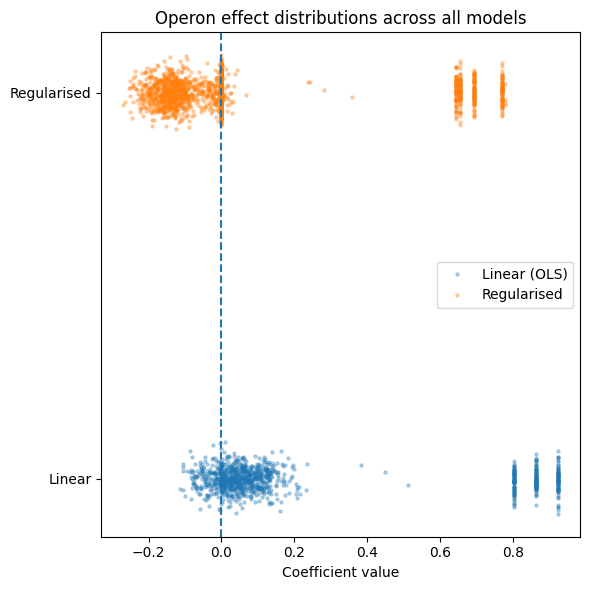

In [29]:
"""figure1: Linear vs Regularized consensus"""

lin_cols = [
    "coef_full",
    "coef_seedA_train",
    "coef_seedB_train"
]

reg_cols = [
    "ridge_full",
    "ridge_A_train",
    "ridge_B_train",
    "enet_full",
    "enet_A_train",
    "enet_B_train"
]

# -----------------------------
# Stack into long format (no merging needed)
# -----------------------------
lin_vals = df_lin[lin_cols].values.flatten()
reg_vals = df_reg[reg_cols].values.flatten()

# Remove NaNs just in case
lin_vals = lin_vals[~np.isnan(lin_vals)]
reg_vals = reg_vals[~np.isnan(reg_vals)]

# -----------------------------
# Plot (2-group comparison)
# -----------------------------
plt.figure(figsize=(6,6))

y_lin = np.random.normal(0, 0.03, len(lin_vals))
y_reg = np.random.normal(1, 0.03, len(reg_vals))

plt.scatter(lin_vals, y_lin, s=5, alpha=0.3, color="tab:blue", label="Linear (OLS)")
plt.scatter(reg_vals, y_reg, s=5, alpha=0.3, color="tab:orange", label="Regularised")

plt.axvline(0, linestyle="--")

plt.yticks([0, 1], ["Linear", "Regularised"])
plt.xlabel("Coefficient value")
plt.title("Operon effect distributions across all models")

plt.legend()
plt.tight_layout()
plt.savefig(SURROGATE_DIR + "/operon_effects_comparison_lin_vs_reg.png")
plt.show()

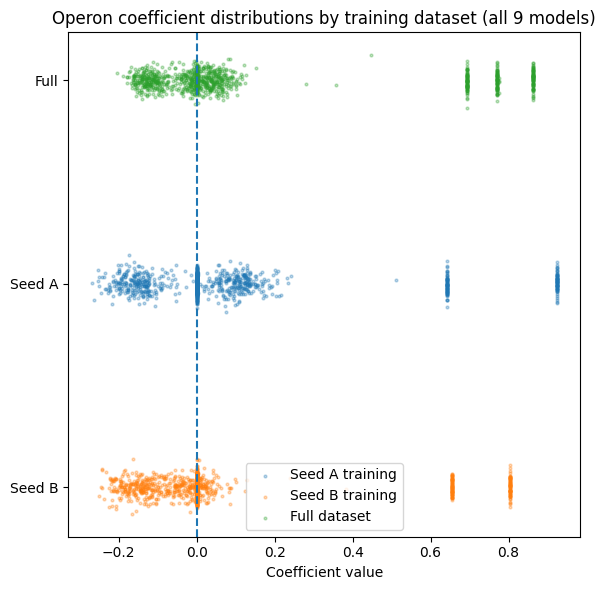

In [28]:
"""figure1.2: Comparison of training origins (seed A vs seed B vs full) across all models"""
# -----------------------------
# Build (coef, group) pairs
# group = training origin
# -----------------------------

data_A = []
data_B = []
data_full = []

# Linear models
data_full += list(df_lin["coef_full"].dropna().values)
data_A    += list(df_lin["coef_seedA_train"].dropna().values)
data_B    += list(df_lin["coef_seedB_train"].dropna().values)

# Regularised models
data_full += list(df_reg["ridge_full"].dropna().values)
data_full += list(df_reg["enet_full"].dropna().values)

data_A += list(df_reg["ridge_A_train"].dropna().values)
data_A += list(df_reg["enet_A_train"].dropna().values)

data_B += list(df_reg["ridge_B_train"].dropna().values)
data_B += list(df_reg["enet_B_train"].dropna().values)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,6))

y_full = np.random.normal(2, 0.04, len(data_full))
y_A    = np.random.normal(1, 0.04, len(data_A))
y_B    = np.random.normal(0, 0.04, len(data_B))

plt.scatter(data_A, y_A, s=4, alpha=0.3, color="tab:blue", label="Seed A training")
plt.scatter(data_B, y_B, s=4, alpha=0.3, color="tab:orange", label="Seed B training")
plt.scatter(data_full, y_full, s=4, alpha=0.3, color="tab:green", label="Full dataset")

plt.axvline(0, linestyle="--")

plt.yticks([0,1,2], ["Seed B", "Seed A", "Full"])
plt.xlabel("Coefficient value")
plt.title("Operon coefficient distributions by training dataset (all 9 models)")

plt.legend()
plt.tight_layout()
plt.savefig(SURROGATE_DIR + "/operon_effects_comparison_by_training_data.png")
plt.show()

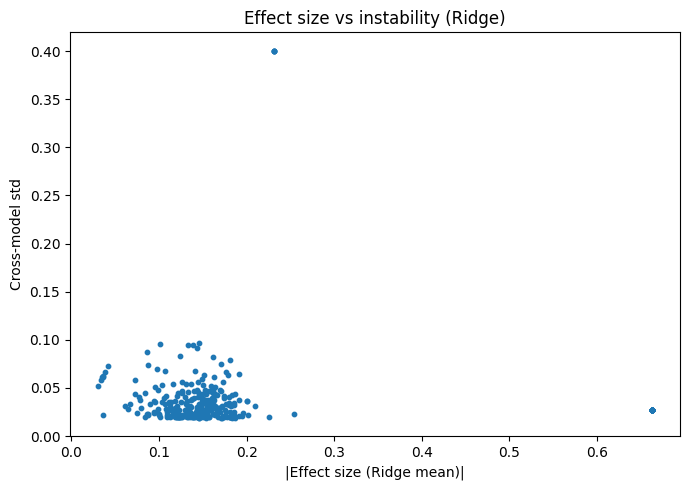

In [13]:
"""figure2:Stability vs effect size"""

plt.figure(figsize=(7,5))

plt.scatter(
    np.abs(df["ridge_mean"]),
    df["ridge_std"],
    s=10
)

plt.xlabel("|Effect size (Ridge mean)|")
plt.ylabel("Cross-model std")
plt.title("Effect size vs instability (Ridge)")

plt.tight_layout()
plt.show()

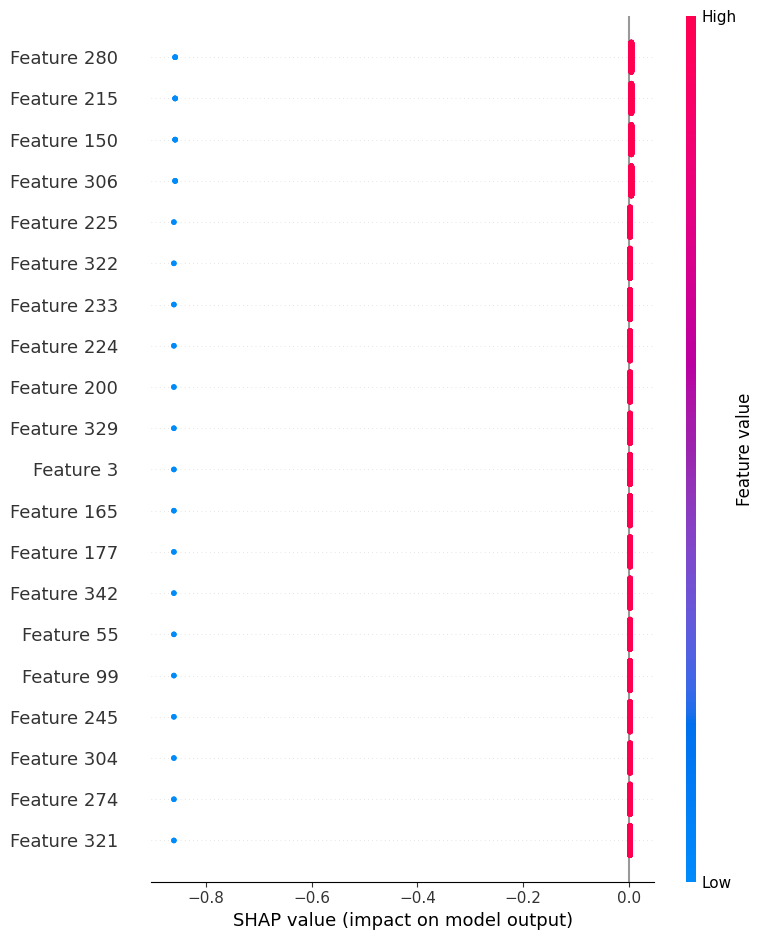

In [30]:
"""figure3: Top operon ranking (most accurate model)"""
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# =========================
# 1. Load feature list
# =========================
feature_list_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_feature_list.csv"
feature_df = pd.read_csv(feature_list_path)

features = feature_df["feature_name"].tolist()

# =========================
# 2. Load model
# =========================
model_path = "/user/home/il22158/work/vEcoli/surrogate/linear_full.pkl"
model = joblib.load(model_path)

# =========================
# 3. Reconstruct X correctly
# IMPORTANT: you must load your REAL dataset here
# =========================
# X is loaded in previous step

# =========================
# 4. SHAP (modern API, no warnings)
# =========================
masker = shap.maskers.Independent(
    X,
    max_samples=X.shape[0]   # = 350
)

explainer = shap.LinearExplainer(
    model,
    masker
)

shap_values = explainer(X)

# =========================
# 5. Plot (beeswarm, not bar plot)
# =========================
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X, show=True)

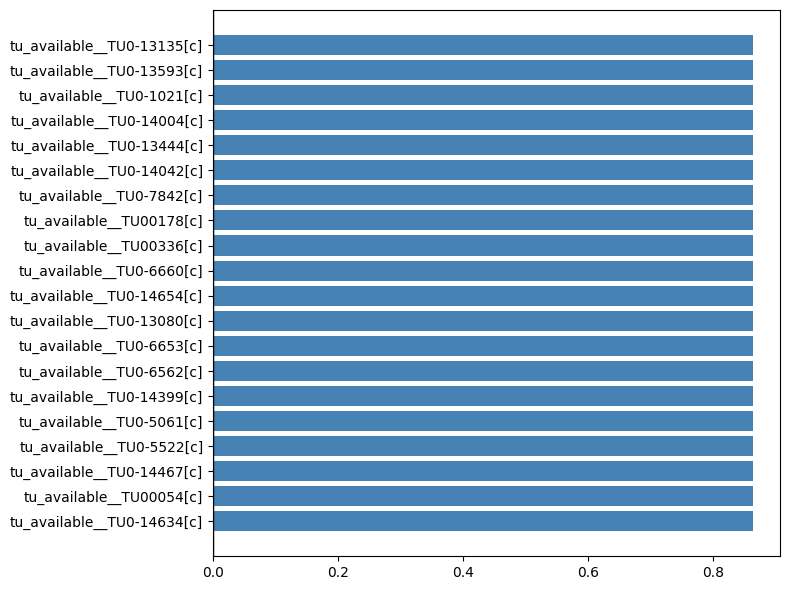

In [32]:
"""figure 3.2 a simple bar plot of top coefficients from the best model (for direct comparison with SHAP)"""
# =========================
# load coefficients
# =========================
path = "/user/home/il22158/work/vEcoli/surrogate/TU_coefficients_3_linear_models.csv"
df = pd.read_csv(path)

# ensure numeric
df["coef_full"] = pd.to_numeric(df["coef_full"], errors="coerce")
df = df.dropna(subset=["coef_full"])

# =========================
# select top coefficients
# =========================
top_n = 20

df_top = df.copy()
df_top["abs_coef"] = df_top["coef_full"].abs()

df_top = df_top.sort_values("abs_coef", ascending=False).head(top_n)

# sort for plotting (nice visual order)
df_top = df_top.sort_values("coef_full")

# =========================
# plot
# =========================
plt.figure(figsize=(8, 6))

colors = df_top["coef_full"].apply(lambda x: "red" if x < 0 else "steelblue")

plt.barh(df_top["tu"], df_top["coef_full"], color=colors)

plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()


Cluster sizes:
group
0    118
1     80
2    151
3      1
Name: count, dtype: int64


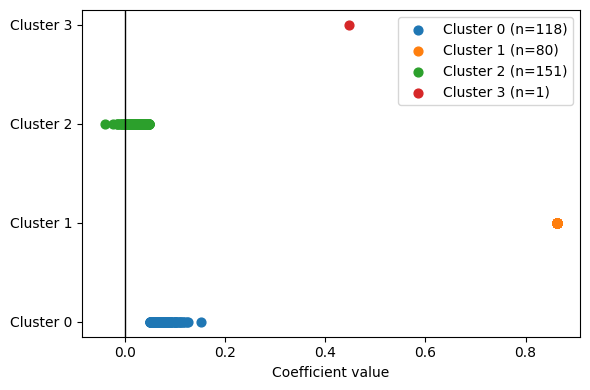

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# =========================
# load data
# =========================
path = "/user/home/il22158/work/vEcoli/surrogate/TU_coefficients_3_linear_models.csv"
df = pd.read_csv(path)

df["coef_full"] = pd.to_numeric(df["coef_full"], errors="coerce")
df = df.dropna(subset=["coef_full"])

# =========================
# clustering
# =========================
X = df[["coef_full"]].values

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
df["group"] = kmeans.fit_predict(X)

# =========================
# cluster sizes
# =========================
cluster_counts = df["group"].value_counts().sort_index()

print("\nCluster sizes:")
print(cluster_counts)

# =========================
# plot
# =========================
plt.figure(figsize=(6, 4))

for g in sorted(df["group"].unique()):
    subset = df[df["group"] == g]

    plt.scatter(
        subset["coef_full"],
        np.full(len(subset), g),
        s=40,
        label=f"Cluster {g} (n={len(subset)})"
    )

plt.axvline(0, color="black", linewidth=1)

plt.yticks(range(n_clusters), [f"Cluster {i}" for i in range(n_clusters)])
plt.xlabel("Coefficient value")

plt.legend()
plt.tight_layout()
plt.savefig("/user/home/il22158/work/vEcoli/surrogate/TU_coefficients_linear_full_clustered.png")
plt.show()

### Accuracy plots

In [5]:
import numpy as np
import pandas as pd
import joblib

# Out directory
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"]).copy()

tu_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[tu_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"Using {len(tu_cols)} features | X: {X.shape} | y: {y.shape}")

# -----------------------------
# Seed ordering (IMPORTANT)
# -----------------------------
# We assume each TU appears twice (two seeds) in a consistent order in df
# We construct a simple alternating index split:
# first occurrence -> seed A
# second occurrence -> seed B

df = df.reset_index(drop=True)

seed_mask_A = np.zeros(len(df), dtype=bool)
seed_mask_B = np.zeros(len(df), dtype=bool)

# group by TU and assign first/second occurrence
for _, idx in df.groupby("ko_tu_id").groups.items():
    idx = list(idx)
    if len(idx) != 2:
        continue  # safety check for unexpected duplicates
    seed_mask_A[idx[0]] = True
    seed_mask_B[idx[1]] = True

X_A, y_A = X[seed_mask_A], y[seed_mask_A]
X_B, y_B = X[seed_mask_B], y[seed_mask_B]

Using 350 features | X: (724, 350) | y: (724,)


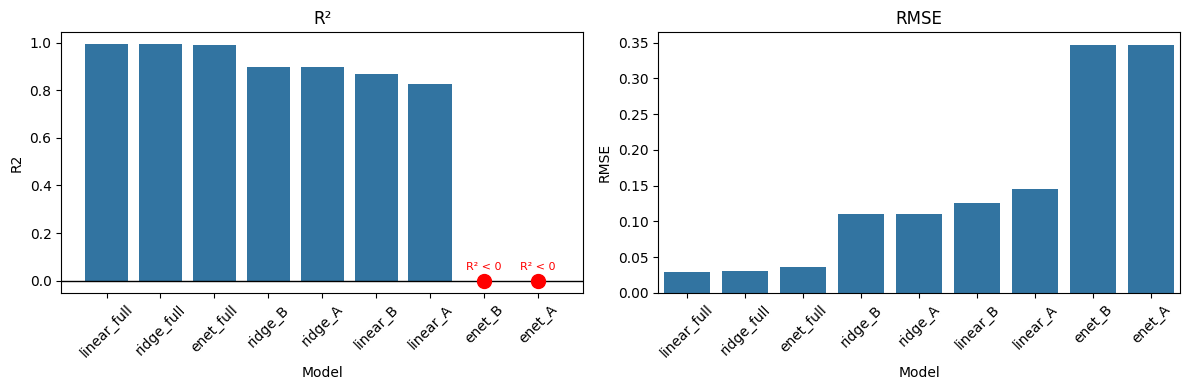

In [15]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, root_mean_squared_error

model_paths = {
    "enet_A": "/user/home/il22158/work/vEcoli/surrogate/enet_A.pkl",
    "enet_B": "/user/home/il22158/work/vEcoli/surrogate/enet_B.pkl",
    "enet_full": "/user/home/il22158/work/vEcoli/surrogate/enet_full.pkl",
    "linear_A": "/user/home/il22158/work/vEcoli/surrogate/linear_seedA.pkl",
    "linear_B": "/user/home/il22158/work/vEcoli/surrogate/linear_seedB.pkl",
    "linear_full": "/user/home/il22158/work/vEcoli/surrogate/linear_full.pkl",
    "ridge_A": "/user/home/il22158/work/vEcoli/surrogate/ridge_A.pkl",
    "ridge_B": "/user/home/il22158/work/vEcoli/surrogate/ridge_B.pkl",
    "ridge_full": "/user/home/il22158/work/vEcoli/surrogate/ridge_full.pkl",
}

results = []

for name, path in model_paths.items():
    model = joblib.load(path)
    y_pred = model.predict(X)

    results.append({
        "Model": name,
        "R2": r2_score(y, y_pred),
        "RMSE": root_mean_squared_error(y, y_pred)
    })

df = pd.DataFrame(results).sort_values("R2", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# =========================
# R2 BARPLOT
# =========================
sns.barplot(data=df, x="Model", y="R2", ax=axes[0], errorbar=None)

axes[0].set_title("R²")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(0, color="black", linewidth=1)

# 🔥 map model name → x position
x_positions = {label.get_text(): i for i, label in enumerate(axes[0].get_xticklabels())}

# 🔴 correct placement of negative markers
for _, row in df.iterrows():
    if row["R2"] < 0:
        x = x_positions[row["Model"]]

        axes[0].scatter(
            x,
            row["R2"],
            color="red",
            s=100,
            zorder=5
        )

        axes[0].annotate(
            "R² < 0",
            (x, row["R2"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            color="red",
            fontsize=8
        )

# =========================
# RMSE PLOT
# =========================
sns.barplot(data=df, x="Model", y="RMSE", ax=axes[1], errorbar=None)
axes[1].set_title("RMSE")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(SURROGATE_DIR + "/9_base_model_performance_comparison.png")
plt.show()

In [7]:
print("\nModel performance:")
print(df.sort_values("R2", ascending=False).to_string(index=False))


Model performance:
      Model        R2     RMSE
linear_full  0.993050 0.028940
 ridge_full  0.992379 0.030303
  enet_full  0.989053 0.036320
    ridge_B  0.898488 0.110599
    ridge_A  0.898438 0.110627
   linear_B  0.868135 0.126054
   linear_A  0.825676 0.144935
     enet_B -0.000291 0.347181
     enet_A -0.000634 0.347241


### 5 CV training and testing

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import joblib

# Out directory
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"])

tu_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[tu_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"Using {len(tu_cols)} features | X: {X.shape} | y: {y.shape}")

# -----------------------------
# Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# Holdout evaluation
# -----------------------------
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.6f} | R2: {r2:.4f}")

# -----------------------------
# 5-fold CV (RMSE)
# -----------------------------
cv_rmse = np.sqrt(
    -cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
)

print(f"CV RMSE: {cv_rmse.mean():.6f} ± {cv_rmse.std():.6f}")

# -----------------------------
# Top coefficients
# -----------------------------
coef = pd.Series(model.coef_, index=tu_cols)

print("\nTop 10 TU coefficients:")
print(coef.abs().sort_values(ascending=False).head(10))

# -----------------------------
# Save model
# -----------------------------
joblib.dump(model, SURROGATE_DIR + "/" + "baseline_linear_TU_model.pkl")
print("Model saved.")

Using 350 features | X: (796, 350) | y: (796,)
RMSE: 0.217293 | R2: 0.6802
CV RMSE: 0.181913 ± 0.246839

Top 10 TU coefficients:
tu_available__TU0-8492[c]     0.845027
tu_available__TU0-6512[c]     0.845027
tu_available__TU0-14399[c]    0.845027
tu_available__TU00351[c]      0.845027
tu_available__TU0-1[c]        0.845027
tu_available__TU00205[c]      0.845027
tu_available__TU0-13444[c]    0.845027
tu_available__TU00061[c]      0.845027
tu_available__TU0-6660[c]     0.845027
tu_available__TU0-14042[c]    0.845027
dtype: float64
Model saved.


In [39]:
import numpy as np
import pandas as pd
import joblib

from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# Out directory
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"]).copy()

gene_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[gene_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"X: {X.shape}, y: {y.shape}")

# -----------------------------
# Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

alphas_ridge = np.logspace(-4, 4, 25)

# -----------------------------
# Ridge
# -----------------------------
ridge = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alphas_ridge, cv=5, scoring="neg_mean_squared_error")
)

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"Ridge -> RMSE: {ridge_rmse:.6f} | R2: {ridge_r2:.4f}")

ridge_cv = np.sqrt(
    -cross_val_score(ridge, X, y, cv=5, scoring="neg_mean_squared_error")
)
print(f"Ridge CV RMSE: {ridge_cv.mean():.6f} ± {ridge_cv.std():.6f}")

# -----------------------------
# ElasticNet
# -----------------------------
enet = make_pipeline(
    StandardScaler(),
    ElasticNetCV(
        alphas=np.logspace(-4, 1, 30),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        max_iter=5000
    )
)

enet.fit(X_train, y_train)
enet_pred = enet.predict(X_test)

enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))
enet_r2 = r2_score(y_test, enet_pred)

print(f"ElasticNet -> RMSE: {enet_rmse:.6f} | R2: {enet_r2:.4f}")

enet_cv = np.sqrt(
    -cross_val_score(enet, X, y, cv=5, scoring="neg_mean_squared_error")
)
print(f"ElasticNet CV RMSE: {enet_cv.mean():.6f} ± {enet_cv.std():.6f}")

# -----------------------------
# Coefficients (corrected backscale)
# -----------------------------
def get_coefs(pipe):
    scaler = pipe.named_steps["standardscaler"]
    model = pipe.named_steps[list(pipe.named_steps.keys())[-1]]
    return pd.Series(model.coef_ / scaler.scale_, index=gene_cols)

ridge_top = get_coefs(ridge).abs().sort_values(ascending=False).head(10)
enet_top = get_coefs(enet).abs().sort_values(ascending=False).head(10)

print("\nTop Ridge coefficients:")
print(ridge_top)

print("\nTop ElasticNet coefficients:")
print(enet_top)

# -----------------------------
# Save
# -----------------------------
joblib.dump(ridge, SURROGATE_DIR + "/" +  "ridge_TU_model.pkl")
joblib.dump(enet, SURROGATE_DIR + "/" + "elasticnet_TU_model.pkl")

print("Models saved.")

X: (796, 350), y: (796,)
Ridge -> RMSE: 0.182340 | R2: 0.7748
Ridge CV RMSE: 0.163303 ± 0.205177
ElasticNet -> RMSE: 0.204706 | R2: 0.7162
ElasticNet CV RMSE: 0.165384 ± 0.225065

Top Ridge coefficients:
tu_available__TU00337[c]     0.678660
tu_available__TU00347[c]     0.678643
tu_available__TU00346[c]     0.678462
tu_available__TU0-1[c]       0.678429
tu_available__TU00067[c]     0.678429
tu_available__TU0-6512[c]    0.678429
tu_available__TU00351[c]     0.678429
tu_available__TU00348[c]     0.678412
tu_available__TU0-5522[c]    0.678412
tu_available__TU00205[c]     0.678412
dtype: float64

Top ElasticNet coefficients:
tu_available__TU00337[c]     0.783039
tu_available__TU00347[c]     0.782825
tu_available__TU00346[c]     0.777796
tu_available__TU00351[c]     0.775078
tu_available__TU00067[c]     0.775070
tu_available__TU0-6512[c]    0.775062
tu_available__TU0-1[c]       0.775054
tu_available__TU00348[c]     0.772796
tu_available__TU00205[c]     0.772791
tu_available__TU0-5522[c]    

        Model       MSE      RMSE        R2
0      Linear  0.047216  0.217293  0.680230
1       Ridge  0.033248  0.182340  0.774831
2  ElasticNet  0.041904  0.204706  0.716204


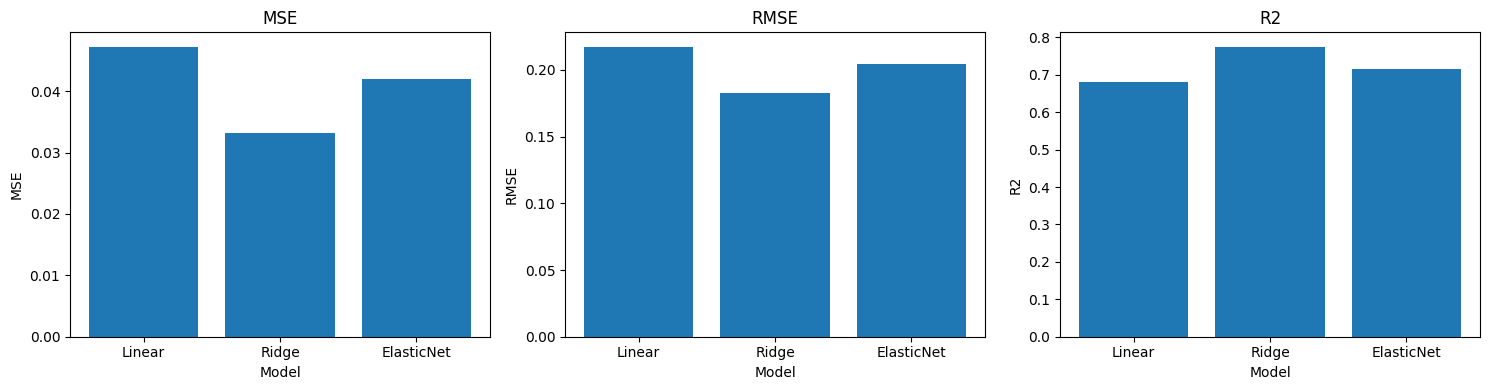

In [40]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# Load models
# -----------------------------
paths = {
    "Linear": "/user/home/il22158/work/vEcoli/surrogate/baseline_linear_TU_model.pkl",
    "Ridge": "/user/home/il22158/work/vEcoli/surrogate/ridge_TU_model.pkl",
    "ElasticNet": "/user/home/il22158/work/vEcoli/surrogate/elasticnet_TU_model.pkl"
}

models = {name: joblib.load(path) for name, path in paths.items()}

# -----------------------------
# Evaluate
# -----------------------------
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, rmse, r2])

df_results = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2"])
print(df_results)

# -----------------------------
# BAR PLOT (NEW)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ["MSE", "RMSE", "R2"]

for i, metric in enumerate(metrics):
    axes[i].bar(df_results["Model"], df_results[metric])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel("Model")

plt.tight_layout()
plt.show()

# Function validation - default KO

In [3]:
"""Task 1/3: shared KO trace reader for both projects, plus a compact comparison table."""
from __future__ import annotations

from pathlib import Path
import json
import pickle

import numpy as np
import pandas as pd

BASE = Path("/user/home/il22158/work/vEcoli")
PROJECTS = {
    "gene_knockout_leftover": BASE / "out" / "gene_knockout_leftover",
    "gene_knockout_TU_ID_test": BASE / "out" / "gene_knockout_TU_ID_test",
}
TARGET_GENES = ["EG10016", "G6941", "G6943"]
PREFERRED_LINEAGE_SEED = 100
KO_VALIDATION_DIR = BASE / "surrogate" / "KO_validation"
KO_VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
RESULT_TABLE_PATH = KO_VALIDATION_DIR / "ko_validation_result_table.csv"
COMPARISON_TABLE_PATH = KO_VALIDATION_DIR / "ko_validation_comparison_table.csv"


def as_list(value: object) -> list[str]:
    if isinstance(value, np.ndarray):
        return [str(item).strip() for item in value.tolist() if str(item).strip()]
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]
    if pd.isna(value):
        return []
    return [item.strip() for item in str(value).split(",") if item.strip()]


def strip_compartment(label: str) -> str:
    text = str(label).strip()
    return text.rsplit("[", 1)[0] if text.endswith("]") and "[" in text else text


def load_metadata(project_root: Path) -> dict:
    with (project_root / "variant_sim_data" / "metadata.json").open() as handle:
        return json.load(handle)


def find_variant_by_gene_id(metadata: dict, gene_id: str) -> int:
    variant_map = metadata.get("gene_knockout", {})
    for key, info in sorted(variant_map.items(), key=lambda item: int(item[0])):
        genes = as_list(info.get("genes_to_knockout", [])) if isinstance(info, dict) else as_list(info)
        if gene_id in genes:
            return int(key)
    raise RuntimeError(f"Gene ID {gene_id} not found in metadata")


def find_variant_by_ids(metadata: dict, target_ids: set[str]) -> int:
    target_exact = {item.strip() for item in target_ids if str(item).strip()}
    target_base = {strip_compartment(item) for item in target_exact}

    variant_map = metadata.get("gene_knockout", {})
    for key, info in sorted(variant_map.items(), key=lambda item: int(item[0])):
        ids = set(as_list(info.get("genes_to_knockout", [])) if isinstance(info, dict) else as_list(info))
        if ids.intersection(target_exact) or {strip_compartment(item) for item in ids}.intersection(target_base):
            return int(key)
    raise RuntimeError(f"No matching variant found for IDs: {sorted(target_exact)}")


def get_gene_mapping_from_sim_data(project_root: Path, variant: int, gene_id: str) -> dict[str, object]:
    with (project_root / "variant_sim_data" / f"{variant}.cPickle").open("rb") as handle:
        sim_data = pickle.load(handle)

    cistron_data = sim_data.process.transcription.cistron_data
    mask = cistron_data["gene_id"] == gene_id
    if not mask.any():
        raise RuntimeError(f"Gene {gene_id} not found in cistron_data for variant {variant}")

    cistron_id = cistron_data["id"][mask][0]
    rna_idx = np.atleast_1d(sim_data.process.transcription.cistron_id_to_rna_indexes(cistron_id)).astype(int)
    rna_data = sim_data.process.transcription.rna_data
    rna_ids = [str(rna_data["id"][idx]).strip() for idx in rna_idx]

    monomer_data = sim_data.process.translation.monomer_data
    monomer_mask = monomer_data["cistron_id"] == cistron_id
    monomer_id = str(monomer_data["id"][monomer_mask][0]).strip() if monomer_mask.any() else None

    return {
        "gene_id": gene_id,
        "cistron_id": cistron_id,
        "rna_ids": rna_ids,
        "tu_id": rna_ids[0],
        "monomer_id": monomer_id,
    }


def available_lineage_seeds(project_root: Path, variant: int) -> list[int]:
    project_name = project_root.name
    variant_root = project_root / "history" / f"experiment_id={project_name}" / f"variant={variant}"
    if not variant_root.exists():
        return []
    seeds = []
    for seed_dir in variant_root.glob("lineage_seed=*"):
        try:
            seeds.append(int(seed_dir.name.split("=", 1)[1]))
        except Exception:
            continue
    return sorted(set(seeds))


def choose_lineage_seed(left_root: Path, left_variant: int, right_root: Path, right_variant: int) -> int | None:
    common = sorted(set(available_lineage_seeds(left_root, left_variant)).intersection(available_lineage_seeds(right_root, right_variant)))
    if not common:
        return None
    return PREFERRED_LINEAGE_SEED if PREFERRED_LINEAGE_SEED in common else common[0]


def list_generations(project_root: Path, variant: int, lineage_seed: int) -> list[int]:
    project_name = project_root.name
    seed_root = project_root / "history" / f"experiment_id={project_name}" / f"variant={variant}" / f"lineage_seed={lineage_seed}"
    if not seed_root.exists():
        return []
    generations = []
    for gen_dir in seed_root.glob("generation=*"):
        try:
            generations.append(int(gen_dir.name.split("=", 1)[1]))
        except Exception:
            continue
    return sorted(set(generations))


def resolve_agent_dirs(project_root: Path, variant: int, lineage_seed: int, generation: int) -> tuple[Path, Path]:
    project_name = project_root.name
    history_gen = project_root / "history" / f"experiment_id={project_name}" / f"variant={variant}" / f"lineage_seed={lineage_seed}" / f"generation={generation}"
    config_gen = project_root / "configuration" / f"experiment_id={project_name}" / f"variant={variant}" / f"lineage_seed={lineage_seed}" / f"generation={generation}"

    if not history_gen.exists():
        raise FileNotFoundError(f"Missing history generation dir: {history_gen}")
    if not config_gen.exists():
        raise FileNotFoundError(f"Missing configuration generation dir: {config_gen}")

    history_agents = sorted(history_gen.glob("agent_id=*"))
    if not history_agents:
        raise FileNotFoundError(f"No history agent directories in: {history_gen}")

    preferred_name = f"agent_id={'0' * generation}"
    ordered_agents = sorted(history_agents, key=lambda path: (path.name != preferred_name, path.name))
    for history_agent in ordered_agents:
        if not any(history_agent.glob("*.pq")):
            continue
        config_agent = config_gen / history_agent.name
        if config_agent.exists() and (config_agent / "config.pq").exists():
            return history_agent, config_agent

    fallback_history = next((path for path in ordered_agents if any(path.glob("*.pq"))), None)
    fallback_config = next((path for path in sorted(config_gen.glob("agent_id=*")) if (path / "config.pq").exists()), None)
    if fallback_history is None:
        raise FileNotFoundError(f"No history parquet files under: {history_gen}")
    if fallback_config is None:
        raise FileNotFoundError(f"No config.pq found under: {config_gen}")
    return fallback_history, fallback_config


def read_trace(project_key: str, variant: int, lineage_seed: int, generation: int, gene_map: dict[str, object]) -> dict[str, object]:
    project_root = PROJECTS[project_key]
    history_agent, config_agent = resolve_agent_dirs(project_root, variant, lineage_seed, generation)

    config_df = pd.read_parquet(config_agent / "config.pq")
    bulk_ids = as_list(config_df.get("output_metadata__bulk", pd.Series([[]])).iloc[0])
    mrna_ids = as_list(config_df.get("output_metadata__listeners__rna_counts__mRNA_counts", pd.Series([[]])).iloc[0])

    tu_id = str(gene_map["tu_id"])
    monomer_id = gene_map["monomer_id"]
    tu_idx = mrna_ids.index(tu_id) if tu_id in mrna_ids else None
    monomer_idx = bulk_ids.index(monomer_id) if monomer_id is not None and monomer_id in bulk_ids else None

    history_files = sorted(history_agent.glob("*.pq"))
    if not history_files:
        raise FileNotFoundError(f"No history parquet files in: {history_agent}")

    hist = pd.concat([pd.read_parquet(path) for path in history_files], ignore_index=True).sort_values("time").reset_index(drop=True)
    time = pd.to_numeric(hist["time"], errors="coerce").to_numpy(dtype=float)
    mRNA = hist["listeners__rna_counts__mRNA_counts"].apply(lambda values: values[tu_idx] if tu_idx is not None and len(values) > tu_idx else 0).to_numpy(dtype=np.int32)
    protein = hist["bulk"].apply(lambda values: values[monomer_idx] if monomer_idx is not None and len(values) > monomer_idx else 0).to_numpy(dtype=np.int32)

    metric_candidates = {
        "total_mass": ["listeners__mass__cell_mass", "listeners__mass__dry_mass"],
        "growth_rate": ["listeners__mass__instantaneous_growth_rate", "listeners__growth_limits__instantaneous_growth_rate", "listeners__mass__growth"],
        "rna_mass": ["listeners__mass__rna_mass"],
        "protein_mass": ["listeners__mass__protein_mass"],
        "ppgpp": ["listeners__growth_limits__ppgpp_conc", "listeners__growth_limits__ppgpp", "listeners__growth_limits__ppGpp"],
    }
    metrics: dict[str, np.ndarray] = {}
    for name, candidates in metric_candidates.items():
        column = next((candidate for candidate in candidates if candidate in hist.columns), None)
        metrics[name] = np.full(len(hist), np.nan, dtype=float) if column is None else pd.to_numeric(hist[column], errors="coerce").to_numpy(dtype=float)

    return {
        "project_name": project_key,
        "variant": variant,
        "lineage_seed": lineage_seed,
        "generation": generation,
        "gene_id": gene_map["gene_id"],
        "tu_id": tu_id,
        "monomer_id": monomer_id,
        "time": time,
        "mRNA": mRNA,
        "protein": protein,
        "metrics": metrics,
    }


left_meta = load_metadata(PROJECTS["gene_knockout_leftover"])
right_meta = load_metadata(PROJECTS["gene_knockout_TU_ID_test"])
comparison_rows = []
result_rows = []
trace_cache = {}

for gene_id in TARGET_GENES:
    left_variant = find_variant_by_gene_id(left_meta, gene_id)
    gene_map = get_gene_mapping_from_sim_data(PROJECTS["gene_knockout_leftover"], left_variant, gene_id)
    right_variant = find_variant_by_ids(right_meta, set(gene_map["rna_ids"]) | {gene_map["tu_id"]})

    lineage_seed = choose_lineage_seed(PROJECTS["gene_knockout_leftover"], left_variant, PROJECTS["gene_knockout_TU_ID_test"], right_variant)
    if lineage_seed is None:
        comparison_rows.append({
            "gene_id": gene_id,
            "left_project_name": "gene_knockout_leftover",
            "right_project_name": "gene_knockout_TU_ID_test",
            "left_variant": left_variant,
            "right_variant": right_variant,
            "lineage_seed": pd.NA,
            "left_generations": [],
            "right_generations": [],
            "generation": pd.NA,
            "time_equal_exact": pd.NA,
            "rna_equal_exact": pd.NA,
            "protein_equal_exact": pd.NA,
            "rna_max_abs_diff": pd.NA,
            "protein_max_abs_diff": pd.NA,
            "note": "No common lineage_seed in history tree",
        })
        continue

    left_generations = list_generations(PROJECTS["gene_knockout_leftover"], left_variant, lineage_seed)
    right_generations = list_generations(PROJECTS["gene_knockout_TU_ID_test"], right_variant, lineage_seed)
    overlap = sorted(set(left_generations).intersection(right_generations))

    if not overlap:
        comparison_rows.append({
            "gene_id": gene_id,
            "left_project_name": "gene_knockout_leftover",
            "right_project_name": "gene_knockout_TU_ID_test",
            "left_variant": left_variant,
            "right_variant": right_variant,
            "lineage_seed": lineage_seed,
            "left_generations": left_generations,
            "right_generations": right_generations,
            "generation": pd.NA,
            "time_equal_exact": pd.NA,
            "rna_equal_exact": pd.NA,
            "protein_equal_exact": pd.NA,
            "rna_max_abs_diff": pd.NA,
            "protein_max_abs_diff": pd.NA,
            "note": "No overlapping generations",
        })
        continue

    for generation in overlap:
        try:
            left_trace = read_trace("gene_knockout_leftover", left_variant, lineage_seed, generation, gene_map)
            right_trace = read_trace("gene_knockout_TU_ID_test", right_variant, lineage_seed, generation, gene_map)
        except FileNotFoundError as exc:
            comparison_rows.append({
                "gene_id": gene_id,
                "left_project_name": "gene_knockout_leftover",
                "right_project_name": "gene_knockout_TU_ID_test",
                "left_variant": left_variant,
                "right_variant": right_variant,
                "lineage_seed": lineage_seed,
                "left_generations": left_generations,
                "right_generations": right_generations,
                "generation": generation,
                "time_equal_exact": pd.NA,
                "rna_equal_exact": pd.NA,
                "protein_equal_exact": pd.NA,
                "rna_max_abs_diff": pd.NA,
                "protein_max_abs_diff": pd.NA,
                "note": f"Skipped: {exc}"[:220],
            })
            continue

        trace_cache[(gene_id, generation)] = {"left": left_trace, "right": right_trace}
        result_rows.extend([
            {
                "project_name": left_trace["project_name"],
                "gene_id": left_trace["gene_id"],
                "variant": left_trace["variant"],
                "lineage_seed": left_trace["lineage_seed"],
                "generation": left_trace["generation"],
                "time_points": len(left_trace["time"]),
                "time_start": float(left_trace["time"][0]),
                "time_end": float(left_trace["time"][-1]),
                "mRNA_mean": float(np.nanmean(left_trace["mRNA"])),
                "protein_mean": float(np.nanmean(left_trace["protein"])),
                "total_mass_mean": float(np.nanmean(left_trace["metrics"]["total_mass"])),
                "growth_rate_mean": float(np.nanmean(left_trace["metrics"]["growth_rate"])),
                "rna_mass_mean": float(np.nanmean(left_trace["metrics"]["rna_mass"])),
                "protein_mass_mean": float(np.nanmean(left_trace["metrics"]["protein_mass"])),
                "ppgpp_mean": float(np.nanmean(left_trace["metrics"]["ppgpp"])),
            },
            {
                "project_name": right_trace["project_name"],
                "gene_id": right_trace["gene_id"],
                "variant": right_trace["variant"],
                "lineage_seed": right_trace["lineage_seed"],
                "generation": right_trace["generation"],
                "time_points": len(right_trace["time"]),
                "time_start": float(right_trace["time"][0]),
                "time_end": float(right_trace["time"][-1]),
                "mRNA_mean": float(np.nanmean(right_trace["mRNA"])),
                "protein_mean": float(np.nanmean(right_trace["protein"])),
                "total_mass_mean": float(np.nanmean(right_trace["metrics"]["total_mass"])),
                "growth_rate_mean": float(np.nanmean(right_trace["metrics"]["growth_rate"])),
                "rna_mass_mean": float(np.nanmean(right_trace["metrics"]["rna_mass"])),
                "protein_mass_mean": float(np.nanmean(right_trace["metrics"]["protein_mass"])),
                "ppgpp_mean": float(np.nanmean(right_trace["metrics"]["ppgpp"])),
            },
        ])

        comparison_rows.append({
            "gene_id": gene_id,
            "left_project_name": left_trace["project_name"],
            "right_project_name": right_trace["project_name"],
            "left_variant": left_variant,
            "right_variant": right_variant,
            "lineage_seed": lineage_seed,
            "left_generations": left_generations,
            "right_generations": right_generations,
            "generation": generation,
            "time_equal_exact": bool(np.array_equal(left_trace["time"], right_trace["time"])),
            "rna_equal_exact": bool(np.array_equal(left_trace["mRNA"], right_trace["mRNA"])),
            "protein_equal_exact": bool(np.array_equal(left_trace["protein"], right_trace["protein"])),
            "rna_max_abs_diff": int(np.max(np.abs(left_trace["mRNA"] - right_trace["mRNA"]))),
            "protein_max_abs_diff": int(np.max(np.abs(left_trace["protein"] - right_trace["protein"]))),
            "note": "Compared on overlapping generation",
        })

result_table = pd.DataFrame(result_rows)
comparison_plan_df = pd.DataFrame(comparison_rows)

result_table.to_csv(RESULT_TABLE_PATH, index=False)
comparison_plan_df.to_csv(COMPARISON_TABLE_PATH, index=False)

print(f"Saved result table to {RESULT_TABLE_PATH}")
print(f"Saved comparison table to {COMPARISON_TABLE_PATH}")
print(f"Result rows: {len(result_table)} | comparison rows: {len(comparison_plan_df)}")
if not result_table.empty:
    print(result_table.head(10).to_string(index=False))
if not comparison_plan_df.empty:
    print(comparison_plan_df.head(10).to_string(index=False))


Saved result table to /user/home/il22158/work/vEcoli/surrogate/KO_validation/ko_validation_result_table.csv
Saved comparison table to /user/home/il22158/work/vEcoli/surrogate/KO_validation/ko_validation_comparison_table.csv
Result rows: 42 | comparison rows: 24
            project_name gene_id  variant  lineage_seed  generation  time_points  time_start  time_end  mRNA_mean  protein_mean  total_mass_mean  growth_rate_mean  rna_mass_mean  protein_mass_mean  ppgpp_mean
  gene_knockout_leftover EG10016        1           100           1          203         0.0    4040.0        0.0           0.0      1576.417788          0.000262      64.628364         216.487052   57.208405
gene_knockout_TU_ID_test EG10016        1           100           1          203         0.0    4040.0        0.0           0.0      1576.417788          0.000262      64.628364         216.487052   57.208405
  gene_knockout_leftover EG10016        1           100           3          135      6605.0    9285.0        0

gene_expression_trace.py check | Gene=EG10016 | lineage_seed=100
left project variant=1, generations=[1, 3, 4, 5, 6, 7, 8]
Tracking: Gene=EG10016 | TU=EG10016_RNA[c] | Monomer=KDGALDOL-MONOMER[c]

V1_G1: Loaded 203 timepoints, mRNA: 0→0, Protein: 0→0
V1_G3: Loaded 135 timepoints, mRNA: 0→0, Protein: 0→0
V1_G4: Loaded 140 timepoints, mRNA: 0→0, Protein: 0→0
V1_G5: Loaded 134 timepoints, mRNA: 0→0, Protein: 0→0
V1_G6: Loaded 142 timepoints, mRNA: 0→0, Protein: 0→0
V1_G7: Loaded 147 timepoints, mRNA: 0→0, Protein: 0→0
V1_G8: Loaded 165 timepoints, mRNA: 0→0, Protein: 0→0
Saved graph to: /user/home/il22158/work/vEcoli/surrogate/KO_validation/gene_knockout_leftover_variant=1_seed=100_gene=EG10016.png


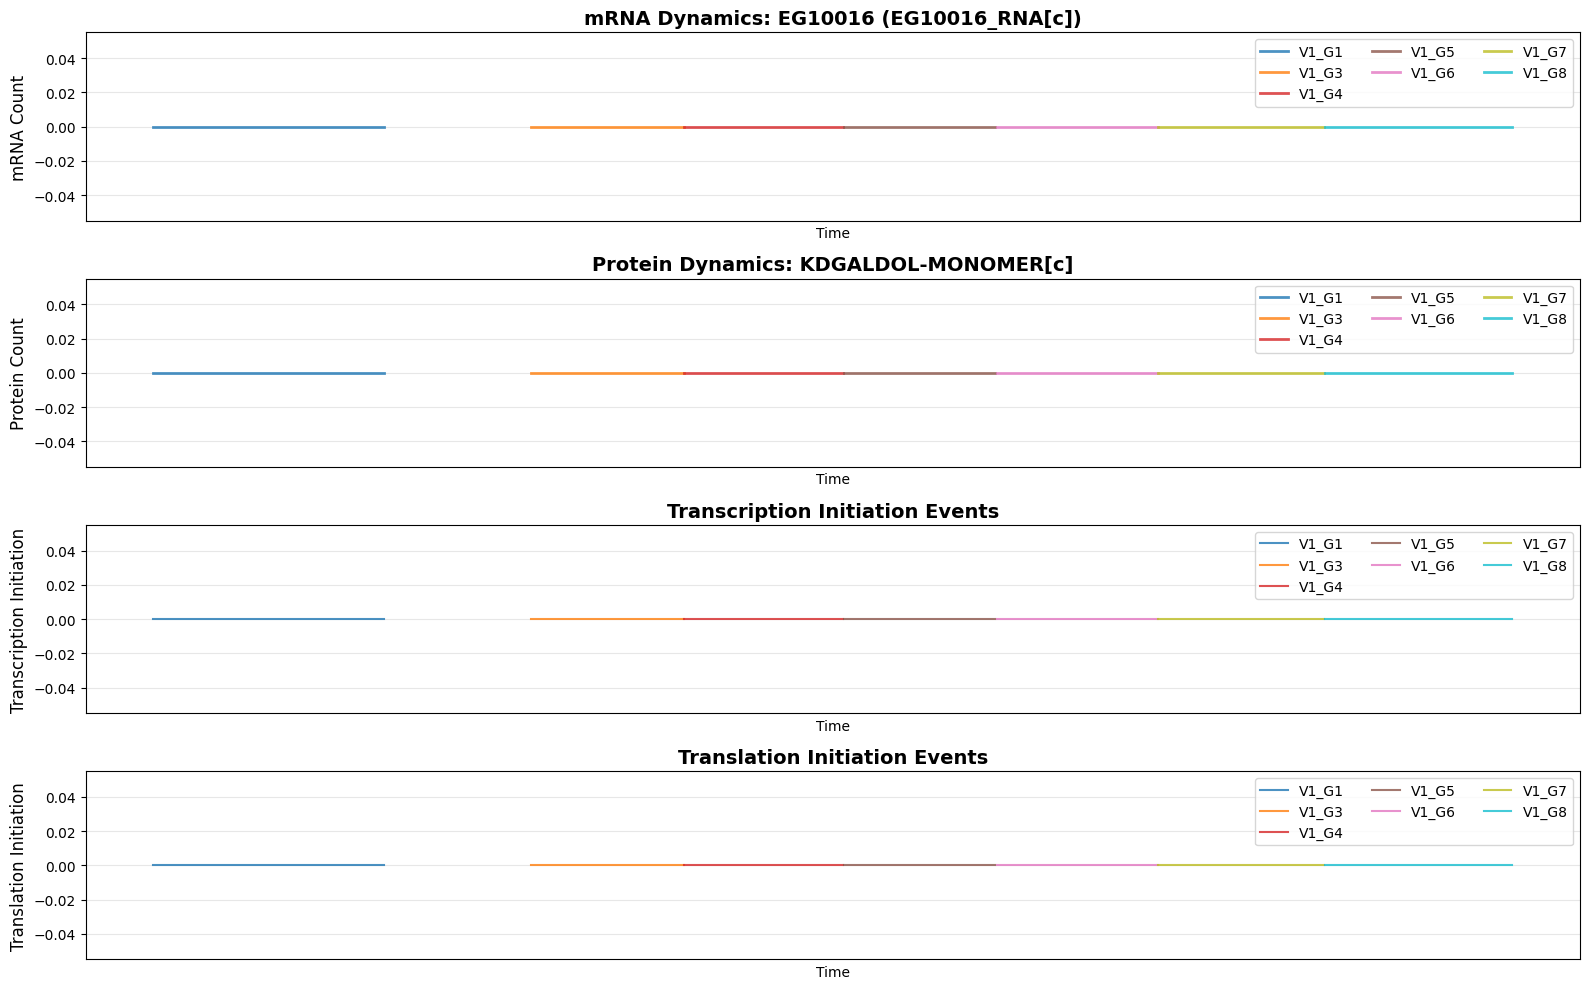


SUMMARY STATISTICS

V1_G1:
  Duration: 4040.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G3:
  Duration: 2680.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G4:
  Duration: 2780.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G5:
  Duration: 2660.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G6:
  Duration: 2820.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G7:
  Duration: 2920.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G8:
  Duration: 3280.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited
right project variant=1, generations=[1, 3, 4, 5, 6, 7, 8]
Tracking: Gene=EG10016 | TU=EG10016_RNA[c] | Monomer=KDGALDOL-MONOMER[c]

V1_G1: Loaded 203 tim

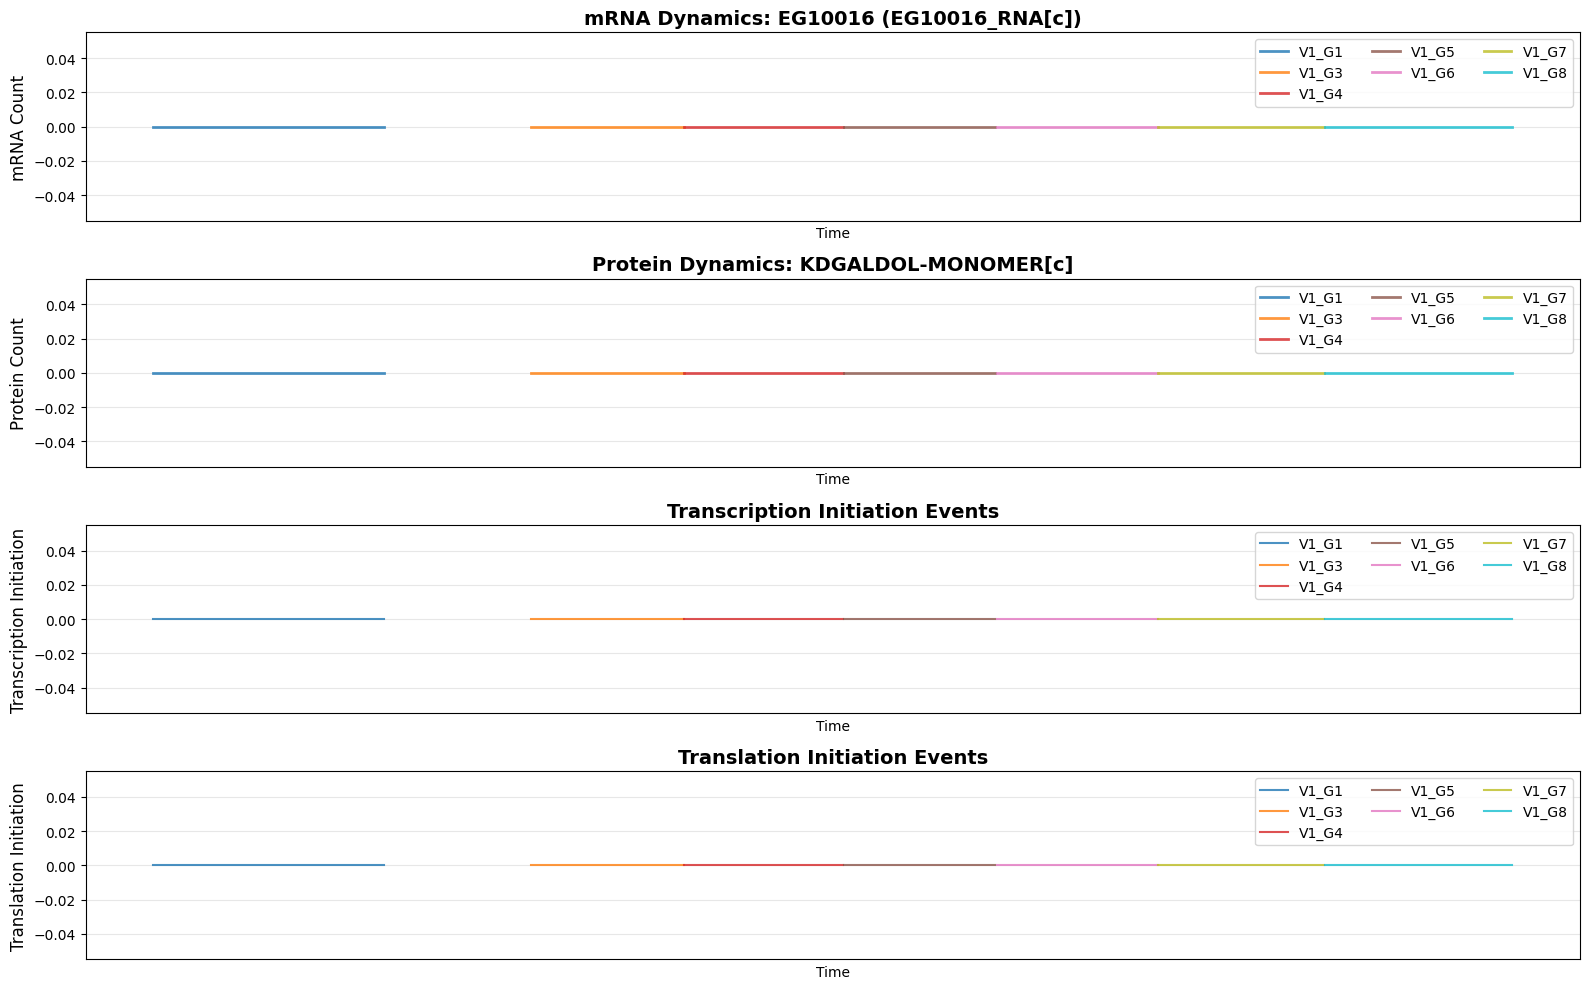


SUMMARY STATISTICS

V1_G1:
  Duration: 4040.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G3:
  Duration: 2680.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G4:
  Duration: 2780.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G5:
  Duration: 2660.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G6:
  Duration: 2820.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G7:
  Duration: 2920.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V1_G8:
  Duration: 3280.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited
gene_expression_trace.py check | Gene=G6941 | lineage_seed=100
left project variant=2, generations=[1, 3, 4, 5, 6, 7, 8]
Tracking: Gene=G6941 | TU=TU0-100

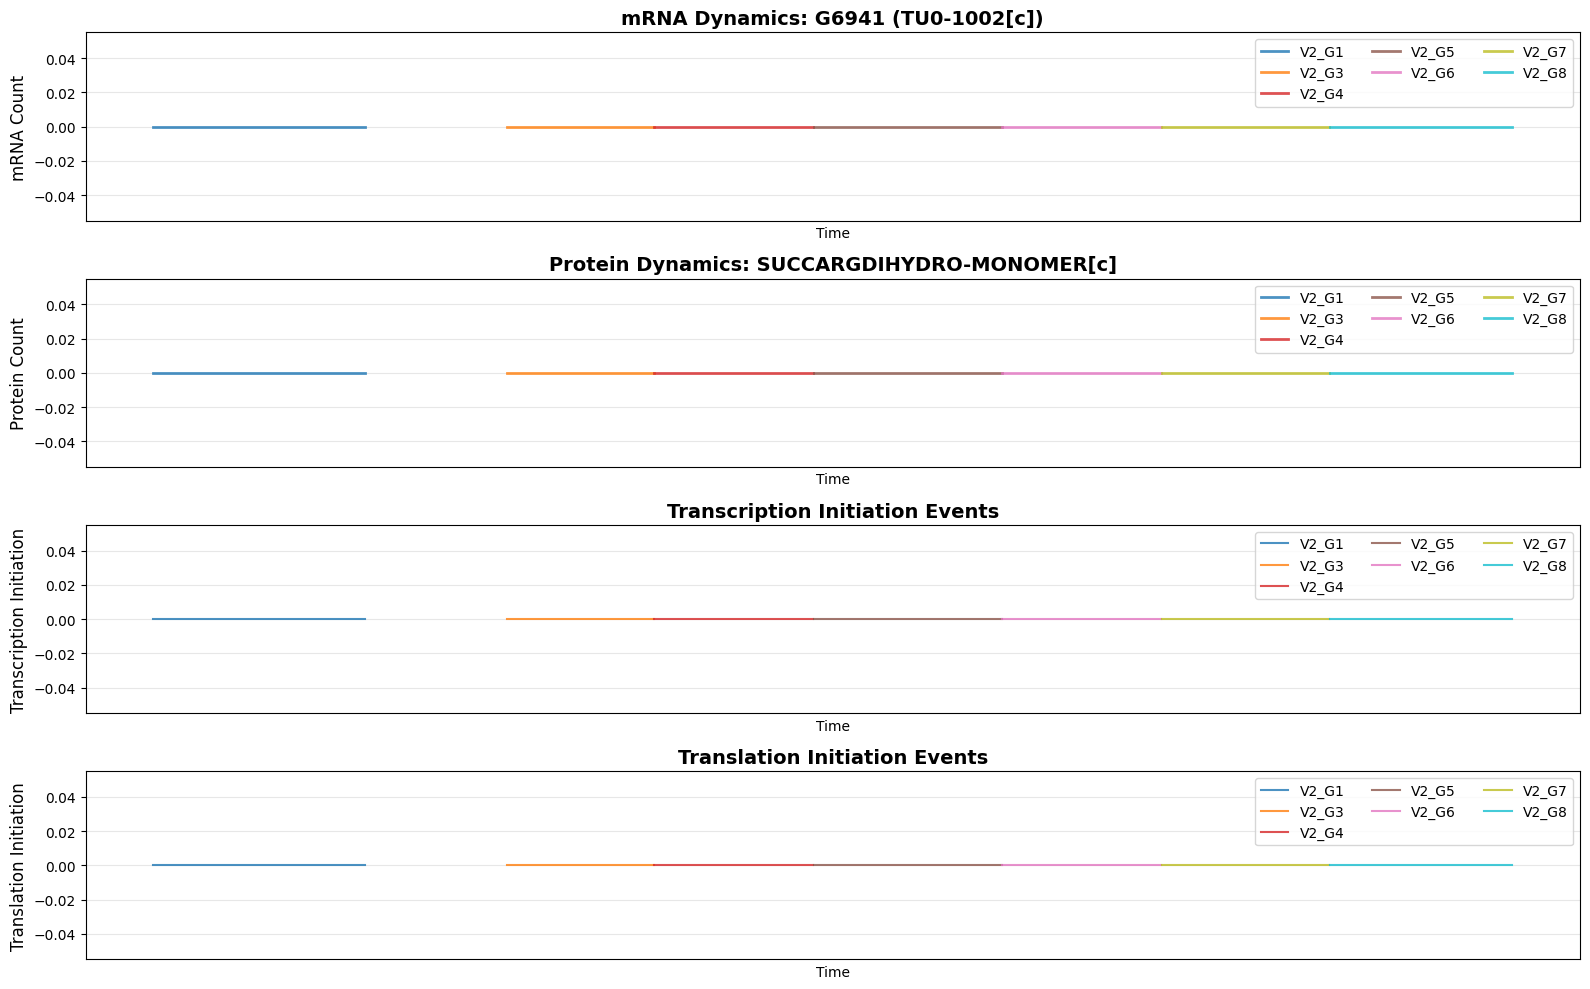


SUMMARY STATISTICS

V2_G1:
  Duration: 4060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G3:
  Duration: 2820.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G4:
  Duration: 3060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G5:
  Duration: 3600.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G6:
  Duration: 3060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G7:
  Duration: 3220.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G8:
  Duration: 3500.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited
right project variant=2, generations=[1, 3, 4, 5, 6, 7, 8]
Tracking: Gene=G6941 | TU=TU0-1002[c] | Monomer=SUCCARGDIHYDRO-MONOMER[c]

V2_G1: Loaded 204 ti

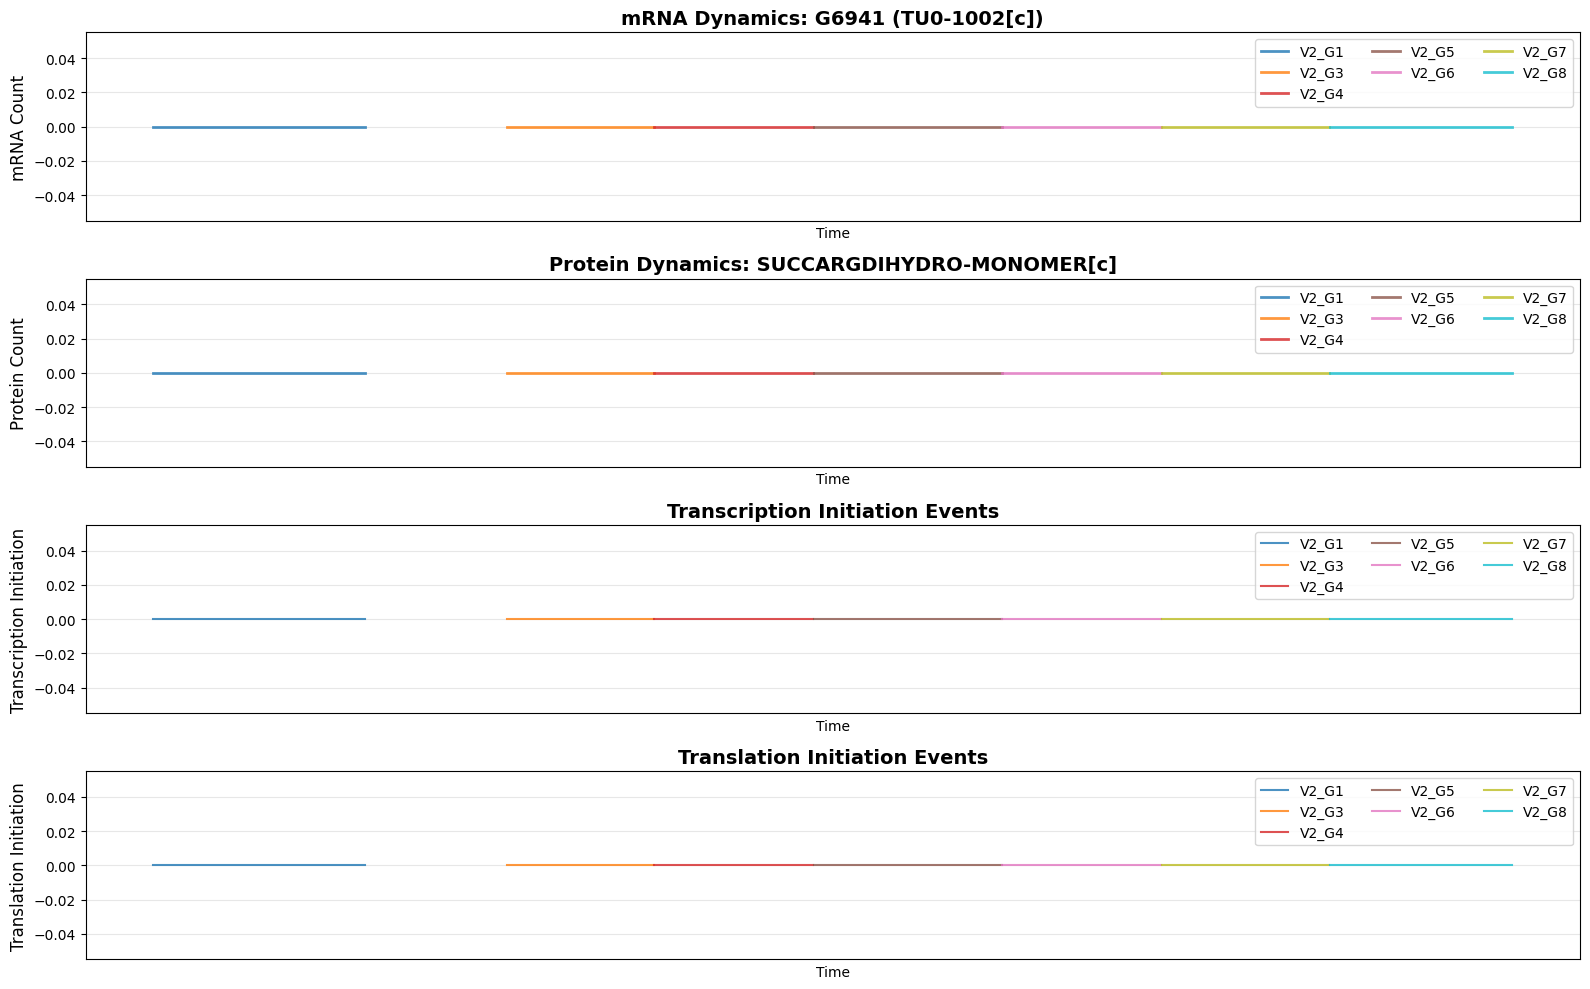


SUMMARY STATISTICS

V2_G1:
  Duration: 4060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G3:
  Duration: 2820.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G4:
  Duration: 3060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G5:
  Duration: 3600.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G6:
  Duration: 3060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G7:
  Duration: 3220.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G8:
  Duration: 3500.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited
gene_expression_trace.py check | Gene=G6943 | lineage_seed=100
left project variant=3, generations=[1, 3, 4, 5, 6, 7, 8]
Tracking: Gene=G6943 | TU=TU0-100

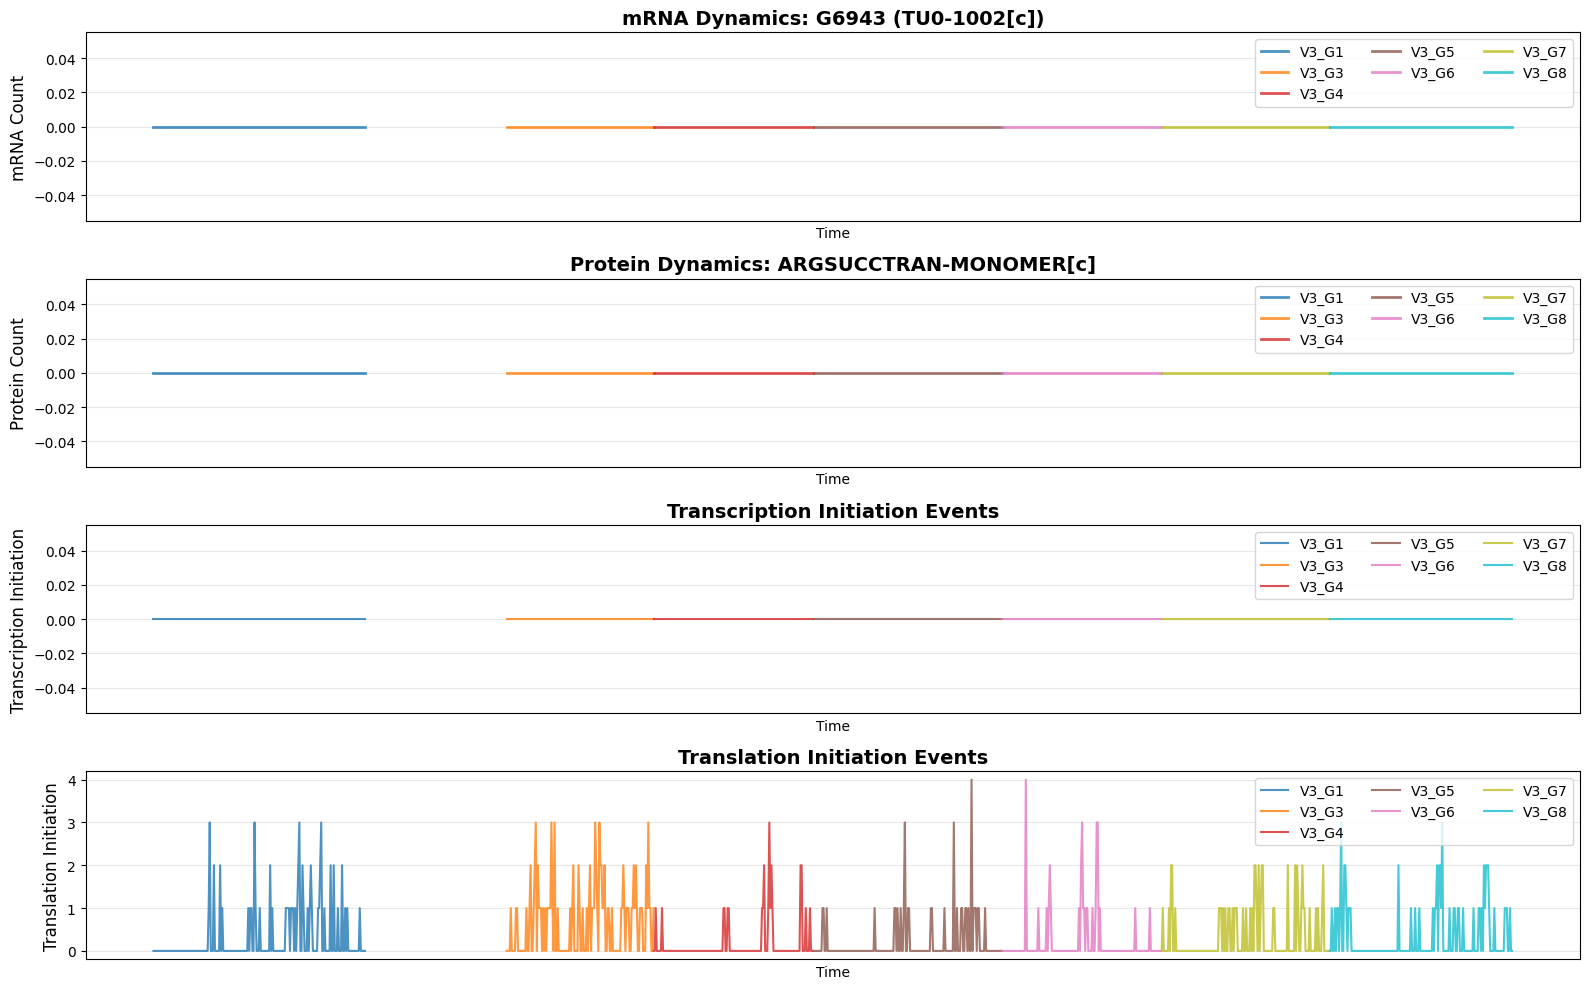


SUMMARY STATISTICS

V3_G1:
  Duration: 4060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V3_G3:
  Duration: 2820.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V3_G4:
  Duration: 3060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V3_G5:
  Duration: 3600.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V3_G6:
  Duration: 3060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V3_G7:
  Duration: 3220.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V3_G8:
  Duration: 3500.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited
right project variant=2, generations=[1, 3, 4, 5, 6, 7, 8]
Tracking: Gene=G6943 | TU=TU0-1002[c] | Monomer=ARGSUCCTRAN-MONOMER[c]

V2_G1: Loaded 204 timep

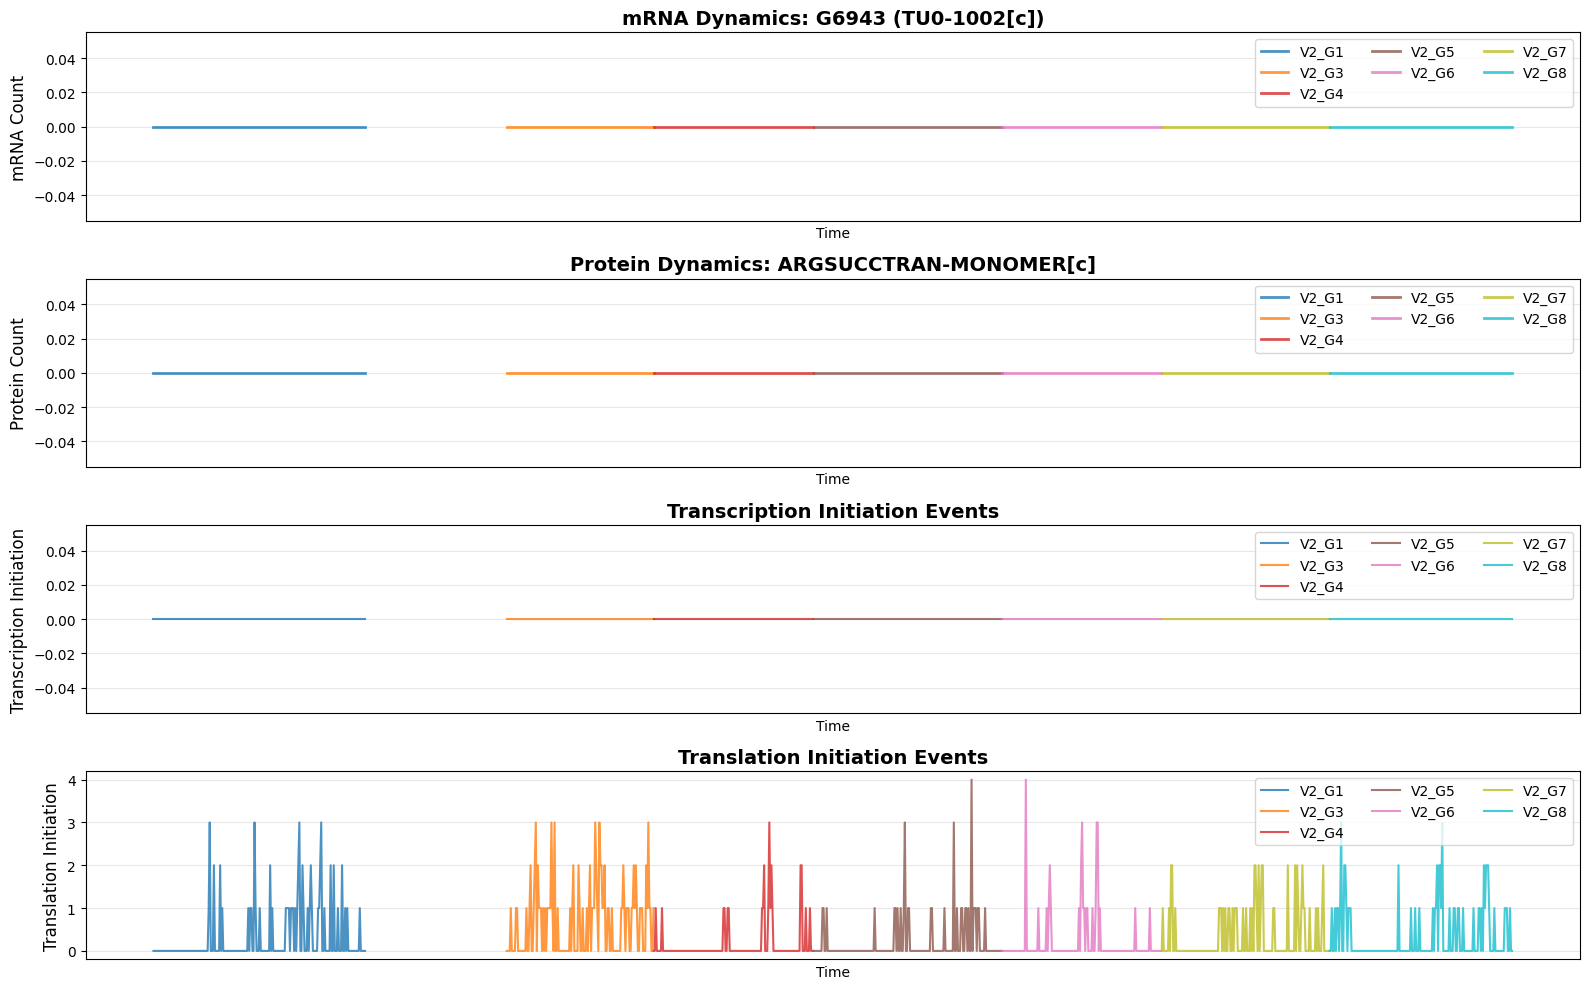


SUMMARY STATISTICS

V2_G1:
  Duration: 4060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G3:
  Duration: 2820.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G4:
  Duration: 3060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G5:
  Duration: 3600.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G6:
  Duration: 3060.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G7:
  Duration: 3220.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited

V2_G8:
  Duration: 3500.0s
  mRNA:    0 → 0
  Protein: 0 → 0
  Total transcription initiations: 0 → ✓ Gene Inhibited
Saved left project graph to: /user/home/il22158/work/vEcoli/surrogate/KO_validation/gene_knockout_leftover_variant=3_seed=100_gene=G6943.png
Saved right p

In [6]:
"""Task 2/3: use gene_expression_trace.py to inspect matched KO expression traces (no saving)."""
from importlib.util import spec_from_file_location, module_from_spec
from pathlib import Path

import matplotlib.pyplot as plt

TRACE_PY = BASE / "reading" / "gene_expression_trace.py"
if not TRACE_PY.exists():
    raise FileNotFoundError(f"Missing file: {TRACE_PY}")

if "comparison_plan_df" not in globals():
    raise RuntimeError("Run Cell 11 first to create comparison_plan_df.")

spec = spec_from_file_location("gene_expression_trace_module", str(TRACE_PY))
trace_module = module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(trace_module)


pending_save_path: Path | None = None
original_show = trace_module.plt.show


def save_before_show(*args, **kwargs):
    global pending_save_path
    if pending_save_path is not None:
        fig = trace_module.plt.gcf()
        fig.savefig(pending_save_path, dpi=300, bbox_inches="tight")
        print(f"Saved graph to: {pending_save_path}")
        pending_save_path = None
    return original_show(*args, **kwargs)


trace_module.plt.show = save_before_show


valid_rows = comparison_plan_df[
    comparison_plan_df["generation"].notna()
    & comparison_plan_df["note"].astype(str).str.startswith("Compared")
].copy()
if valid_rows.empty:
    print("No overlapping generations from Cell 11; skipping gene_expression_trace.py execution.")
else:
    for gene_id, sub_df in valid_rows.groupby("gene_id", sort=False):
        left_variant = int(sub_df["left_variant"].iloc[0])
        right_variant = int(sub_df["right_variant"].iloc[0])
        lineage_seed = int(sub_df["lineage_seed"].iloc[0])
        generations = sorted(sub_df["generation"].astype(int).unique().tolist())

        print("=" * 100)
        print(f"gene_expression_trace.py check | Gene={gene_id} | lineage_seed={lineage_seed}")
        print(f"left project variant={left_variant}, generations={generations}")
        pending_save_path = KO_VALIDATION_DIR / f"{PROJECTS['gene_knockout_leftover'].name}_variant={left_variant}_seed={lineage_seed}_gene={gene_id}.png"
        trace_module.track_knockout_dynamics(
            gene_id=gene_id,
            project_folder=PROJECTS["gene_knockout_leftover"].name,
            variants=[left_variant],
            generations=generations,
            lineage_seed=lineage_seed,
            plot=True,
            save=False,
            downsample_sec=1,
        )
        left_fig_path = KO_VALIDATION_DIR / f"{PROJECTS['gene_knockout_leftover'].name}_variant={left_variant}_seed={lineage_seed}_gene={gene_id}.png"

        print(f"right project variant={right_variant}, generations={generations}")
        pending_save_path = KO_VALIDATION_DIR / f"{PROJECTS['gene_knockout_TU_ID_test'].name}_variant={right_variant}_seed={lineage_seed}_gene={gene_id}.png"
        trace_module.track_knockout_dynamics(
            gene_id=gene_id,
            project_folder=PROJECTS["gene_knockout_TU_ID_test"].name,
            variants=[right_variant],
            generations=generations,
            lineage_seed=lineage_seed,
            plot=True,
            save=False,
            downsample_sec=1,
        )
        right_fig_path = KO_VALIDATION_DIR / f"{PROJECTS['gene_knockout_TU_ID_test'].name}_variant={right_variant}_seed={lineage_seed}_gene={gene_id}.png"

trace_module.plt.show = original_show
print(f"Saved left project graph to: {left_fig_path}")
print(f"Saved right project graph to: {right_fig_path}")


In [ ]:
"""Task 3/3: plot total mass, growth rate, RNA mass, protein mass, and ppGpp for compared KO traces."""
import matplotlib.pyplot as plt

if "comparison_plan_df" not in globals() or "trace_cache" not in globals():
    raise RuntimeError("Run Cell 12 first to create comparison_plan_df and trace_cache.")

valid_rows = comparison_plan_df[
    comparison_plan_df["generation"].notna()
    & comparison_plan_df["note"].astype(str).str.startswith("Compared")
].copy()
if valid_rows.empty:
    print("No overlapping generations to plot.")
else:
    metric_order = ["total_mass", "growth_rate", "rna_mass", "protein_mass", "ppgpp"]
    metric_titles = {
        "total_mass": "Total mass",
        "growth_rate": "Growth rate",
        "rna_mass": "RNA mass",
        "protein_mass": "Protein mass",
        "ppgpp": "ppGpp level",
    }

    for _, row in valid_rows.iterrows():
        gene_id = str(row["gene_id"])
        generation = int(row["generation"])
        key = (gene_id, generation)
        if key not in trace_cache:
            continue

        left_trace = trace_cache[key]["left"]
        right_trace = trace_cache[key]["right"]

        fig, axes = plt.subplots(len(metric_order), 1, figsize=(12, 13), sharex=True)

        for ax, metric in zip(axes, metric_order):
            left_series = left_trace["metrics"][metric]
            right_series = right_trace["metrics"][metric]

            ax.plot(left_trace["time"], left_series, linewidth=2.0, label=left_trace["project_name"])
            ax.plot(right_trace["time"], right_series, linewidth=1.8, linestyle="--", label=right_trace["project_name"])
            ax.set_ylabel(metric_titles[metric])
            ax.grid(True, alpha=0.25)
            ax.legend(loc="best")

        axes[0].set_title(f"{gene_id} | generation {generation} | system-level trajectory comparison")
        axes[-1].set_xlabel("Time (s)")
        fig.tight_layout()
        plot_path = KO_VALIDATION_DIR / f"{gene_id}_g{generation}.png"
        fig.savefig(plot_path, dpi=240, bbox_inches="tight")
        print(f"Saved plot to: {plot_path}")
        plt.show()

        metric_summary = pd.DataFrame(
            {
                "metric": metric_order,
                "left_mean": [float(np.nanmean(left_trace["metrics"][m])) for m in metric_order],
                "right_mean": [float(np.nanmean(right_trace["metrics"][m])) for m in metric_order],
                "mean_abs_diff": [float(np.nanmean(np.abs(left_trace["metrics"][m] - right_trace["metrics"][m]))) for m in metric_order],
            }
        )
        print(f"Summary means for {gene_id}, generation {generation}")
        display(metric_summary)

Breakdown for above code:

Uses both projects:
    - gene_knockout_leftover
    - gene_knockout_TU_ID_test

Checks target genes: EG10016, G6941, G6943.
    - Resolves matching variants by metadata:
    - Leftover project matched by gene ID knockout.
    - TU/RNA project matched by TU/RNA IDs derived from simulation data for each gene.

Extracts time-series for each shared generation (lineage_seed=0):
    - RNA counts for the corresponding TU/RNA target.
    - Protein counts for the corresponding monomer product.

Verifies exact equality between the two projects per generation:
    - Exact time vector match.
    - Exact RNA time-series match.
    - Exact protein time-series match.
    - Also reports max absolute differences for RNA/protein.

Plots results directly in notebook only (no saving):
    - Gene product comparison plot (RNA + protein).

Separate metrics panel with:
    - total mass
    - growth rate
    - RNA mass
    - protein mass
    - ppGpp level

Prints and displays a final summary table and a final all-exact boolean conclusion.

# Data preparation - cutomised KO data

In [21]:
from pathlib import Path

import numpy as np
import pandas as pd

BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_FILES = [
    SURROGATE_DIR / "results/surrogate_preprocessed_seed_default_generation_long.csv",
    SURROGATE_DIR / "results/surrogate_preprocessed_ko441_generation_long.csv",
]
EARLY_STOP_CSV = SURROGATE_DIR / "results/ko_runs_with_success_generation.csv"
ADJACENT_RISE_SCALE = 2.0
GENES_TSV = BASE / "reconstruction/ecoli/flat/genes.tsv"
RNAS_TSV = BASE / "reconstruction/ecoli/flat/rnas.tsv"
OPERON_TSV = BASE / "reading/results/knockout_experiment/operon_classification.tsv"


def parse_ko_gene_id(label: object) -> object:
    if pd.isna(label):
        return pd.NA
    text = str(label).strip()
    if text.startswith("KO:"):
        return text.split("KO:", 1)[1].split(",", 1)[0].strip()
    return pd.NA


def load_source(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["source_file"] = path.name
    df["label"] = df["label"].astype("string")
    df["gene_id"] = df.get("gene_id", pd.Series(index=df.index, dtype="string")).astype("string")
    missing_gene = df["gene_id"].isna() | (df["gene_id"].str.strip() == "")
    df.loc[missing_gene, "gene_id"] = df.loc[missing_gene, "label"].map(parse_ko_gene_id)
    df["run_type"] = np.where(df["label"].eq("baseline"), "baseline", "KO")
    df["generation_reconstructed"] = pd.to_numeric(df["generation_reconstructed"], errors="coerce").astype("Int64")
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["lineage_seed"] = pd.to_numeric(df["lineage_seed"], errors="coerce").astype("Int64")
    df["growth_rate_h"] = pd.to_numeric(df["growth_mean"], errors="coerce") * 3600.0
    df["dry_mass_g"] = pd.to_numeric(df["dry_mass_end"], errors="coerce")
    return df


def load_early_stop_table(path: Path) -> pd.DataFrame:
    stop_df = pd.read_csv(path)
    stop_df["variant"] = pd.to_numeric(stop_df["variant"], errors="coerce").astype("Int64")
    stop_df["lineage_seed"] = pd.to_numeric(stop_df["lineage_seed"], errors="coerce").astype("Int64")
    stop_df["gene_id"] = stop_df["gene_id"].astype("string")
    stop_df["max_success_generation"] = pd.to_numeric(stop_df["max_success_generation"], errors="coerce").astype("Int64")
    return stop_df


def get_failure_cutoff(run_df: pd.DataFrame, stop_df: pd.DataFrame) -> int | None:
    if run_df.empty or "gene_id" not in run_df.columns:
        return None
    if run_df["run_type"].astype(str).iloc[0] != "KO":
        return None

    key_frame = run_df[["project", "variant", "lineage_seed", "gene_id"]].drop_duplicates()
    if len(key_frame) != 1:
        return None

    key = key_frame.iloc[0]
    hit = stop_df[
        (stop_df["project"].astype(str) == str(key["project"]))
        & (stop_df["variant"].astype("Int64") == int(key["variant"]))
        & (stop_df["lineage_seed"].astype("Int64") == int(key["lineage_seed"]))
        & (stop_df["gene_id"].astype(str) == str(key["gene_id"]))
    ]
    if hit.empty:
        return None

    cutoff = hit.iloc[0]["max_success_generation"]
    if pd.isna(cutoff):
        return None
    cutoff = int(cutoff)
    if cutoff >= 8:
        return None
    return cutoff


def get_abnormal_rise_mask(run_df: pd.DataFrame, stop_df: pd.DataFrame) -> pd.Series:
    if run_df.empty:
        return pd.Series(False, index=run_df.index)
    if run_df["run_type"].astype(str).iloc[0] != "KO":
        return pd.Series(False, index=run_df.index)

    failed_before_8 = get_failure_cutoff(run_df, stop_df) is not None
    if not failed_before_8:
        return pd.Series(False, index=run_df.index)

    next_growth = pd.to_numeric(run_df["growth_rate_h"].shift(-1), errors="coerce")
    current_growth = pd.to_numeric(run_df["growth_rate_h"], errors="coerce")
    abnormal = (
        next_growth.notna()
        & current_growth.notna()
        & (next_growth > current_growth * ADJACENT_RISE_SCALE)
    )
    return abnormal.fillna(False)


def build_one_step_rows(run_df: pd.DataFrame, stop_df: pd.DataFrame) -> pd.DataFrame:
    run_df = run_df.sort_values("generation_reconstructed").reset_index(drop=True)
    run_df["growth_next_h"] = run_df["growth_rate_h"].shift(-1)
    run_df["next_generation"] = run_df["generation_reconstructed"].shift(-1)

    cutoff_generation = get_failure_cutoff(run_df, stop_df)
    if cutoff_generation is None:
        keep = run_df.index < (len(run_df) - 1)
        censored = False
    else:
        keep = run_df["generation_reconstructed"] < cutoff_generation
        censored = True

    abnormal_mask = get_abnormal_rise_mask(run_df, stop_df)

    out = run_df.loc[keep].copy()
    out = out.dropna(subset=["growth_next_h"])
    if out.empty:
        return out

    out["peak_generation"] = cutoff_generation if cutoff_generation is not None else pd.NA
    out["peak_censored"] = censored
    out["is_pre_peak"] = True
    out["current_generation"] = out["generation_reconstructed"]
    out["target_generation"] = out["next_generation"]
    out["current_growth_h"] = out["growth_rate_h"]
    abnormal_in_out = abnormal_mask.reindex(out.index).fillna(False).astype(bool)
    out.loc[abnormal_in_out, "current_growth_h"] = 0.0
    out["current_dry_mass_g"] = out["dry_mass_g"]
    out["gen_step"] = out["target_generation"] - out["current_generation"]
    out["sample_id"] = (
        out["project"].astype(str)
        + "|v"
        + out["variant"].astype(str)
        + "|s"
        + out["lineage_seed"].astype(str)
        + "|"
        + out["label"].astype(str)
        + "|g"
        + out["current_generation"].astype(str)
    )
    return out


source_df = pd.concat([load_source(path) for path in SOURCE_FILES], ignore_index=True)
source_df = source_df.dropna(
    subset=["project", "variant", "lineage_seed", "label", "generation_reconstructed", "growth_rate_h"]
).copy()
early_stop_df = load_early_stop_table(EARLY_STOP_CSV)

baseline_check_df = source_df[source_df["run_type"].astype(str).eq("baseline")].copy()
baseline_check_df["next_generation"] = pd.to_numeric(
    baseline_check_df["generation_reconstructed"].shift(-1), errors="coerce"
)
baseline_check_df["current_growth_h"] = pd.to_numeric(
    baseline_check_df["growth_rate_h"], errors="coerce"
)
baseline_check_df["next_growth_h"] = pd.to_numeric(
    baseline_check_df["growth_rate_h"].shift(-1), errors="coerce"
)
baseline_abnormal_mask = (
    baseline_check_df["next_growth_h"].notna()
    & baseline_check_df["current_growth_h"].notna()
    & (baseline_check_df["next_growth_h"] > baseline_check_df["current_growth_h"] * ADJACENT_RISE_SCALE)
)
print(f"Baseline rows loaded: {len(baseline_check_df)}")
print(f"Baseline rows satisfying next > {ADJACENT_RISE_SCALE:g} * current: {int(baseline_abnormal_mask.sum())}")
if bool(baseline_abnormal_mask.any()):
    print(baseline_check_df.loc[baseline_abnormal_mask, ["generation_reconstructed", "current_growth_h", "next_growth_h"]].head(10).to_string(index=False))

run_keys = [
    "source_file",
    "project",
    "variant",
    "lineage_seed",
    "label",
    "gene_id",
    "run_type",
]

baseline_trigger_rows = []
long_rows = []
for _, run_df in source_df.groupby(run_keys, dropna=False, sort=False):
    one_step = build_one_step_rows(run_df, early_stop_df)
    if not one_step.empty:
        long_rows.append(one_step)

if not long_rows:
    raise RuntimeError("No training rows were generated from the surrogate inputs.")

if baseline_trigger_rows:
    baseline_trigger_df = pd.concat(baseline_trigger_rows, ignore_index=True)
    print(f"Baseline rows triggering adjacent-rise cutoff: {len(baseline_trigger_df)}")
    print(baseline_trigger_df.head(10).to_string(index=False))
else:
    print("Baseline rows triggering adjacent-rise cutoff: 0")

training_long = pd.concat(long_rows, ignore_index=True)
training_long["ko_gene_id"] = training_long["gene_id"].where(training_long["run_type"].eq("KO"))

genes = pd.read_csv(GENES_TSV, sep="\t", comment="#")
rnas = pd.read_csv(RNAS_TSV, sep="\t", comment="#")
operons = pd.read_csv(OPERON_TSV, sep="\t", comment="#")

gene_catalog = (
    genes.rename(columns={"id": "gene_id", "symbol": "gene_symbol"})
    .merge(
        rnas[["gene_id", "type", "monomer_ids"]].rename(columns={"type": "rna_type"}),
        on="gene_id",
        how="left",
    )
    .merge(
        operons[["id", "is_single_gene_operon", "operon_size", "tu_id", "other_genes_in_operon"]].rename(
            columns={"id": "gene_id"}
        ),
        on="gene_id",
        how="left",
    )
)

gene_pool = sorted(training_long["ko_gene_id"].dropna().astype(str).unique().tolist())
gene_catalog = gene_catalog[gene_catalog["gene_id"].astype(str).isin(gene_pool)].copy()
gene_catalog["operon_partner_count"] = (
    gene_catalog["other_genes_in_operon"].fillna("").astype(str).str.split(",").map(lambda items: 0 if items == [""] else len(items))
)

genotype_knockout = pd.get_dummies(training_long["ko_gene_id"], dtype=np.int8)
genotype_knockout = genotype_knockout.reindex(columns=gene_pool, fill_value=0)
genotype_knockout.columns = [f"gene_available__{gene_id}" for gene_id in genotype_knockout.columns]
genotype_available = (1 - genotype_knockout).astype(np.int8)

sample_cols = [
    "sample_id",
    "source_file",
    "project",
    "variant",
    "lineage_seed",
    "label",
    "run_type",
    "gene_id",
    "ko_gene_id",
    "current_generation",
    "target_generation",
    "gen_step",
    "current_growth_h",
    "growth_next_h",
    "current_dry_mass_g",
    "peak_generation",
    "peak_censored",
    "is_pre_peak",
]

training_data = pd.concat(
    [
        training_long[sample_cols].reset_index(drop=True),
        genotype_available.reset_index(drop=True),
    ],
    axis=1,
)
training_data = training_data.merge(
    gene_catalog.add_prefix("ko_"),
    left_on="ko_gene_id",
    right_on="ko_gene_id",
    how="left",
)

train_parquet = TRAIN_DIR / "surrogate_training_dataset.parquet"
train_csv = TRAIN_DIR / "surrogate_training_dataset.csv"
gene_catalog_csv = TRAIN_DIR / "surrogate_gene_catalog.csv"
feature_list_csv = TRAIN_DIR / "surrogate_genotype_feature_list.csv"

training_data.to_parquet(train_parquet, index=False)
training_data.to_csv(train_csv, index=False)
gene_catalog.to_csv(gene_catalog_csv, index=False)
pd.DataFrame({"feature_name": genotype_available.columns}).to_csv(feature_list_csv, index=False)

print(f"Saved training rows: {len(training_data)}")
print(f"KO gene pool size: {len(gene_pool)}")
print(f"Peak-censored rows: {int(training_data['peak_censored'].sum())}")
print(f"Training data: {train_parquet}")
print(f"Training data: {train_csv}")
print(f"Gene catalog: {gene_catalog_csv}")
print(f"Feature list: {feature_list_csv}")

Baseline rows loaded: 16
Baseline rows satisfying next > 2 * current: 0
Baseline rows triggering adjacent-rise cutoff: 0
Saved training rows: 6001
KO gene pool size: 462
Peak-censored rows: 928
Training data: /user/home/il22158/work/vEcoli/surrogate/train_data/surrogate_training_dataset.parquet
Training data: /user/home/il22158/work/vEcoli/surrogate/train_data/surrogate_training_dataset.csv
Gene catalog: /user/home/il22158/work/vEcoli/surrogate/train_data/surrogate_gene_catalog.csv
Feature list: /user/home/il22158/work/vEcoli/surrogate/train_data/surrogate_genotype_feature_list.csv


### Implemented dataset details

- The training set does **not** use all 4000+ genes from `genes.tsv` as model features. It uses the **observed KO gene pool only**, which is 462 genes in this implementation.
- The full genome annotation files are used only to enrich the KO genes with metadata from `genes.tsv`, `rnas.tsv`, and `operon_classification.tsv`.
- Each sample is a one-step transition row: current generation features are paired with the next-generation growth target.
- Growth rate is converted with `growth_rate_h = growth_mean * 3600.0` to get an easy-to-read unit of `1/h`.
- Peak handling now uses two rules:
  - If the summary file says `max_success_generation = n` and `n < 8`, this is still used as a failure cutoff.
  - If the next generation grows too fast (`growth_next_h > 2 * current_growth_h`) in failed-before-8 KO lineages, the row is marked abnormal and the **current-generation growth feature is set to 0.0**.
- Important: abnormal rows are **not excluded** from training; they are **kept with current growth set to zero**.
- This keeps the sequence while reducing the influence of unstable pre-death spikes in model inputs.

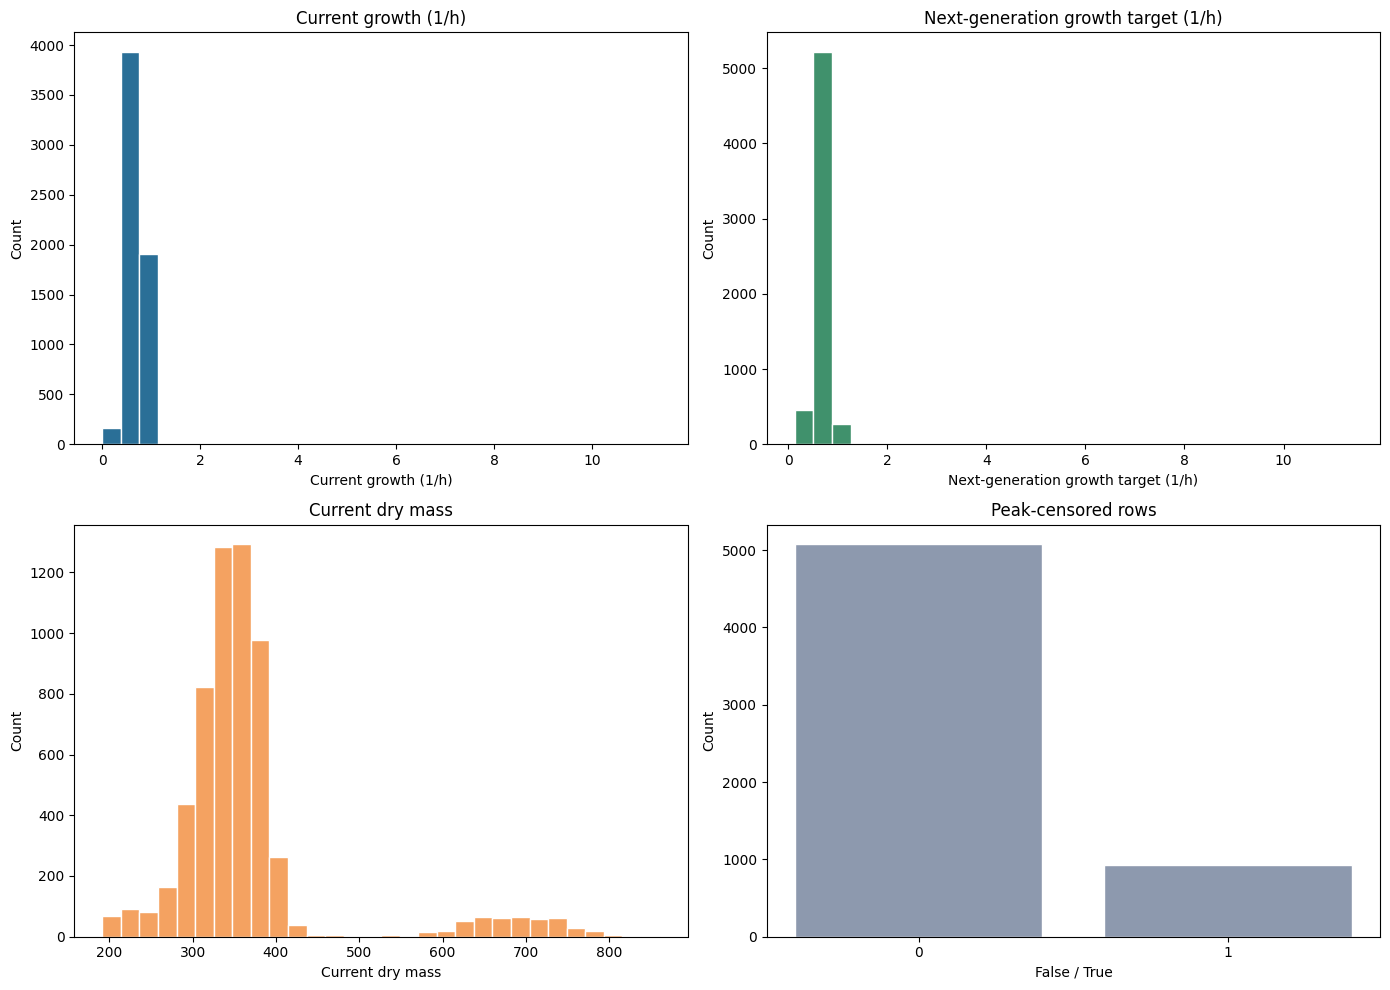

Saved overview figure: /user/home/il22158/work/vEcoli/surrogate/train_data/training_space_overview.png
       current_growth_h  growth_next_h  current_dry_mass_g
count       6001.000000    6001.000000         6001.000000
mean           0.709053       0.717868          366.850365
std            0.186687       0.235021          101.610352
min            0.000000       0.133264          191.567133
25%            0.665535       0.659277          321.949726
50%            0.722353       0.725532          348.425846
75%            0.773314       0.784583          374.216168
max           11.384274      11.384274          860.546512


In [63]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

metrics = [
    ("current_growth_h", "Current growth (1/h)", "#2a6f97"),
    ("growth_next_h", "Next-generation growth target (1/h)", "#40916c"),
    ("current_dry_mass_g", "Current dry mass", "#f4a261"),
    ("peak_censored", "Peak-censored rows", "#8d99ae"),
]

for ax, (col, title, color) in zip(axes, metrics):
    if col == "peak_censored":
        values = training_data[col].astype(int).value_counts().sort_index()
        ax.bar(values.index.astype(str), values.values, color=color, edgecolor="white")
        ax.set_xlabel("False / True")
        ax.set_ylabel("Count")
    else:
        ax.hist(training_data[col].dropna(), bins=30, color=color, edgecolor="white")
        ax.set_xlabel(title)
        ax.set_ylabel("Count")
    ax.set_title(title)

fig.tight_layout()
fig_path = TRAIN_DIR / "training_space_overview.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved overview figure: {fig_path}")
print(training_data[["current_growth_h", "growth_next_h", "current_dry_mass_g"]].describe().to_string())

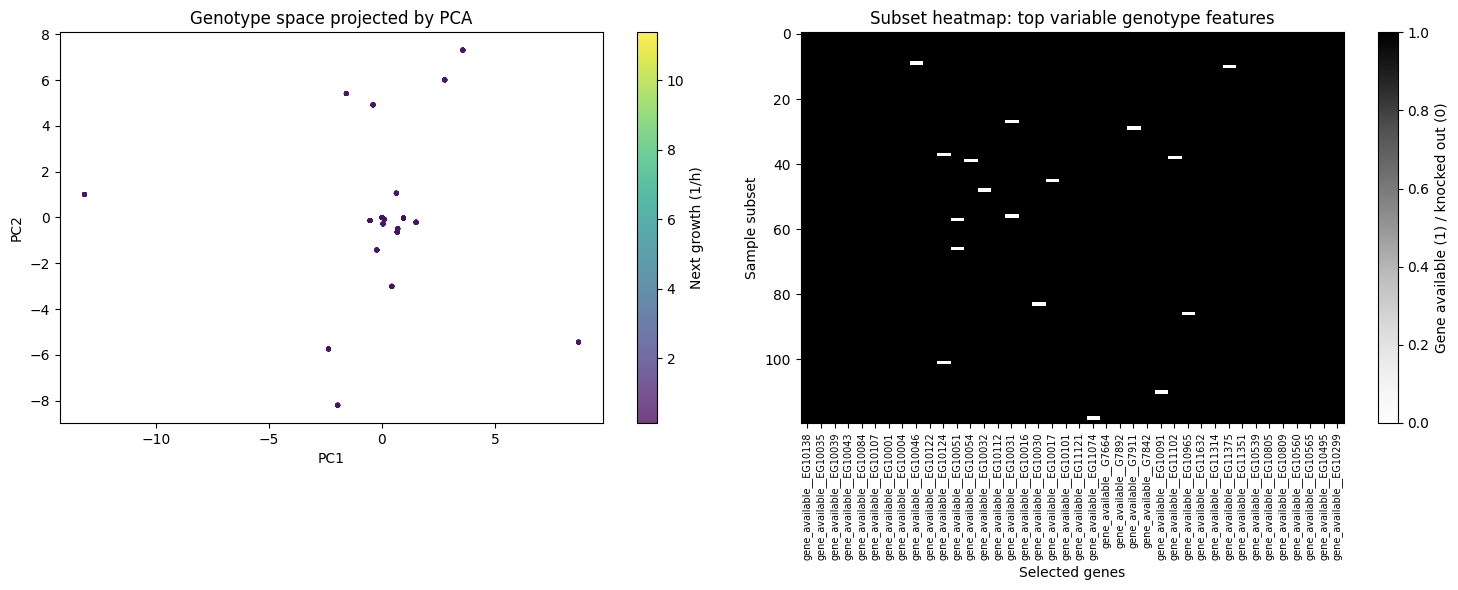

PCA explained variance ratio: [0.0022, 0.0022]
Selected heatmap genes: 40
Heatmap sample rows: 120


In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Genotype-only visualization.
# Scatter is better for the full sample space; heatmap is only useful for a small gene subset.

X = genotype_available.astype(float)

# 2D projection of genotype space
X_scaled = StandardScaler(with_mean=True, with_std=True).fit_transform(X)
pca = PCA(n_components=2, random_state=0)
xy = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame(
    {
        "pc1": xy[:, 0],
        "pc2": xy[:, 1],
        "run_type": training_data["run_type"].to_numpy(),
        "peak_censored": training_data["peak_censored"].to_numpy(),
        "growth_next_h": training_data["growth_next_h"].to_numpy(),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc = axes[0].scatter(
    plot_df["pc1"],
    plot_df["pc2"],
    c=plot_df["growth_next_h"],
    cmap="viridis",
    s=12,
    alpha=0.75,
    linewidths=0,
)
axes[0].set_title("Genotype space projected by PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[0], label="Next growth (1/h)")

# Small heatmap for a manageable subset of genes with the highest variability.
# This avoids an unreadable 2649 x 410 full heatmap.
gene_variability = X.var(axis=0).sort_values(ascending=False)
selected_genes = gene_variability.head(40).index
heatmap_df = X[selected_genes].sample(n=min(120, len(X)), random_state=0)

im = axes[1].imshow(
    heatmap_df.to_numpy(),
    aspect="auto",
    interpolation="nearest",
    cmap="Greys",
)
axes[1].set_title("Subset heatmap: top variable genotype features")
axes[1].set_xlabel("Selected genes")
axes[1].set_ylabel("Sample subset")
axes[1].set_xticks(np.arange(len(selected_genes)))
axes[1].set_xticklabels(selected_genes, rotation=90, fontsize=7)
plt.colorbar(im, ax=axes[1], label="Gene available (1) / knocked out (0)")

fig.tight_layout()
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.round(4).tolist()}")
print(f"Selected heatmap genes: {len(selected_genes)}")
print(f"Heatmap sample rows: {len(heatmap_df)}")

# Baseline Linear Model - customised KO data

In [64]:
# Linear Regression using only genotype (available genes) as input and growth-rate as target
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Determine X (genotype availability)
if 'genotype_available' in globals():
    X_df = genotype_available.copy().reset_index(drop=True)
elif 'training_data' in globals():
    gene_cols = [c for c in training_data.columns if c.startswith('gene_available__')]
    if not gene_cols:
        raise RuntimeError('No genotype columns found in `training_data` (looking for `gene_available__*`)')
    X_df = training_data[gene_cols].astype(np.int8).reset_index(drop=True)
else:
    raise RuntimeError('`genotype_available` or `training_data` not found in kernel')

# Determine y (growth rate next hour)
if 'training_data' in globals() and 'growth_next_h' in training_data.columns:
    y_ser = pd.Series(training_data['growth_next_h']).astype(float).reset_index(drop=True)
elif 'baseline_next_growth' in globals():
    y_ser = pd.Series(baseline_next_growth).astype(float).reset_index(drop=True)
elif 'baseline_ref' in globals():
    y_ser = pd.Series(baseline_ref).astype(float).reset_index(drop=True)
else:
    raise RuntimeError('Could not locate growth-rate target (`training_data["growth_next_h"]`, `baseline_next_growth`, or `baseline_ref`)')

# Quick inspections
print(f"Using {X_df.shape[1]} genotype features; X shape: {X_df.shape}")
print("Feature sample:")
try:
    display(X_df.head())
except Exception:
    print(X_df.head().to_string())

print('\nTarget sample stats:')
print(y_ser.describe())

# Align lengths
if len(X_df) != len(y_ser):
    raise RuntimeError(f"Length mismatch: X has {len(X_df)} rows but y has {len(y_ser)} rows")

X = X_df.values
y = y_ser.values.squeeze()

print(f"Converted X shape: {X.shape}    y shape: {y.shape}")

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit linear model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.6f}    RMSE: {rmse:.6f}    R2: {r2:.4f}')

# Show top coefficients
coef = pd.Series(model.coef_, index=X_df.columns)
print('\nTop 10 genotype coefficients by absolute value:')
print(coef.abs().sort_values(ascending=False).head(10))

Using 462 genotype features; X shape: (6001, 462)
Feature sample:


,gene_available__EG10001,gene_available__EG10004,gene_available__EG10006,gene_available__EG10007,gene_available__EG10012,gene_available__EG10016,gene_available__EG10017,gene_available__EG10022,gene_available__EG10023,gene_available__EG10024,...,gene_available__G7860,gene_available__G7865,gene_available__G7868,gene_available__G7888,gene_available__G7889,gene_available__G7892,gene_available__G7893,gene_available__G7911,gene_available__G7948,gene_available__M004
0,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
4,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1



Target sample stats:
count    6001.000000
mean        0.717868
std         0.235021
min         0.133264
25%         0.659277
50%         0.725532
75%         0.784583
max        11.384274
Name: growth_next_h, dtype: float64
Converted X shape: (6001, 462)    y shape: (6001,)
MSE: 0.038504    RMSE: 0.196224    R2: 0.0757

Top 10 genotype coefficients by absolute value:
gene_available__EG10794    1.017050
gene_available__EG10920    0.677169
gene_available__EG10911    0.603877
gene_available__EG10900    0.550570
gene_available__EG11226    0.518890
gene_available__EG10919    0.504349
gene_available__EG11575    0.493552
gene_available__EG10383    0.487680
gene_available__EG11576    0.485480
gene_available__EG11577    0.481185
dtype: float64


In [65]:
# With CV 5-folds
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import joblib

# 1) Select genotype features
if 'genotype_available' in globals():
    X_df = genotype_available.copy().reset_index(drop=True)
elif 'training_data' in globals():
    gene_cols = [c for c in training_data.columns if c.startswith('gene_available__')]
    if not gene_cols:
        raise RuntimeError('No genotype columns found in `training_data` (expect `gene_available__*`)')
    X_df = training_data[gene_cols].astype(np.int8).reset_index(drop=True)
else:
    raise RuntimeError('`genotype_available` or `training_data` not found in kernel')

# 2) Select growth-rate target
if 'training_data' in globals() and 'growth_next_h' in training_data.columns:
    y_ser = pd.Series(training_data['growth_next_h']).astype(float).reset_index(drop=True)
elif 'baseline_next_growth' in globals():
    y_ser = pd.Series(baseline_next_growth).astype(float).reset_index(drop=True)
elif 'baseline_ref' in globals():
    y_ser = pd.Series(baseline_ref).astype(float).reset_index(drop=True)
else:
    raise RuntimeError('Could not locate growth-rate target (`growth_next_h`, `baseline_next_growth` or `baseline_ref`)')

# 3) Align lengths; if mismatch try to align using training_data index
if len(X_df) != len(y_ser):
    if 'training_data' in globals() and set(X_df.index).issubset(set(training_data.index)) and 'growth_next_h' in training_data.columns:
        y_ser = pd.Series(training_data.loc[X_df.index, 'growth_next_h']).astype(float).reset_index(drop=True)
    else:
        raise RuntimeError(f'Length mismatch: X has {len(X_df)} rows but y has {len(y_ser)} rows')

# 4) Combine and clean
df = X_df.copy()
df['__target__'] = y_ser
before = len(df)
# drop rows with missing target or any missing feature
df = df.dropna(subset=['__target__']).dropna(axis=0, how='any')
after = len(df)
print(f'Rows before cleaning: {before}; after dropna: {after}')

# 5) Final X, y
X = df.drop(columns=['__target__']).astype(np.int8)
y = df['__target__'].astype(float).values
print(f'Using {X.shape[1]} genotype features; X shape: {X.shape}; y shape: {y.shape}')
print('Target summary:')
print(pd.Series(y).describe())

# 6) Split, fit
X_arr = X.values
X_train, X_test, y_train, y_test = train_test_split(X_arr, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

# 7) Evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.6f}    RMSE: {rmse:.6f}    R2: {r2:.4f}')

# 8) Cross-validated RMSE (5-fold)
cv_scores = cross_val_score(model, X_arr, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)
print(f'5-fold CV RMSE: mean={cv_rmse.mean():.6f}, std={cv_rmse.std():.6f}')

# 9) Top genotype coefficients
coef = pd.Series(model.coef_, index=X.columns)
print('\nTop 10 genotype coefficients (by abs value):')
print(coef.abs().sort_values(ascending=False).head(10))

# 10) Save model (best-effort)
try:
    out_path = SURROGATE_DIR / 'baseline_linear_genotype.pkl'
    joblib.dump(model, out_path)
    print(f'Baseline model saved to: {out_path}')
except Exception:
    pass

Rows before cleaning: 6001; after dropna: 6001
Using 462 genotype features; X shape: (6001, 462); y shape: (6001,)
Target summary:
count    6001.000000
mean        0.717868
std         0.235021
min         0.133264
25%         0.659277
50%         0.725532
75%         0.784583
max        11.384274
dtype: float64
MSE: 0.038504    RMSE: 0.196224    R2: 0.0757
5-fold CV RMSE: mean=0.218751, std=0.066500

Top 10 genotype coefficients (by abs value):
gene_available__EG10794    1.017050
gene_available__EG10920    0.677169
gene_available__EG10911    0.603877
gene_available__EG10900    0.550570
gene_available__EG11226    0.518890
gene_available__EG10919    0.504349
gene_available__EG11575    0.493552
gene_available__EG10383    0.487680
gene_available__EG11576    0.485480
gene_available__EG11577    0.481185
dtype: float64
Baseline model saved to: /user/home/il22158/work/vEcoli/surrogate/baseline_linear_genotype.pkl


In [66]:
# Ridge and ElasticNet regularized linear models (genotype-only -> growth rate)
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import joblib

# --- Prepare X (genotype) and y (growth rate) similarly to baseline cell ---
if 'genotype_available' in globals():
    X_df = genotype_available.copy().reset_index(drop=True)
elif 'training_data' in globals():
    gene_cols = [c for c in training_data.columns if c.startswith('gene_available__')]
    if not gene_cols:
        raise RuntimeError('No genotype columns found in `training_data` (expect `gene_available__*`)')
    X_df = training_data[gene_cols].astype(np.int8).reset_index(drop=True)
else:
    raise RuntimeError('`genotype_available` or `training_data` not found in kernel')

if 'training_data' in globals() and 'growth_next_h' in training_data.columns:
    y_ser = pd.Series(training_data['growth_next_h']).astype(float).reset_index(drop=True)
elif 'baseline_next_growth' in globals():
    y_ser = pd.Series(baseline_next_growth).astype(float).reset_index(drop=True)
elif 'baseline_ref' in globals():
    y_ser = pd.Series(baseline_ref).astype(float).reset_index(drop=True)
else:
    raise RuntimeError('Could not locate growth-rate target (`growth_next_h`, `baseline_next_growth` or `baseline_ref`)')

if len(X_df) != len(y_ser):
    if 'training_data' in globals() and set(X_df.index).issubset(set(training_data.index)) and 'growth_next_h' in training_data.columns:
        y_ser = pd.Series(training_data.loc[X_df.index, 'growth_next_h']).astype(float).reset_index(drop=True)
    else:
        raise RuntimeError(f'Length mismatch: X has {len(X_df)} rows but y has {len(y_ser)} rows')

df = X_df.copy()
df['__target__'] = y_ser
df = df.dropna(subset=['__target__']).dropna(axis=0, how='any')  # drop missing rows
X = df.drop(columns=['__target__']).astype(np.int8)
y = df['__target__'].astype(float).values

print(f'Final X shape: {X.shape}, y shape: {y.shape}')
print(pd.Series(y).describe())

# --- Train/test split ---
X_arr = X.values
X_train, X_test, y_train, y_test = train_test_split(X_arr, y, test_size=0.2, random_state=42)

# --- Ridge with built-in CV over alpha ---
alphas = np.logspace(-4, 4, 25)
ridge_pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error'))
ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)
mse_r = mean_squared_error(y_test, y_pred_ridge)
rmse_r = np.sqrt(mse_r)
r2_r = r2_score(y_test, y_pred_ridge)
cv_ridge = np.sqrt(-cross_val_score(ridge_pipe, X_arr, y, cv=5, scoring='neg_mean_squared_error'))

print(f'Ridge -> MSE: {mse_r:.6f}, RMSE: {rmse_r:.6f}, R2: {r2_r:.4f}')
print(f'Ridge 5-fold CV RMSE: mean={cv_ridge.mean():.6f}, std={cv_ridge.std():.6f}')

# --- ElasticNet with CV (tunes alpha and l1_ratio) ---
enet_pipe = make_pipeline(
    StandardScaler(),
    ElasticNetCV(alphas=np.logspace(-4, 1, 30), l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5, max_iter=5000)
)
enet_pipe.fit(X_train, y_train)
y_pred_enet = enet_pipe.predict(X_test)
mse_e = mean_squared_error(y_test, y_pred_enet)
rmse_e = np.sqrt(mse_e)
r2_e = r2_score(y_test, y_pred_enet)
cv_enet = np.sqrt(-cross_val_score(enet_pipe, X_arr, y, cv=5, scoring='neg_mean_squared_error'))

print(f'ElasticNet -> MSE: {mse_e:.6f}, RMSE: {rmse_e:.6f}, R2: {r2_e:.4f}')
print(f'ElasticNet 5-fold CV RMSE: mean={cv_enet.mean():.6f}, std={cv_enet.std():.6f}')

# --- Helper to recover coefficients on original feature scale ---
def pipeline_coefs(pipe):
    scaler = pipe.named_steps['standardscaler']
    estimator = pipe.named_steps[list(pipe.named_steps.keys())[-1]]
    coef_scaled = estimator.coef_
    coef_original = coef_scaled / scaler.scale_
    return pd.Series(coef_original, index=X.columns)

# Report top coefficients
ridge_coefs = pipeline_coefs(ridge_pipe).abs().sort_values(ascending=False).head(10)
enet_coefs = pipeline_coefs(enet_pipe).abs().sort_values(ascending=False).head(10)

print('\nTop 10 Ridge genotype coefficients (abs):')
print(ridge_coefs)
print('\nTop 10 ElasticNet genotype coefficients (abs):')
print(enet_coefs)

# --- Save models (optional, best-effort) ---
try:
    joblib.dump(ridge_pipe, SURROGATE_DIR / 'ridge_genotype_model.pkl')
    joblib.dump(enet_pipe, SURROGATE_DIR / 'elasticnet_genotype_model.pkl')
    print('Saved ridge and elasticnet models under SURROGATE_DIR')
except Exception:
    pass

Final X shape: (6001, 462), y shape: (6001,)
count    6001.000000
mean        0.717868
std         0.235021
min         0.133264
25%         0.659277
50%         0.725532
75%         0.784583
max        11.384274
dtype: float64
Ridge -> MSE: 0.036175, RMSE: 0.190197, R2: 0.1316
Ridge 5-fold CV RMSE: mean=0.213431, std=0.069141
ElasticNet -> MSE: 0.037939, RMSE: 0.194778, R2: 0.0892
ElasticNet 5-fold CV RMSE: mean=0.213769, std=0.068725

Top 10 Ridge genotype coefficients (abs):
gene_available__EG10794    0.775670
gene_available__EG10920    0.540860
gene_available__EG10911    0.490121
gene_available__EG10900    0.453377
gene_available__EG10919    0.421435
gene_available__EG11226    0.285021
gene_available__EG10892    0.278142
gene_available__EG11575    0.267545
gene_available__EG10872    0.266990
gene_available__EG10383    0.263491
dtype: float64

Top 10 ElasticNet genotype coefficients (abs):
gene_available__EG10794    1.034514
gene_available__EG10920    0.695802
gene_available__EG1091